In [2]:
#!/usr/bin/env python3
# ============================================================
# Combined EOF Analysis for CMIP6 ocean variables in (lat,depth)
# at fixed longitudes, INCLUDING South + North Atlantic
#
# EOFs fit on TRAIN only; PCs are projected for FULL period.
# ============================================================

import os
import glob
import re
import numpy as np
import xarray as xr
from eofs.standard import Eof
import warnings
warnings.filterwarnings("ignore")

# Prevent HDF5 file locking issues on shared filesystems
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ============================================================
# CONFIG
# ============================================================
MODEL   = "EC-Earth3"      # EC-Earth3, IPSL-CM6A-LR, CESM2, MPI-ESM1-2-LR
VAR     = "so"             # thetao or so
NMODES  = 10

START_YEAR = 1850
END_YEAR   = 2014

TARGET_LONS   = [-10.0, -20.0, -30.0, -40.0, -60.0]
LON_WINDOW    = 10.0       # degrees
DEPTH_RANGE_M = (0.0, 5000.0)

# >>> NEW: Train fraction of the COMMON time axis (first X%)
TRAIN_FRACTION = 0.85  # choose 0.80–0.85 as you like

# ============================================================
# DIRECTORIES
# ============================================================
if MODEL == "EC-Earth3":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/EC-Earth3/{VAR}/"
elif MODEL == "IPSL-CM6A-LR":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/{VAR}/masked/"
elif MODEL == "CESM2":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/CESM2/{VAR}/masked/"
elif MODEL == "MPI-ESM1-2-LR":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/MPI-ESM1-2-LR/{VAR}/masked/"
else:
    raise ValueError("Unknown MODEL")

OUT_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_{int(TRAIN_FRACTION*100)}pct/"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# UTILITIES
# ============================================================

def parse_member_label(path):
    m = re.search(r"_(r\d+i\d+p\d+f\d+)", os.path.basename(path))
    return m.group(1) if m else os.path.basename(path)

def wrap_lon(lon):
    return ((lon + 180) % 360) - 180

def standardize_latlon(ds):
    lat_var = next(v for v in ["lat", "latitude", "nav_lat"] if v in ds)
    lon_var = next(v for v in ["lon", "longitude", "nav_lon"] if v in ds)

    lat = ds[lat_var]
    lon = ds[lon_var]

    if lat.ndim == 1 and lon.ndim == 1:
        lon2d, lat2d = np.meshgrid(lon.values, lat.values)
        ds = ds.drop_vars([lat_var, lon_var])
        ds = ds.rename_dims({lat.dims[0]: "y", lon.dims[0]: "x"})
        ds["lat2d"] = xr.DataArray(lat2d, dims=("y", "x"))
        ds["lon2d"] = xr.DataArray(lon2d, dims=("y", "x"))
        return ds

    ds = ds.swap_dims({lat.dims[0]: "y", lat.dims[1]: "x"})
    ds = ds.rename({lat_var: "lat2d", lon_var: "lon2d"})
    return ds

def get_depth_dim_and_coord(da, ds):
    if "olevel" in da.dims:
        return "olevel", ds["olevel"].values
    if "depth" in da.dims:
        return "depth", ds["depth"].values
    if "lev" in da.dims:
        z = ds["lev"].values
        if np.nanmax(z) > 10000:
            z = z / 100.0
        return "lev", z
    raise KeyError("No vertical coordinate found")

def compute_layer_thickness(z):
    z = np.asarray(z)
    dz = np.empty_like(z, dtype=float)
    dz[1:-1] = 0.5 * (z[2:] - z[:-2])
    dz[0]    = z[1] - z[0]
    dz[-1]   = z[-1] - z[-2]
    return np.abs(dz)

def extract_section_valid_ocean(da, ds, target_lon, depth_dim):
    lon2d = ds["lon2d"].values
    lat2d = ds["lat2d"].values

    lonW = wrap_lon(lon2d)
    tW   = wrap_lon(target_lon)

    valid_xy = np.isfinite(da).any(dim=("time", depth_dim)).values
    ny, nx = lonW.shape

    ix = np.full(ny, -1, dtype=int)

    for y in range(ny):
        cand = np.where(valid_xy[y])[0]
        if cand.size == 0:
            continue

        d = np.abs(lonW[y, cand] - tW)
        ok = d <= LON_WINDOW
        if not np.any(ok):
            continue

        cand = cand[ok]
        d    = d[ok]
        ix[y] = cand[np.argmin(d)]

    valid_row = ix >= 0

    sec = da.isel(x=xr.DataArray(np.where(valid_row, ix, 0), dims="y"))
    sec = sec.where(xr.DataArray(valid_row, dims="y"))

    lat_1d = np.where(valid_row, lat2d[np.arange(ny), ix], np.nan)

    return sec, lat_1d, valid_row

# ============================================================
# MAIN WORKFLOW
# ============================================================

def run_longitude(target_lon):

    print("\n" + "="*80)
    print(f"▶ Longitude {target_lon:.1f}° | MODEL={MODEL} | VAR={VAR}")
    print("="*80)

    files = sorted(glob.glob(os.path.join(IN_DIR, f"*{VAR}*_masked*.nc")))
    if not files:
        raise FileNotFoundError("No masked files found")

    sections = []
    member_labels = []

    lat_ref = z_ref = dz_ref = depth_dim_ref = None

    for i, f in enumerate(files, start=1):
        label = parse_member_label(f)
        member_labels.append(label)

        print(f"\n  → Member {i}/{len(files)}: {label}")

        ds = standardize_latlon(xr.open_dataset(f))
        da = ds[VAR]

        depth_dim, z = get_depth_dim_and_coord(da, ds)
        dz = compute_layer_thickness(z)

        da = da.sel(time=slice(f"{START_YEAR}-01-01", f"{END_YEAR}-12-31"))

        sec, lat1d, valid = extract_section_valid_ocean(
            da, ds, target_lon, depth_dim
        )

        keepz = (z >= DEPTH_RANGE_M[0]) & (z <= DEPTH_RANGE_M[1])
        sec = sec.isel({depth_dim: keepz})
        z_sel  = z[keepz]
        dz_sel = dz[keepz]

        good = np.isfinite(lat1d)
        sec = sec.isel(y=good)
        lat1d = lat1d[good]

        order = np.argsort(lat1d)
        sec = sec.isel(y=order)
        lat1d = lat1d[order]

        # anomaly over the full period; TRAIN solver will still be fit only on TRAIN time
        sec = sec - sec.mean("time")
        sec = sec.expand_dims(member=[label])
        sections.append(sec)

        if lat_ref is None:
            lat_ref = lat1d
            z_ref   = z_sel
            dz_ref  = dz_sel
            depth_dim_ref = depth_dim

        print(f"    Kept latitude rows: {lat1d.size}")

    print("\n▶ Aligning time across members")
    common_time = sections[0]["time"].values
    for s in sections[1:]:
        common_time = np.intersect1d(common_time, s["time"].values)

    # >>> NEW: ensure chronological order
    common_time = np.sort(common_time)

    combined = xr.concat([s.sel(time=common_time) for s in sections], dim="member")

    # SAFE renaming: avoid 'lat' name collision
    combined = combined.rename({
        "y": "lat_index",
        depth_dim_ref: "depth"
    })

    combined = combined.assign_coords(
        lat=("lat_index", lat_ref),
        depth=("depth", z_ref),
    )

    n_member = combined.sizes["member"]
    n_time   = combined.sizes["time"]
    n_lat    = combined.sizes["lat_index"]
    n_depth  = combined.sizes["depth"]

    # >>> NEW: define TRAIN time split on the common axis
    n_train = int(np.floor(TRAIN_FRACTION * n_time))
    n_train = max(2, min(n_train, n_time))  # safety
    train_time = combined["time"].values[:n_train]

    train_mask = np.zeros(n_time, dtype=bool)
    train_mask[:n_train] = True

    print(f"\n▶ Combined shape: member={n_member}, time={n_time}, lat={n_lat}, depth={n_depth}")
    print(f"▶ TRAIN_FRACTION={TRAIN_FRACTION} -> n_train={n_train}/{n_time} "
          f"(train end = {str(train_time[-1])})")

    # FULL data (for projection)
    data_full = combined.transpose("member", "time", "lat_index", "depth").values
    data2d_full = data_full.reshape(n_member * n_time, n_lat * n_depth)
    data2d_full = np.ma.masked_invalid(data2d_full)

    # TRAIN data (for fitting EOFs)
    combined_train = combined.sel(time=train_time)
    data_train = combined_train.transpose("member", "time", "lat_index", "depth").values
    data2d_train = data_train.reshape(n_member * n_train, n_lat * n_depth)
    data2d_train = np.ma.masked_invalid(data2d_train)

    print("▶ Computing EOF weights")
    w_lat = np.clip(np.cos(np.deg2rad(lat_ref)), 0, None)
    w2d   = np.sqrt(w_lat[:, None] * dz_ref[None, :])
    weights = w2d.reshape(n_lat * n_depth)

    print("▶ Solving EOFs on TRAIN only")
    solver = Eof(data2d_train, weights=weights)

    EOFs = solver.eofs(neofs=NMODES).reshape(NMODES, n_lat, n_depth)
    VF   = solver.varianceFraction()[:NMODES]

    # >>> NEW: project FULL period onto TRAIN EOFs
    # projectField returns (n_samples, neofs) where n_samples = n_member*n_time
    PCs_full_flat = solver.projectField(data2d_full, neofs=NMODES)
    PCs = np.asarray(PCs_full_flat).reshape(n_member, n_time, NMODES)

    tag = f"{abs(target_lon):04.1f}".replace(".", "p")
    hemi = "W" if target_lon < 0 else "E"
    outfile = os.path.join(OUT_DIR, f"EOF_latdepth_{VAR}_{hemi}{tag}.nc")

    print(f"▶ Writing {outfile}")

    xr.Dataset(
        {
            "EOF": (("mode", "lat_index", "depth"), EOFs),
            "PC":  (("member", "time", "mode"), PCs),
            "variance_fraction": (("mode",), VF),
            "train_mask": (("time",), train_mask),
        },
        coords={
            "mode": np.arange(1, NMODES + 1),
            "member": np.array(member_labels, dtype=object),
            "time": combined["time"].values,
            "lat": ("lat_index", lat_ref),
            "depth": ("depth", z_ref),
        },
        attrs={
            "MODEL": MODEL,
            "VAR": VAR,
            "TARGET_LON_DEG": target_lon,
            "LON_WINDOW_DEG": LON_WINDOW,
            "WEIGHTING": "sqrt(cos(lat) * dz)",
            "DEPTH_RANGE_M": f"{DEPTH_RANGE_M[0]}-{DEPTH_RANGE_M[1]}",
            "EOF_FIT": "TRAIN_ONLY",
            "TRAIN_FRACTION": float(TRAIN_FRACTION),
            "TRAIN_START": str(train_time[0]),
            "TRAIN_END": str(train_time[-1]),
        }
    ).to_netcdf(outfile)

    print(f"✓ Done longitude {target_lon:.1f}°")

# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    print(f"\n=== MODEL={MODEL} | VAR={VAR} ===")
    print(f"TARGET_LONS={TARGET_LONS}")
    print(f"LON_WINDOW={LON_WINDOW} deg")
    print(f"DEPTH_RANGE_M={DEPTH_RANGE_M}")
    print(f"TRAIN_FRACTION={TRAIN_FRACTION}")

    for lon in TARGET_LONS:
        run_longitude(lon)

    print("\n✅ All longitudes processed successfully.")



=== MODEL=EC-Earth3 | VAR=so ===
TARGET_LONS=[-10.0, -20.0, -30.0, -40.0, -60.0]
LON_WINDOW=10.0 deg
DEPTH_RANGE_M=(0.0, 5000.0)
TRAIN_FRACTION=0.85

▶ Longitude -10.0° | MODEL=EC-Earth3 | VAR=so

  → Member 1/23: so_masked.nc
    Kept latitude rows: 266

  → Member 2/23: r10i1p1f1
    Kept latitude rows: 266

  → Member 3/23: r11i1p1f1
    Kept latitude rows: 266

  → Member 4/23: r12i1p1f1
    Kept latitude rows: 266

  → Member 5/23: r13i1p1f1
    Kept latitude rows: 266

  → Member 6/23: r14i1p1f1
    Kept latitude rows: 266

  → Member 7/23: r15i1p1f1
    Kept latitude rows: 266

  → Member 8/23: r16i1p1f1
    Kept latitude rows: 266

  → Member 9/23: r17i1p1f1
    Kept latitude rows: 266

  → Member 10/23: r18i1p1f1
    Kept latitude rows: 266

  → Member 11/23: r19i1p1f1
    Kept latitude rows: 266

  → Member 12/23: r1i1p1f1
    Kept latitude rows: 266

  → Member 13/23: r20i1p1f1
    Kept latitude rows: 266

  → Member 14/23: r21i1p1f1
    Kept latitude rows: 266

  → Member 

### Diagnostics

In [32]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION PIPELINE — USING TRAIN-ONLY EOFs (CLEAN + FIXED)
===================================================================

Key ideas
---------
- EOF basis computed on TRAIN-only period (external step you already did).
- PCs in the EOF netCDFs should cover the FULL period (1850–2014) by projection.
- We do:
    (1) trainval/test split
    (2) TimeSeriesSplit CV inside trainval
    (3) feature ranking on fold-train only (no leakage)
    (4) final fit on FULL trainval with best hyperparams
    (5) amplitude calibration y ≈ a*pred + b fitted on trainval preds only, applied to BOTH trainval + test
    (6) save everything ONCE with a single save_tag

This version fixes:
- save_tag scope (no longer referenced inside run_pipeline_one)
- pred_te undefined (uses pred_te_raw / pred_te_cal consistently)
- duplicate saving (function returns dfs; bottom saves once)
- NameError pred_tv_raw (now defined before use)
"""

import os
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score


# Prevent HDF5 file locking issues on shared filesystems
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# =============================================================================
# USER CONFIG
# =============================================================================
MODEL  = "IPSL-CM6A-LR"      # EC-Earth3, IPSL-CM6A-LR, CESM2, MPI-ESM1-2-LR
TARGET = "AMOC_45N_ensmean"
MODE   = "ensmean"          # "ensmean" or "member"
MEMBERS = [0, 1, 2, 3, 4]   # used if MODE == "member"

# =============================================================================
# MAIN SETTINGS (paths + core hyperparams)
# =============================================================================
CFG = dict(
    # paths
    EOF_DIR_TEMPLATE_TRAINONLY="/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/",
    EOF_TAG="TRAINONLY",
    AMOC_FILE_TEMPLATE="/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc",
    OUT_ROOT="/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/",

    # time range
    YEAR_START=1850,
    YEAR_END=2014,

    # Split setup
    TEST_FRAC=0.15,
    N_SPLITS=3,

    # predictors
    VARS=["thetao", "so"],
    LON_TAGS=["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"],
    N_MODES=10,

    # lags (tune these!)
    MAX_LAG_TOTAL=21,
    MAX_LAG_ALLOWED=20,

    # cap lags per (var,lon,mode) group after expansion
    CAP_LAGS_PER_GROUP=15,


    # grids
    N_LIST = [1, 2, 3, 5, 10, 15, 20, 30],
    W_LIST=[0, 1, 2],
    RIDGE_ALPHAS =[1e-2, 1e-1, 1, 10, 20, 30, 50, 100],

    # choose best
    USE_ONE_SE_RULE=False,
)

# =============================================================================
# TUNING KNOBS
# =============================================================================
TUNE = dict(
    # --- CV boundary safety ---
    GAP_EMBARGO_MODE="none",      # "maxlag", "custom", "none"
    GAP_CUSTOM=0,                 # used if GAP_EMBARGO_MODE="custom"
    TRIM_VAL_START_BY="none",     # "maxlag", "gap", "gap_plus_maxlag", "none"

    # --- ranking robustness ---
    RANK_STANDARDIZE_PC=True,     # standardize PCs (within fold-train) before corr ranking
    RANK_STANDARDIZE_Y=False,     # standardize y (within fold-train) before corr ranking (optional)
    MIN_CORR_POINTS=20,           # require this many points in fold-train AFTER lag loss

    # --- optional transforms (forced trend / nonstationarity) ---
    TARGET_TRANSFORM="none",      # "none", "detrend", "diff1"
    PC_TRANSFORM="none",          # "none", "detrend", "diff1"

    # --- fold requirements ---
    MIN_TRAIN=50,
    MIN_VAL=15,

    # --- debug prints ---
    PRINT_FOLD_DETAILS=True,
)

# =============================================================================
# OUTPUT DIR
# =============================================================================
OUTDIR = os.path.join(
    CFG["OUT_ROOT"], MODEL, TARGET, f"mode_{MODE}", f"EOFtrain_{CFG['EOF_TAG']}"
)
os.makedirs(OUTDIR, exist_ok=True)
print("OUTDIR:", OUTDIR)

# =============================================================================
# HELPERS
# =============================================================================
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc(EOF_DIR, var, lon_tag, n_modes, member_mode=False, member_id=None):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    if "PC" not in ds:
        raise KeyError(f"'PC' not found in {f}. Variables: {list(ds.data_vars)}")

    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if member_mode:
            if member_id is None:
                raise ValueError("member_id must be provided for member_mode=True")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))
        else:
            PC = PC.mean("member")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC.astype(float)

def load_amoc(AMOC_FILE, target, member_mode=False, member_id=None):
    dsA = xr.open_dataset(AMOC_FILE)
    if target not in dsA.data_vars:
        raise KeyError(f"Target '{target}' not found. Available: {list(dsA.data_vars)}")

    am = dsA[target].squeeze()

    if "member" in am.dims:
        if member_mode:
            if member_id is None:
                raise ValueError("member_id must be provided for member_mode=True")
            if "member" in am.coords and member_id in am["member"].values:
                am = am.sel(member=member_id)
            else:
                am = am.isel(member=int(member_id))
        else:
            am = am.mean("member")

    if "year" in am.dims:
        am_year = am
        if "time" in am_year.coords:
            am_year = am_year.drop_vars("time")
    else:
        years = extract_years(am["time"])
        am_year = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    am_year = am_year.astype(float).squeeze()
    if am_year.ndim != 1:
        raise ValueError(f"AMOC target not 1D after selection: shape={am_year.shape}")
    return am_year

def corr_1d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(aa**2) * np.sum(bb**2))
    if denom == 0:
        return np.nan
    return float(np.sum(aa * bb) / denom)

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred)) if len(y_true) >= 2 else np.nan
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    return r2, r, var_ratio

def one_se_rule_choose(df_grid):
    best = df_grid.iloc[0]
    threshold = best["mean_val_r2"] - best["std_val_r2"]
    ok = df_grid[df_grid["mean_val_r2"] >= threshold].copy()
    if len(ok) == 0:
        return best.to_dict()
    ok = ok.sort_values(["N_seeds", "W", "alpha"], ascending=[True, True, False]).reset_index(drop=True)
    return ok.iloc[0].to_dict()

def detrend_fit(x_train):
    t = np.arange(len(x_train), dtype=float)
    m = np.isfinite(x_train)
    coef = np.polyfit(t[m], np.asarray(x_train)[m], 1)
    return coef  # slope, intercept

def detrend_apply(x_full, coef, t0=0):
    t = np.arange(len(x_full), dtype=float) - t0
    trend = np.polyval(coef, t)
    return np.asarray(x_full, float) - trend

# -----------------------------------------------------------------------------
# Optional transforms
# -----------------------------------------------------------------------------
def detrend_1d(x):
    x = np.asarray(x, float)
    t = np.arange(len(x), dtype=float)
    m = np.isfinite(x)
    if m.sum() < 3:
        return x.copy()
    coef = np.polyfit(t[m], x[m], 1)
    trend = np.polyval(coef, t)
    return x - trend

def detrend_2d(X):
    X = np.asarray(X, float)
    out = X.copy()
    for j in range(X.shape[1]):
        out[:, j] = detrend_1d(X[:, j])
    return out

def diff1_1d(x):
    x = np.asarray(x, float)
    y = np.full_like(x, np.nan)
    y[1:] = x[1:] - x[:-1]
    return y

def diff1_2d(X):
    X = np.asarray(X, float)
    Y = np.full_like(X, np.nan)
    Y[1:, :] = X[1:, :] - X[:-1, :]
    return Y

def apply_transform_y(y, kind):
    if kind == "none":
        return y
    if kind == "detrend":
        return detrend_1d(y)
    if kind == "diff1":
        return diff1_1d(y)
    raise ValueError(f"Unknown TARGET_TRANSFORM: {kind}")

def apply_transform_pc(pc, kind):
    if kind == "none":
        return pc
    if kind == "detrend":
        return detrend_2d(pc)
    if kind == "diff1":
        return diff1_2d(pc)
    raise ValueError(f"Unknown PC_TRANSFORM: {kind}")

# -----------------------------------------------------------------------------
# Ranking
# -----------------------------------------------------------------------------
def rank_features_train_only(pc_np_sub, y_sub, vars_, lons_, n_modes, lags_rank,
                            standardize_pc=True, standardize_y=False):
    rows = []
    Tsub = len(y_sub)

    y_use = np.asarray(y_sub, float).copy()
    if standardize_y:
        m = np.isfinite(y_use)
        if m.sum() > 3 and np.nanstd(y_use[m]) > 0:
            y_use[m] = (y_use[m] - np.nanmean(y_use[m])) / np.nanstd(y_use[m])

    for var in vars_:
        for lon in lons_:
            if (var, lon) not in pc_np_sub:
                continue
            pc = np.asarray(pc_np_sub[(var, lon)], float)  # (Tsub, n_modes)
            pc_use = pc.copy()

            if standardize_pc:
                mu = np.nanmean(pc_use, axis=0)
                sd = np.nanstd(pc_use, axis=0)
                sd[sd == 0] = np.nan
                pc_use = (pc_use - mu) / sd

            for lag in lags_rank:
                lag = int(lag)
                if lag >= Tsub:
                    continue
                t_idx = np.arange(lag, Tsub)
                p_idx = t_idx - lag
                yy = y_use[t_idx]

                for m0 in range(int(n_modes)):
                    pp = pc_use[p_idx, m0]
                    c = corr_1d(pp, yy)
                    if np.isfinite(c):
                        rows.append({
                            "var": var, "lon": lon, "mode": int(m0 + 1),
                            "lag": int(lag), "corr": float(c), "abs_corr": float(abs(c))
                        })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise RuntimeError("No finite correlations computed in ranking.")
    return df.sort_values("abs_corr", ascending=False).reset_index(drop=True)

def build_feature_set(df_ranked, n_seeds, W, max_lag_allowed, cap_lags_per_group=None):
    df_top = df_ranked.head(int(n_seeds))
    seeds = [(str(r.var), str(r.lon), int(r.mode) - 1, int(r.lag)) for r in df_top.itertuples(index=False)]

    expanded = []
    for (var, lon, m0, lag0) in seeds:
        for L in range(int(lag0) - int(W), int(lag0) + int(W) + 1):
            if L < 0:
                continue
            if max_lag_allowed is not None and L > int(max_lag_allowed):
                continue
            expanded.append((var, lon, int(m0), int(L)))

    if cap_lags_per_group is not None:
        keep = []
        seen = {}
        for feat in expanded:
            key = (feat[0], feat[1], feat[2])  # (var, lon, mode0)
            seen.setdefault(key, set())
            if feat[3] not in seen[key]:
                if len(seen[key]) < int(cap_lags_per_group):
                    seen[key].add(feat[3])
                    keep.append(feat)
        expanded = keep

    return sorted(set(expanded), key=lambda x: (x[0], x[1], x[2], x[3]))

def build_XY(pc_np_full, y_full, feats, t_positions):
    t_positions = np.asarray(t_positions, dtype=int)
    max_lag = max((lag for (_, _, _, lag) in feats), default=0)

    used = t_positions[t_positions >= max_lag]
    if len(used) == 0:
        return np.empty((0, len(feats))), np.empty((0,)), used, int(max_lag)

    X = np.empty((len(used), len(feats)), dtype=float)
    for i, t in enumerate(used):
        for j, (var, lon, m0, lag) in enumerate(feats):
            X[i, j] = pc_np_full[(var, lon)][t - lag, int(m0)]
    Y = y_full[used]
    return X, Y, used, int(max_lag)

# -----------------------------------------------------------------------------
# Lag-safe folds
# -----------------------------------------------------------------------------
def resolve_gap(cfg, tune):
    if tune["GAP_EMBARGO_MODE"] == "none":
        return 0
    if tune["GAP_EMBARGO_MODE"] == "custom":
        return int(tune["GAP_CUSTOM"])
    if tune["GAP_EMBARGO_MODE"] == "maxlag":
        return int(cfg["MAX_LAG_ALLOWED"])
    raise ValueError(f"Unknown GAP_EMBARGO_MODE: {tune['GAP_EMBARGO_MODE']}")

def make_gap_folds(T_trainval, n_splits, gap, max_lag_allowed,
                   min_corr_points=30, trim_val_start_by="none",
                   min_train=80, min_val=20):
    base = np.arange(T_trainval, dtype=int)
    tscv = TimeSeriesSplit(n_splits=int(n_splits))
    folds = []

    gap = int(gap) if gap is not None else 0
    max_lag_allowed = int(max_lag_allowed) if max_lag_allowed is not None else 0

    for tr, va in tscv.split(base):
        tr = tr.copy()
        va = va.copy()

        # Embargo: drop last 'gap' points from train
        if gap > 0:
            if len(tr) <= gap:
                continue
            tr = tr[:-gap]

        # Optional trimming: ensure validation starts late enough
        if trim_val_start_by == "maxlag" and max_lag_allowed > 0:
            va = va[va >= max_lag_allowed]
        elif trim_val_start_by == "gap" and gap > 0:
            va = va[va >= gap]
        elif trim_val_start_by == "gap_plus_maxlag":
            cut = gap + max_lag_allowed
            if cut > 0:
                va = va[va >= cut]

        # fold size requirements
        if len(tr) < min_train or len(va) < min_val:
            continue

        # enough points for correlation ranking after lag loss
        if max_lag_allowed > 0:
            if len(tr) - max_lag_allowed < int(min_corr_points):
                continue

        folds.append((tr, va))

    return folds

# =============================================================================
# CORE PIPELINE
# =============================================================================
def run_pipeline_one(model, target, mode, cfg, tune, member_id=None, outdir=None, verbose=True):
    EOF_DIR = cfg["EOF_DIR_TEMPLATE_TRAINONLY"].format(MODEL=model)
    AMOC_FILE = cfg["AMOC_FILE_TEMPLATE"].format(MODEL=model)

    # ----- Load PCs -----
    pc_dict = {}
    for var in cfg["VARS"]:
        for lon in cfg["LON_TAGS"]:
            pc_dict[(var, lon)] = load_pc(
                EOF_DIR, var, lon, cfg["N_MODES"],
                member_mode=(mode == "member"),
                member_id=member_id
            )

    # ----- Load AMOC -----
    am = load_amoc(AMOC_FILE, target, member_mode=(mode == "member"), member_id=member_id)

    # ----- Align years -----
    common_years = am["year"].values.astype(int)
    for da in pc_dict.values():
        common_years = np.intersect1d(common_years, da["year"].values.astype(int))
    common_years = np.asarray(common_years, int)
    common_years.sort()
    common_years = common_years[(common_years >= cfg["YEAR_START"]) & (common_years <= cfg["YEAR_END"])]

    if len(common_years) < 50:
        raise RuntimeError(f"Too few overlapping years after intersection: {len(common_years)}")

    y_full = am.sel(year=common_years).values.astype(float).squeeze()
    pc_np_full = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_dict.items()}

    # ------------------------------------------------------------------
    # Split indices (define BEFORE any train-fitted transforms)
    # ------------------------------------------------------------------
    T = len(common_years)
    n_test = int(np.ceil(cfg["TEST_FRAC"] * T))
    n_trainval = T - n_test

    idx_trainval = np.arange(0, n_trainval, dtype=int)
    idx_test     = np.arange(n_trainval, T, dtype=int)

    # ------------------------------------------------------------------
    # Optional transforms
    # IMPORTANT:
    #   - diff1 can be applied directly (no fitting)
    #   - detrend must be fit on TRAINVAL only (no leakage)
    # ------------------------------------------------------------------

    # --- apply ONLY non-fit transforms here ---
    if tune["TARGET_TRANSFORM"] in ["none", "diff1"]:
        y_full = apply_transform_y(y_full, tune["TARGET_TRANSFORM"])

    if tune["PC_TRANSFORM"] in ["none", "diff1"]:
        for k in list(pc_np_full.keys()):
            pc_np_full[k] = apply_transform_pc(pc_np_full[k], tune["PC_TRANSFORM"])

    # --- trainval-fit detrend (ONLY place detrend happens) ---
    if tune["TARGET_TRANSFORM"] == "detrend":
        coef_y = detrend_fit(y_full[idx_trainval])
        y_full = detrend_apply(y_full, coef_y)

    if tune["PC_TRANSFORM"] == "detrend":
        for k in pc_np_full:
            X = pc_np_full[k]
            for j in range(X.shape[1]):
                coef = detrend_fit(X[idx_trainval, j])
                X[:, j] = detrend_apply(X[:, j], coef)
            pc_np_full[k] = X


    if verbose:
        print(f"\n✓ YEARS total: {common_years[0]}–{common_years[-1]} (T={T})")
        print(f"✓ TRAINVAL:    {common_years[0]}–{common_years[n_trainval-1]} (T={n_trainval})")
        print(f"✓ TEST:        {common_years[n_trainval]}–{common_years[-1]} (T={len(idx_test)})")
        print(f"✓ EOF source:  {EOF_DIR}")
        print(f"✓ TRANSFORMS:  y={tune['TARGET_TRANSFORM']}  PC={tune['PC_TRANSFORM']}")

    # lags
    lags = np.arange(0, int(cfg["MAX_LAG_TOTAL"]), dtype=int)
    if cfg["MAX_LAG_ALLOWED"] is not None:
        lags = lags[lags <= int(cfg["MAX_LAG_ALLOWED"])]

    # folds
    gap = resolve_gap(cfg, tune)
    folds = make_gap_folds(
        T_trainval=len(idx_trainval),
        n_splits=cfg["N_SPLITS"],
        gap=gap,
        max_lag_allowed=cfg["MAX_LAG_ALLOWED"],
        min_corr_points=tune["MIN_CORR_POINTS"],
        trim_val_start_by=tune["TRIM_VAL_START_BY"],
        min_train=tune["MIN_TRAIN"],
        min_val=tune["MIN_VAL"],
    )

    if verbose:
        print(f"GAP used: {gap}  | TRIM_VAL_START_BY: {tune['TRIM_VAL_START_BY']}")
        print("FOLDS USED:", len(folds))
        if tune["PRINT_FOLD_DETAILS"]:
            for i, (tr, va) in enumerate(folds):
                print(i, "train:", len(tr), "val:", len(va), "| tr_end:", tr[-1], "va_start:", va[0] if len(va) else None)
        print("\nRunning TimeSeriesSplit CV on TRAINVAL...")

    if len(folds) < 2:
        raise RuntimeError(
            "Too few folds survived. Try:\n"
            "  - lower MIN_TRAIN / MIN_VAL\n"
            "  - lower MIN_CORR_POINTS\n"
            "  - reduce MAX_LAG_ALLOWED\n"
            "  - set TRIM_VAL_START_BY='none'\n"
        )

    # ----- GRID SEARCH -----
    grid_rows = []
    for N_seeds in cfg["N_LIST"]:
        for W in cfg["W_LIST"]:
            for alpha in cfg["RIDGE_ALPHAS"]:
                r2s, cors, vrs = [], [], []
                nfeats_list, maxlags = [], []

                for (tr_rel, va_rel) in folds:
                    tr_idx = idx_trainval[tr_rel]
                    va_idx = idx_trainval[va_rel]

                    # fold-train arrays for ranking
                    y_tr = y_full[tr_idx]
                    pc_tr = {(var, lon): pc_np_full[(var, lon)][tr_idx, :]
                             for var in cfg["VARS"] for lon in cfg["LON_TAGS"]}

                    df_rank_fold = rank_features_train_only(
                        pc_tr, y_tr,
                        cfg["VARS"], cfg["LON_TAGS"], cfg["N_MODES"], lags,
                        standardize_pc=bool(tune["RANK_STANDARDIZE_PC"]),
                        standardize_y=bool(tune["RANK_STANDARDIZE_Y"])
                    )

                    feats = build_feature_set(
                        df_rank_fold,
                        n_seeds=N_seeds,
                        W=W,
                        max_lag_allowed=cfg["MAX_LAG_ALLOWED"],
                        cap_lags_per_group=cfg["CAP_LAGS_PER_GROUP"]
                    )

                    Xtr, Ytr, _, maxlag = build_XY(pc_np_full, y_full, feats, tr_idx)
                    Xva, Yva, _, _      = build_XY(pc_np_full, y_full, feats, va_idx)

                    # Drop any NaN rows (diff1 creates NaNs)
                    mtr = np.isfinite(Ytr) & np.all(np.isfinite(Xtr), axis=1)
                    mva = np.isfinite(Yva) & np.all(np.isfinite(Xva), axis=1)
                    Xtr, Ytr = Xtr[mtr], Ytr[mtr]
                    Xva, Yva = Xva[mva], Yva[mva]

                    if len(Ytr) < 20 or len(Yva) < 10:
                        continue

                    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha)))
                    mdl.fit(Xtr, Ytr)

                    # raw preds
                    pred_tr_raw = mdl.predict(Xtr)
                    pred_va_raw = mdl.predict(Xva)

                    # --- fold calibration (fit on fold-train only; apply to fold-val) ---
                    # y ≈ a*pred + b
                    a_cv, b_cv = np.polyfit(pred_tr_raw, Ytr, 1)

                    pred_tr_cal = a_cv * pred_tr_raw + b_cv
                    pred_va_cal = a_cv * pred_va_raw + b_cv

                    # --- DEBUG: check systematic offset on validation (calibrated) ---
                    bias = float(np.mean(pred_va_cal - Yva))          # >0 means overpredicting on average
                    bias_norm = bias / (float(np.std(Yva)) + 1e-12)   # bias in "sigma units"
                    if verbose:
                        print(f"    fold bias (cal) = {bias:+.3f}  ({bias_norm:+.2f}σ)  | a={a_cv:+.3f} b={b_cv:+.3f}")

                    # CV metrics on CALIBRATED preds (matches final test evaluation)
                    r2, r, vr = metrics(Yva, pred_va_cal)

                    r2s.append(r2); cors.append(r); vrs.append(vr)
                    nfeats_list.append(len(feats)); maxlags.append(maxlag)


                if len(r2s) < max(2, len(folds) - 1):
                    continue

                mean_r2 = float(np.mean(r2s))
                std_r2  = float(np.std(r2s))

                if verbose:
                    print(f"  N={int(N_seeds):2d} W={int(W)} alpha={alpha:<8g} | val R²={mean_r2: .4f} ±{std_r2:.4f} (folds={len(r2s)})")

                grid_rows.append({
                    "N_seeds": int(N_seeds),
                    "W": int(W),
                    "alpha": float(alpha),
                    "mean_val_r2": mean_r2,
                    "std_val_r2": std_r2,
                    "mean_val_corr": float(np.mean(cors)),
                    "mean_val_var_ratio": float(np.mean(vrs)),
                    "mean_n_features": float(np.mean(nfeats_list)),
                    "mean_max_lag": float(np.mean(maxlags)),
                    "n_folds_used": int(len(r2s)),
                    "gap_used": int(gap),
                    "trim_val_start_by": str(tune["TRIM_VAL_START_BY"]),
                    "y_transform": str(tune["TARGET_TRANSFORM"]),
                    "pc_transform": str(tune["PC_TRANSFORM"]),
                })

    df_grid = pd.DataFrame(grid_rows)
    if len(df_grid) == 0:
        raise RuntimeError("No CV results produced. Try reducing lag / min_train / min_corr_points.")

    # ------------------------------------------------------------------
    # Choose best hyperparameters
    # ------------------------------------------------------------------
    df_grid = df_grid.sort_values(
        ["mean_val_r2", "mean_val_corr"],
        ascending=[False, False]
    ).reset_index(drop=True)

    if cfg.get("USE_ONE_SE_RULE", False):
        best = one_se_rule_choose(df_grid)
    else:
        best = df_grid.iloc[0].to_dict()


    # ----- Final ranking on FULL trainval -----
    y_tv = y_full[idx_trainval]
    pc_tv = {(var, lon): pc_np_full[(var, lon)][idx_trainval, :]
             for var in cfg["VARS"] for lon in cfg["LON_TAGS"]}

    df_rank_tv = rank_features_train_only(
        pc_tv, y_tv,
        cfg["VARS"], cfg["LON_TAGS"], cfg["N_MODES"], lags,
        standardize_pc=bool(tune["RANK_STANDARDIZE_PC"]),
        standardize_y=bool(tune["RANK_STANDARDIZE_Y"])
    )

    # --- DEBUG: score a manual feature set inside the pipeline ---
    manual_feats = [("so","W40p0",1,6)]  # (var, lon, mode0, lag)

    Xtv_m, Ytv_m, _, _ = build_XY(pc_np_full, y_full, manual_feats, idx_trainval)
    Xte_m, Yte_m, _, _ = build_XY(pc_np_full, y_full, manual_feats, idx_test)

    mtr = np.isfinite(Ytv_m) & np.all(np.isfinite(Xtv_m), axis=1)
    mte = np.isfinite(Yte_m) & np.all(np.isfinite(Xte_m), axis=1)
    Xtv_m, Ytv_m = Xtv_m[mtr], Ytv_m[mtr]
    Xte_m, Yte_m = Xte_m[mte], Yte_m[mte]

    mdl_m = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    mdl_m.fit(Xtv_m, Ytv_m)
    pred_te_m = mdl_m.predict(Xte_m)

    print("PIPELINE manual-feat TEST R2:", r2_score(Yte_m, pred_te_m))
    print("PIPELINE manual-feat TEST corr:", np.corrcoef(Yte_m, pred_te_m)[0,1])


    feats_final = build_feature_set(
        df_rank_tv,
        n_seeds=int(best["N_seeds"]),
        W=int(best["W"]),
        max_lag_allowed=cfg["MAX_LAG_ALLOWED"],
        cap_lags_per_group=cfg["CAP_LAGS_PER_GROUP"]
    )

    # ----- Fit final on trainval -----
    Xtv, Ytv, used_tv, maxlag_final = build_XY(pc_np_full, y_full, feats_final, idx_trainval)
    mtr = np.isfinite(Ytv) & np.all(np.isfinite(Xtv), axis=1)
    Xtv, Ytv, used_tv = Xtv[mtr], Ytv[mtr], used_tv[mtr]

    final_model = make_pipeline(StandardScaler(), Ridge(alpha=float(best["alpha"])))
    final_model.fit(Xtv, Ytv)

    # ----- Test once -----
    Xte, Yte, used_te, _ = build_XY(pc_np_full, y_full, feats_final, idx_test)
    mva = np.isfinite(Yte) & np.all(np.isfinite(Xte), axis=1)
    Xte, Yte, used_te = Xte[mva], Yte[mva], used_te[mva]

    # ----- RAW predictions -----
    pred_tv_raw = final_model.predict(Xtv)
    pred_te_raw = final_model.predict(Xte)

    # ----- amplitude calibration using TRAINVAL only (no leakage) -----
    a, b = np.polyfit(pred_tv_raw, Ytv, 1)   # fit y ≈ a*pred + b on trainval
    pred_tv_cal = a * pred_tv_raw + b
    pred_te_cal = a * pred_te_raw + b

    # ----- Build dfs (save OUTSIDE) -----
    trainval_pred_df = pd.DataFrame({
        "year": common_years[used_tv],
        "y_true": Ytv,
        "y_pred_raw": pred_tv_raw,
        "y_pred_cal": pred_tv_cal,
    })
    test_pred_df = pd.DataFrame({
        "year": common_years[used_te],
        "y_true": Yte,
        "y_pred_raw": pred_te_raw,
        "y_pred_cal": pred_te_cal,
    })

    # ----- Metrics (use calibrated) -----
    test_r2, test_corr, test_var = metrics(Yte, pred_te_cal)

    out = dict(
        df_grid = df_grid.sort_values("mean_val_r2", ascending=False).reset_index(drop=True),
        best = best,
        df_rank_tv=df_rank_tv,
        feats_final=feats_final,
        calib=dict(a=float(a), b=float(b)),
        years=common_years,
        trainval_years=common_years[:n_trainval],
        test_years=common_years[n_trainval:],
        test_metrics=dict(
            test_r2=test_r2,
            test_corr=test_corr,
            test_var_ratio=test_var,
            max_lag_used=maxlag_final,
            n_features_used=len(feats_final),
        ),
        trainval_pred_df=trainval_pred_df,
        test_pred_df=test_pred_df,
        member_id=member_id,
    )
    return out

# =============================================================================
# RUN + SAVE
# =============================================================================
def save_run_outputs(res, outdir, model, target, cfg, tune, mode, member_id=None):
    save_tag = (
        f"EOF{cfg['EOF_TAG']}"
        f"_Y{tune['TARGET_TRANSFORM']}_PC{tune['PC_TRANSFORM']}"
        f"_R2_{res['test_metrics']['test_r2']:.3f}"
        f"_N{int(res['best']['N_seeds'])}_W{int(res['best']['W'])}_A{float(res['best']['alpha']):g}"
        + (f"_member{member_id}" if member_id is not None else "")
    )

    trainval_pred_file = os.path.join(outdir, f"{save_tag}_trainval_predictions.csv")
    test_pred_file     = os.path.join(outdir, f"{save_tag}_test_predictions.csv")
    metrics_file       = os.path.join(outdir, f"{save_tag}_test_metrics.csv")
    params_file        = os.path.join(outdir, f"{save_tag}_best_params.csv")
    feat_file          = os.path.join(outdir, f"{save_tag}_final_features.csv")
    rank_file          = os.path.join(outdir, f"{save_tag}_trainval_feature_ranking.csv")
    grid_file          = os.path.join(outdir, f"{save_tag}_cv_grid.csv")
    calib_file         = os.path.join(outdir, f"{save_tag}_calibration.csv")

    res["trainval_pred_df"].to_csv(trainval_pred_file, index=False)
    res["test_pred_df"].to_csv(test_pred_file, index=False)
    pd.DataFrame([res["test_metrics"]]).to_csv(metrics_file, index=False)
    pd.DataFrame([res["best"]]).to_csv(params_file, index=False)

    # features used
    df_feats = pd.DataFrame([
        {"var": v, "lon": lon, "mode": m + 1, "lag": lag}
        for (v, lon, m, lag) in res["feats_final"]
    ])
    df_feats.to_csv(feat_file, index=False)

    # rankings + grid
    res["df_rank_tv"].to_csv(rank_file, index=False)
    res["df_grid"].to_csv(grid_file, index=False)

    # calibration
    pd.DataFrame([{"calib_a": res["calib"]["a"], "calib_b": res["calib"]["b"]}]).to_csv(calib_file, index=False)

    print("\n✅ Saved outputs:")
    print("Trainval preds:", trainval_pred_file)
    print("Test preds:    ", test_pred_file)
    print("Calibration:   ", calib_file)
    print("Metrics:       ", metrics_file)
    print("Params:        ", params_file)
    print("Features:      ", feat_file)
    print("Ranking:       ", rank_file)
    print("CV grid:       ", grid_file)

    return save_tag

if MODE == "ensmean":
    res = run_pipeline_one(MODEL, TARGET, "ensmean", CFG, TUNE, member_id=None, outdir=OUTDIR, verbose=True)
    print("\nBEST:", res["best"])
    print("TEST:", res["test_metrics"])
    _ = save_run_outputs(res, OUTDIR, MODEL, TARGET, CFG, TUNE, MODE, member_id=None)

else:
    member_results = []
    for mid in MEMBERS:
        print(f"\n===== MEMBER {mid} =====")
        try:
            r = run_pipeline_one(MODEL, TARGET, "member", CFG, TUNE, member_id=mid, outdir=OUTDIR, verbose=True)
            print("BEST:", r["best"])
            print("TEST:", r["test_metrics"])
            _ = save_run_outputs(r, OUTDIR, MODEL, TARGET, CFG, TUNE, MODE, member_id=mid)
            member_results.append(r)
        except Exception as e:
            print(f"⚠️ member {mid} failed: {e}")

    print(f"\nMembers successful: {len(member_results)} / {len(MEMBERS)}")


OUTDIR: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/EOFtrain_TRAINONLY

✓ YEARS total: 1850–2014 (T=165)
✓ TRAINVAL:    1850–1989 (T=140)
✓ TEST:        1990–2014 (T=25)
✓ EOF source:  /data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/latdepth_sections/Train_period_85pct/
✓ TRANSFORMS:  y=none  PC=none
GAP used: 0  | TRIM_VAL_START_BY: none
FOLDS USED: 2
0 train: 70 val: 35 | tr_end: 69 va_start: 70
1 train: 105 val: 35 | tr_end: 104 va_start: 105

Running TimeSeriesSplit CV on TRAINVAL...
    fold bias (cal) = -0.175  (-1.04σ)  | a=+1.000 b=-0.002
    fold bias (cal) = -0.195  (-0.82σ)  | a=+1.000 b=-0.001
  N= 1 W=0 alpha=0.01     | val R²=-1.1094 ±0.4410 (folds=2)
    fold bias (cal) = -0.175  (-1.04σ)  | a=+1.001 b=-0.018
    fold bias (cal) = -0.195  (-0.82σ)  | a=+1.001 b=-0.012
  N= 1 W=0 alpha=0.1      | val R²=-1.1094 ±0.4410 (folds=2)
    fold bias (cal) = -0.175  (-1.04σ)  | a=+1.015 b=-0.185
    fold bias (cal) = -

In [ ]:

    # --- optional transforms (forced trend / nonstationarity) ---
    TARGET_TRANSFORM="detrend",      # "none", "detrend", "diff1"
    PC_TRANSFORM="detrend",          # "none", "detrend", "diff1"

    # --- fold requirements ---
    MIN_TRAIN=60,
    MIN_VAL=15,

    # --- debug prints ---
    PRINT_FOLD_DETAILS=True,
)

# =============================================================================
# OUTPUT DIR
# =============================================================================
OUTDIR = os.path.join(
    CFG["OUT_ROOT"], MODEL, TARGET, f"mode_{MODE}", f"EOFtrain_{CFG['EOF_TAG']}"
)
os.makedirs(OUTDIR, exist_ok=True)
print("OUTDIR:", OUTDIR)

# =============================================================================
# HELPERS
# =============================================================================
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc(EOF_DIR, var, lon_tag, n_modes, member_mode=False, member_id=None):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    if "PC" not in ds:
        raise KeyError(f"'PC' not found in {f}. Variables: {list(ds.data_vars)}")

    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if member_mode:
            if member_id is None:
                raise ValueError("member_id must be provided for member_mode=True")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))
        else:
            PC = PC.mean("member")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC.astype(float)

def load_amoc(AMOC_FILE, target, member_mode=False, member_id=None):
    dsA = xr.open_dataset(AMOC_FILE)
    if target not in dsA.data_vars:
        raise KeyError(f"Target '{target}' not found. Available: {list(dsA.data_vars)}")

    am = dsA[target].squeeze()

    if "member" in am.dims:
        if member_mode:
            if member_id is None:
                raise ValueError("member_id must be provided for member_mode=True")
            if "member" in am.coords and member_id in am["member"].values:
                am = am.sel(member=member_id)
            else:
                am = am.isel(member=int(member_id))
        else:
            am = am.mean("member")

    if "year" in am.dims:
        am_year = am
        if "time" in am_year.coords:
            am_year = am_year.drop_vars("time")
    else:
        years = extract_years(am["time"])
        am_year = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    am_year = am_year.astype(float).squeeze()
    if am_year.ndim != 1:
        raise ValueError(f"AMOC target not 1D after selection: shape={am_year.shape}")
    return am_year

def corr_1d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(aa**2) * np.sum(bb**2))
    if denom == 0:
        return np.nan
    return float(np.sum(aa * bb) / denom)

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred)) if len(y_true) >= 2 else np.nan
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    return r2, r, var_ratio

def one_se_rule_choose(df_grid):
    best = df_grid.iloc[0]
    threshold = best["mean_val_r2"] - best["std_val_r2"]
    ok = df_grid[df_grid["mean_val_r2"] >= threshold].copy()
    if len(ok) == 0:
        return best.to_dict()
    ok = ok.sort_values(["N_seeds", "W", "alpha"], ascending=[True, True, False]).reset_index(drop=True)
    return ok.iloc[0].to_dict()

def detrend_fit(x_train):
    t = np.arange(len(x_train), dtype=float)
    m = np.isfinite(x_train)
    coef = np.polyfit(t[m], np.asarray(x_train)[m], 1)
    return coef  # slope, intercept

def detrend_apply(x_full, coef, t0=0):
    t = np.arange(len(x_full), dtype=float) - t0
    trend = np.polyval(coef, t)
    return np.asarray(x_full, float) - trend

# -----------------------------------------------------------------------------
# Optional transforms
# -----------------------------------------------------------------------------
def detrend_1d(x):
    x = np.asarray(x, float)
    t = np.arange(len(x), dtype=float)
    m = np.isfinite(x)
    if m.sum() < 3:
        return x.copy()
    coef = np.polyfit(t[m], x[m], 1)
    trend = np.polyval(coef, t)
    return x - trend

def detrend_2d(X):
    X = np.asarray(X, float)
    out = X.copy()
    for j in range(X.shape[1]):
        out[:, j] = detrend_1d(X[:, j])
    return out

def diff1_1d(x):
    x = np.asarray(x, float)
    y = np.full_like(x, np.nan)
    y[1:] = x[1:] - x[:-1]
    return y

def diff1_2d(X):
    X = np.asarray(X, float)
    Y = np.full_like(X, np.nan)
    Y[1:, :] = X[1:, :] - X[:-1, :]
    return Y

def apply_transform_y(y, kind):
    if kind == "none":
        return y
    if kind == "detrend":
        return detrend_1d(y)
    if kind == "diff1":
        return diff1_1d(y)
    raise ValueError(f"Unknown TARGET_TRANSFORM: {kind}")

def apply_transform_pc(pc, kind):
    if kind == "none":
        return pc
    if kind == "detrend":
        return detrend_2d(pc)
    if kind == "diff1":
        return diff1_2d(pc)
    raise ValueError(f"Unknown PC_TRANSFORM: {kind}")

# -----------------------------------------------------------------------------
# Ranking
# -----------------------------------------------------------------------------
def rank_features_train_only(pc_np_sub, y_sub, vars_, lons_, n_modes, lags_rank,
                            standardize_pc=True, standardize_y=False):
    rows = []
    Tsub = len(y_sub)

    y_use = np.asarray(y_sub, float).copy()
    if standardize_y:
        m = np.isfinite(y_use)
        if m.sum() > 3 and np.nanstd(y_use[m]) > 0:
            y_use[m] = (y_use[m] - np.nanmean(y_use[m])) / np.nanstd(y_use[m])

    for var in vars_:
        for lon in lons_:
            if (var, lon) not in pc_np_sub:
                continue
            pc = np.asarray(pc_np_sub[(var, lon)], float)  # (Tsub, n_modes)
            pc_use = pc.copy()

            if standardize_pc:
                mu = np.nanmean(pc_use, axis=0)
                sd = np.nanstd(pc_use, axis=0)
                sd[sd == 0] = np.nan
                pc_use = (pc_use - mu) / sd

            for lag in lags_rank:
                lag = int(lag)
                if lag >= Tsub:
                    continue
                t_idx = np.arange(lag, Tsub)
                p_idx = t_idx - lag
                yy = y_use[t_idx]

                for m0 in range(int(n_modes)):
                    pp = pc_use[p_idx, m0]
                    c = corr_1d(pp, yy)
                    if np.isfinite(c):
                        rows.append({
                            "var": var, "lon": lon, "mode": int(m0 + 1),
                            "lag": int(lag), "corr": float(c), "abs_corr": float(abs(c))
                        })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise RuntimeError("No finite correlations computed in ranking.")
    return df.sort_values("abs_corr", ascending=False).reset_index(drop=True)

def build_feature_set(df_ranked, n_seeds, W, max_lag_allowed, cap_lags_per_group=None):
    df_top = df_ranked.head(int(n_seeds))
    seeds = [(str(r.var), str(r.lon), int(r.mode) - 1, int(r.lag)) for r in df_top.itertuples(index=False)]

    expanded = []
    for (var, lon, m0, lag0) in seeds:
        for L in range(int(lag0) - int(W), int(lag0) + int(W) + 1):
            if L < 0:
                continue
            if max_lag_allowed is not None and L > int(max_lag_allowed):
                continue
            expanded.append((var, lon, int(m0), int(L)))

    if cap_lags_per_group is not None:
        keep = []
        seen = {}
        for feat in expanded:
            key = (feat[0], feat[1], feat[2])  # (var, lon, mode0)
            seen.setdefault(key, set())
            if feat[3] not in seen[key]:
                if len(seen[key]) < int(cap_lags_per_group):
                    seen[key].add(feat[3])
                    keep.append(feat)
        expanded = keep

    return sorted(set(expanded), key=lambda x: (x[0], x[1], x[2], x[3]))

def build_XY(pc_np_full, y_full, feats, t_positions):
    t_positions = np.asarray(t_positions, dtype=int)
    max_lag = max((lag for (_, _, _, lag) in feats), default=0)

    used = t_positions[t_positions >= max_lag]
    if len(used) == 0:
        return np.empty((0, len(feats))), np.empty((0,)), used, int(max_lag)

    X = np.empty((len(used), len(feats)), dtype=float)
    for i, t in enumerate(used):
        for j, (var, lon, m0, lag) in enumerate(feats):
            X[i, j] = pc_np_full[(var, lon)][t - lag, int(m0)]
    Y = y_full[used]
    return X, Y, used, int(max_lag)

# -----------------------------------------------------------------------------
# Lag-safe folds
# -----------------------------------------------------------------------------
def resolve_gap(cfg, tune):
    if tune["GAP_EMBARGO_MODE"] == "none":
        return 0
    if tune["GAP_EMBARGO_MODE"] == "custom":
        return int(tune["GAP_CUSTOM"])
    if tune["GAP_EMBARGO_MODE"] == "maxlag":
        return int(cfg["MAX_LAG_ALLOWED"])
    raise ValueError(f"Unknown GAP_EMBARGO_MODE: {tune['GAP_EMBARGO_MODE']}")

def make_gap_folds(T_trainval, n_splits, gap, max_lag_allowed,
                   min_corr_points=30, trim_val_start_by="none",
                   min_train=80, min_val=20):
    base = np.arange(T_trainval, dtype=int)
    tscv = TimeSeriesSplit(n_splits=int(n_splits))
    folds = []

    gap = int(gap) if gap is not None else 0
    max_lag_allowed = int(max_lag_allowed) if max_lag_allowed is not None else 0

    for tr, va in tscv.split(base):
        tr = tr.copy()
        va = va.copy()

        # Embargo: drop last 'gap' points from train
        if gap > 0:
            if len(tr) <= gap:
                continue
            tr = tr[:-gap]

        # Optional trimming: ensure validation starts late enough
        if trim_val_start_by == "maxlag" and max_lag_allowed > 0:
            va = va[va >= max_lag_allowed]
        elif trim_val_start_by == "gap" and gap > 0:
            va = va[va >= gap]
        elif trim_val_start_by == "gap_plus_maxlag":
            cut = gap + max_lag_allowed
            if cut > 0:
                va = va[va >= cut]

        # fold size requirements
        if len(tr) < min_train or len(va) < min_val:
            continue

        # enough points for correlation ranking after lag loss
        if max_lag_allowed > 0:
            if len(tr) - max_lag_allowed < int(min_corr_points):
                continue

        folds.append((tr, va))

    return folds

# =============================================================================
# CORE PIPELINE
# =============================================================================
def run_pipeline_one(model, target, mode, cfg, tune, member_id=None, outdir=None, verbose=True):
    EOF_DIR = cfg["EOF_DIR_TEMPLATE_TRAINONLY"].format(MODEL=model)
    AMOC_FILE = cfg["AMOC_FILE_TEMPLATE"].format(MODEL=model)

    # ----- Load PCs -----
    pc_dict = {}
    for var in cfg["VARS"]:
        for lon in cfg["LON_TAGS"]:
            pc_dict[(var, lon)] = load_pc(
                EOF_DIR, var, lon, cfg["N_MODES"],
                member_mode=(mode == "member"),
                member_id=member_id
            )

    # ----- Load AMOC -----
    am = load_amoc(AMOC_FILE, target, member_mode=(mode == "member"), member_id=member_id)

    # ----- Align years -----
    common_years = am["year"].values.astype(int)
    for da in pc_dict.values():
        common_years = np.intersect1d(common_years, da["year"].values.astype(int))
    common_years = np.asarray(common_years, int)
    common_years.sort()
    common_years = common_years[(common_years >= cfg["YEAR_START"]) & (common_years <= cfg["YEAR_END"])]

    if len(common_years) < 50:
        raise RuntimeError(f"Too few overlapping years after intersection: {len(common_years)}")

    y_full = am.sel(year=common_years).values.astype(float).squeeze()
    pc_np_full = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_dict.items()}

    # ------------------------------------------------------------------
    # Split indices (define BEFORE any train-fitted transforms)
    # ------------------------------------------------------------------
    T = len(common_years)
    n_test = int(np.ceil(cfg["TEST_FRAC"] * T))
    n_trainval = T - n_test

    idx_trainval = np.arange(0, n_trainval, dtype=int)
    idx_test     = np.arange(n_trainval, T, dtype=int)

    # ------------------------------------------------------------------
    # Optional transforms
    # IMPORTANT:
    #   - diff1 can be applied directly (no fitting)
    #   - detrend must be fit on TRAINVAL only (no leakage)
    # ------------------------------------------------------------------

    # --- apply ONLY non-fit transforms here ---
    if tune["TARGET_TRANSFORM"] in ["none", "diff1"]:
        y_full = apply_transform_y(y_full, tune["TARGET_TRANSFORM"])

    if tune["PC_TRANSFORM"] in ["none", "diff1"]:
        for k in list(pc_np_full.keys()):
            pc_np_full[k] = apply_transform_pc(pc_np_full[k], tune["PC_TRANSFORM"])

    # --- trainval-fit detrend (ONLY place detrend happens) ---
    if tune["TARGET_TRANSFORM"] == "detrend":
        coef_y = detrend_fit(y_full[idx_trainval])
        y_full = detrend_apply(y_full, coef_y)

    if tune["PC_TRANSFORM"] == "detrend":
        for k in pc_np_full:
            X = pc_np_full[k]
            for j in range(X.shape[1]):
                coef = detrend_fit(X[idx_trainval, j])
                X[:, j] = detrend_apply(X[:, j], coef)
            pc_np_full[k] = X


    if verbose:
        print(f"\n✓ YEARS total: {common_years[0]}–{common_years[-1]} (T={T})")
        print(f"✓ TRAINVAL:    {common_years[0]}–{common_years[n_trainval-1]} (T={n_trainval})")
        print(f"✓ TEST:        {common_years[n_trainval]}–{common_years[-1]} (T={len(idx_test)})")
        print(f"✓ EOF source:  {EOF_DIR}")
        print(f"✓ TRANSFORMS:  y={tune['TARGET_TRANSFORM']}  PC={tune['PC_TRANSFORM']}")

    # lags
    lags = np.arange(0, int(cfg["MAX_LAG_TOTAL"]), dtype=int)
    if cfg["MAX_LAG_ALLOWED"] is not None:
        lags = lags[lags <= int(cfg["MAX_LAG_ALLOWED"])]

    # folds
    gap = resolve_gap(cfg, tune)
    folds = make_gap_folds(
        T_trainval=len(idx_trainval),
        n_splits=cfg["N_SPLITS"],
        gap=gap,
        max_lag_allowed=cfg["MAX_LAG_ALLOWED"],
        min_corr_points=tune["MIN_CORR_POINTS"],
        trim_val_start_by=tune["TRIM_VAL_START_BY"],
        min_train=tune["MIN_TRAIN"],
        min_val=tune["MIN_VAL"],
    )

    if verbose:
        print(f"GAP used: {gap}  | TRIM_VAL_START_BY: {tune['TRIM_VAL_START_BY']}")
        print("FOLDS USED:", len(folds))
        if tune["PRINT_FOLD_DETAILS"]:
            for i, (tr, va) in enumerate(folds):
                print(i, "train:", len(tr), "val:", len(va), "| tr_end:", tr[-1], "va_start:", va[0] if len(va) else None)
        print("\nRunning TimeSeriesSplit CV on TRAINVAL...")

    if len(folds) < 2:
        raise RuntimeError(
            "Too few folds survived. Try:\n"
            "  - lower MIN_TRAIN / MIN_VAL\n"
            "  - lower MIN_CORR_POINTS\n"
            "  - reduce MAX_LAG_ALLOWED\n"
            "  - set TRIM_VAL_START_BY='none'\n"
        )

    # ----- GRID SEARCH -----
    grid_rows = []
    for N_seeds in cfg["N_LIST"]:
        for W in cfg["W_LIST"]:
            for alpha in cfg["RIDGE_ALPHAS"]:
                r2s, cors, vrs = [], [], []
                nfeats_list, maxlags = [], []

                for (tr_rel, va_rel) in folds:
                    tr_idx = idx_trainval[tr_rel]
                    va_idx = idx_trainval[va_rel]

                    # fold-train arrays for ranking
                    y_tr = y_full[tr_idx]
                    pc_tr = {(var, lon): pc_np_full[(var, lon)][tr_idx, :]
                             for var in cfg["VARS"] for lon in cfg["LON_TAGS"]}

                    df_rank_fold = rank_features_train_only(
                        pc_tr, y_tr,
                        cfg["VARS"], cfg["LON_TAGS"], cfg["N_MODES"], lags,
                        standardize_pc=bool(tune["RANK_STANDARDIZE_PC"]),
                        standardize_y=bool(tune["RANK_STANDARDIZE_Y"])
                    )

                    feats = build_feature_set(
                        df_rank_fold,
                        n_seeds=N_seeds,
                        W=W,
                        max_lag_allowed=cfg["MAX_LAG_ALLOWED"],
                        cap_lags_per_group=cfg["CAP_LAGS_PER_GROUP"]
                    )

                    Xtr, Ytr, _, maxlag = build_XY(pc_np_full, y_full, feats, tr_idx)
                    Xva, Yva, _, _      = build_XY(pc_np_full, y_full, feats, va_idx)

                    # Drop any NaN rows (diff1 creates NaNs)
                    mtr = np.isfinite(Ytr) & np.all(np.isfinite(Xtr), axis=1)
                    mva = np.isfinite(Yva) & np.all(np.isfinite(Xva), axis=1)
                    Xtr, Ytr = Xtr[mtr], Ytr[mtr]
                    Xva, Yva = Xva[mva], Yva[mva]

                    if len(Ytr) < 20 or len(Yva) < 10:
                        continue

                    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha)))
                    mdl.fit(Xtr, Ytr)

                    # raw preds
                    pred_tr_raw = mdl.predict(Xtr)
                    pred_va_raw = mdl.predict(Xva)

                    # --- DEBUG: check systematic offset on validation ---
                    bias = float(np.mean(pred_va_raw - Yva))          # >0 means overpredicting on average
                    bias_norm = bias / (float(np.std(Yva)) + 1e-12)   # bias in "sigma units"
                    if verbose:
                        print(f"    fold bias = {bias:+.3f}  ({bias_norm:+.2f}σ)")

                    # CV metrics on RAW preds (no calibration in CV)
                    r2, r, vr = metrics(Yva, pred_va_raw)

                    r2s.append(r2); cors.append(r); vrs.append(vr)
                    nfeats_list.append(len(feats)); maxlags.append(maxlag)

                if len(r2s) < max(2, len(folds) - 1):
                    continue

                mean_r2 = float(np.mean(r2s))
                std_r2  = float(np.std(r2s))

                if verbose:
                    print(f"  N={int(N_seeds):2d} W={int(W)} alpha={alpha:<8g} | val R²={mean_r2: .4f} ±{std_r2:.4f} (folds={len(r2s)})")

                grid_rows.append({
                    "N_seeds": int(N_seeds),
                    "W": int(W),
                    "alpha": float(alpha),
                    "mean_val_r2": mean_r2,
                    "std_val_r2": std_r2,
                    "mean_val_corr": float(np.mean(cors)),
                    "mean_val_var_ratio": float(np.mean(vrs)),
                    "mean_n_features": float(np.mean(nfeats_list)),
                    "mean_max_lag": float(np.mean(maxlags)),
                    "n_folds_used": int(len(r2s)),
                    "gap_used": int(gap),
                    "trim_val_start_by": str(tune["TRIM_VAL_START_BY"]),
                    "y_transform": str(tune["TARGET_TRANSFORM"]),
                    "pc_transform": str(tune["PC_TRANSFORM"]),
                })

    df_grid = pd.DataFrame(grid_rows)
    if len(df_grid) == 0:
        raise RuntimeError("No CV results produced. Try reducing lag / min_train / min_corr_points.")

    # ------------------------------------------------------------------
    # Choose best hyperparameters
    # ------------------------------------------------------------------
    df_grid = df_grid.sort_values(
        ["mean_val_r2", "mean_val_corr"],
        ascending=[False, False]
    ).reset_index(drop=True)

    if cfg.get("USE_ONE_SE_RULE", False):
        best = one_se_rule_choose(df_grid)
    else:
        best = df_grid.iloc[0].to_dict()


    # ----- Final ranking on FULL trainval -----
    y_tv = y_full[idx_trainval]
    pc_tv = {(var, lon): pc_np_full[(var, lon)][idx_trainval, :]
             for var in cfg["VARS"] for lon in cfg["LON_TAGS"]}

    df_rank_tv = rank_features_train_only(
        pc_tv, y_tv,
        cfg["VARS"], cfg["LON_TAGS"], cfg["N_MODES"], lags,
        standardize_pc=bool(tune["RANK_STANDARDIZE_PC"]),
        standardize_y=bool(tune["RANK_STANDARDIZE_Y"])
    )

    feats_final = build_feature_set(
        df_rank_tv,
        n_seeds=int(best["N_seeds"]),
        W=int(best["W"]),
        max_lag_allowed=cfg["MAX_LAG_ALLOWED"],
        cap_lags_per_group=cfg["CAP_LAGS_PER_GROUP"]
    )

    # ----- Fit final on trainval -----
    Xtv, Ytv, used_tv, maxlag_final = build_XY(pc_np_full, y_full, feats_final, idx_trainval)
    mtr = np.isfinite(Ytv) & np.all(np.isfinite(Xtv), axis=1)
    Xtv, Ytv, used_tv = Xtv[mtr], Ytv[mtr], used_tv[mtr]

    final_model = make_pipeline(StandardScaler(), Ridge(alpha=float(best["alpha"])))
    final_model.fit(Xtv, Ytv)

    # ----- Test once -----
    Xte, Yte, used_te, _ = build_XY(pc_np_full, y_full, feats_final, idx_test)
    mva = np.isfinite(Yte) & np.all(np.isfinite(Xte), axis=1)
    Xte, Yte, used_te = Xte[mva], Yte[mva], used_te[mva]

    # ----- RAW predictions -----
    pred_tv_raw = final_model.predict(Xtv)
    pred_te_raw = final_model.predict(Xte)

    # ----- amplitude calibration using TRAINVAL only (no leakage) -----
    a, b = np.polyfit(pred_tv_raw, Ytv, 1)   # fit y ≈ a*pred + b on trainval
    pred_tv_cal = a * pred_tv_raw + b
    pred_te_cal = a * pred_te_raw + b

    # ----- Build dfs (save OUTSIDE) -----
    trainval_pred_df = pd.DataFrame({
        "year": common_years[used_tv],
        "y_true": Ytv,
        "y_pred_raw": pred_tv_raw,
        "y_pred_cal": pred_tv_cal,
    })
    test_pred_df = pd.DataFrame({
        "year": common_years[used_te],
        "y_true": Yte,
        "y_pred_raw": pred_te_raw,
        "y_pred_cal": pred_te_cal,
    })

    # ----- Metrics (use calibrated) -----
    test_r2, test_corr, test_var = metrics(Yte, pred_te_cal)

    out = dict(
        df_grid = df_grid.sort_values("mean_val_r2", ascending=False).reset_index(drop=True),
        best = best,
        df_rank_tv=df_rank_tv,
        feats_final=feats_final,
        calib=dict(a=float(a), b=float(b)),
        years=common_years,
        trainval_years=common_years[:n_trainval],
        test_years=common_years[n_trainval:],
        test_metrics=dict(
            test_r2=test_r2,
            test_corr=test_corr,
            test_var_ratio=test_var,
            max_lag_used=maxlag_final,
            n_features_used=len(feats_final),
        ),
        trainval_pred_df=trainval_pred_df,
        test_pred_df=test_pred_df,
        member_id=member_id,
    )
    return out

# =============================================================================
# RUN + SAVE
# =============================================================================
def save_run_outputs(res, outdir, model, target, cfg, tune, mode, member_id=None):
    save_tag = (
        f"EOF{cfg['EOF_TAG']}"
        f"_Y{tune['TARGET_TRANSFORM']}_PC{tune['PC_TRANSFORM']}"
        f"_R2_{res['test_metrics']['test_r2']:.3f}"
        f"_N{int(res['best']['N_seeds'])}_W{int(res['best']['W'])}_A{float(res['best']['alpha']):g}"
        + (f"_member{member_id}" if member_id is not None else "")
    )

    trainval_pred_file = os.path.join(outdir, f"{save_tag}_trainval_predictions.csv")
    test_pred_file     = os.path.join(outdir, f"{save_tag}_test_predictions.csv")
    metrics_file       = os.path.join(outdir, f"{save_tag}_test_metrics.csv")
    params_file        = os.path.join(outdir, f"{save_tag}_best_params.csv")
    feat_file          = os.path.join(outdir, f"{save_tag}_final_features.csv")
    rank_file          = os.path.join(outdir, f"{save_tag}_trainval_feature_ranking.csv")
    grid_file          = os.path.join(outdir, f"{save_tag}_cv_grid.csv")
    calib_file         = os.path.join(outdir, f"{save_tag}_calibration.csv")

    res["trainval_pred_df"].to_csv(trainval_pred_file, index=False)
    res["test_pred_df"].to_csv(test_pred_file, index=False)
    pd.DataFrame([res["test_metrics"]]).to_csv(metrics_file, index=False)
    pd.DataFrame([res["best"]]).to_csv(params_file, index=False)

    # features used
    df_feats = pd.DataFrame([
        {"var": v, "lon": lon, "mode": m + 1, "lag": lag}
        for (v, lon, m, lag) in res["feats_final"]
    ])
    df_feats.to_csv(feat_file, index=False)

    # rankings + grid
    res["df_rank_tv"].to_csv(rank_file, index=False)
    res["df_grid"].to_csv(grid_file, index=False)

    # calibration
    pd.DataFrame([{"calib_a": res["calib"]["a"], "calib_b": res["calib"]["b"]}]).to_csv(calib_file, index=False)

    print("\n✅ Saved outputs:")
    print("Trainval preds:", trainval_pred_file)
    print("Test preds:    ", test_pred_file)
    print("Calibration:   ", calib_file)
    print("Metrics:       ", metrics_file)
    print("Params:        ", params_file)
    print("Features:      ", feat_file)
    print("Ranking:       ", rank_file)
    print("CV grid:       ", grid_file)

    return save_tag

if MODE == "ensmean":
    res = run_pipeline_one(MODEL, TARGET, "ensmean", CFG, TUNE, member_id=None, outdir=OUTDIR, verbose=True)
    print("\nBEST:", res["best"])
    print("TEST:", res["test_metrics"])
    _ = save_run_outputs(res, OUTDIR, MODEL, TARGET, CFG, TUNE, MODE, member_id=None)

else:
    member_results = []
    for mid in MEMBERS:
        print(f"\n===== MEMBER {mid} =====")
        try:
            r = run_pipeline_one(MODEL, TARGET, "member", CFG, TUNE, member_id=mid, outdir=OUTDIR, verbose=True)
            print("BEST:", r["best"])
            print("TEST:", r["test_metrics"])
            _ = save_run_outputs(r, OUTDIR, MODEL, TARGET, CFG, TUNE, MODE, member_id=mid)
            member_results.append(r)
        except Exception as e:
            print(f"⚠️ member {mid} failed: {e}")

    print(f"\nMembers successful: {len(member_results)} / {len(MEMBERS)}")


✅ Using saved run: EOFTRAINONLY_Ydetrend_PCdetrend_R2_0.259_N80_W1_A300
✅ EOF_DIR: /data/projects/nckf/frekle/EOF_results/EC-Earth3/latdepth_sections/Train_period_85pct/
✅ OUTDIR: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/EC-Earth3/AMOC_45N_ensmean/ensmean/EOFTRAINONLY_Ydetrend_PCdetrend_R2_0.259_N80_W1_A300/
✅ TRAIN_END_YEAR from EOF file = 1989
Loaded feats: 89
Loaded ranking rows: 1100
✓ YEARS total: 1850–2014 (T=165)
✓ TRAINVAL:   1850–1989 (T=140)
✓ TEST:       1990–2014 (T=25)


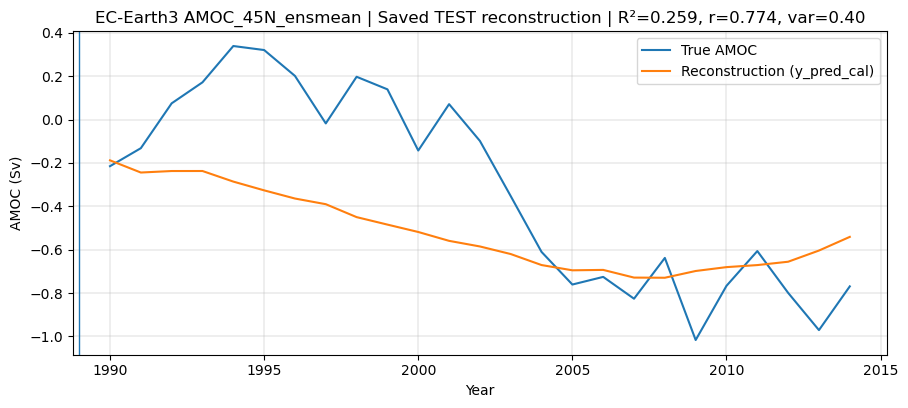

Saved reconstruction plot.


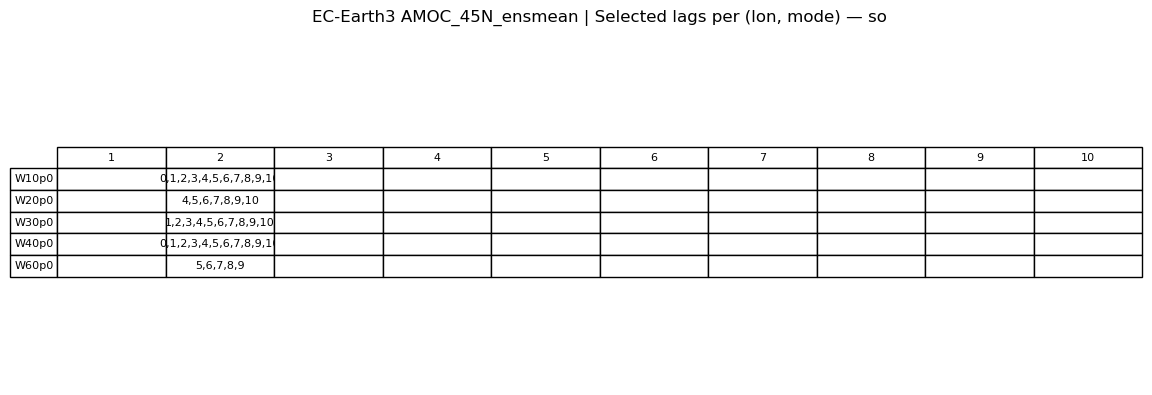

Saved feature map: so


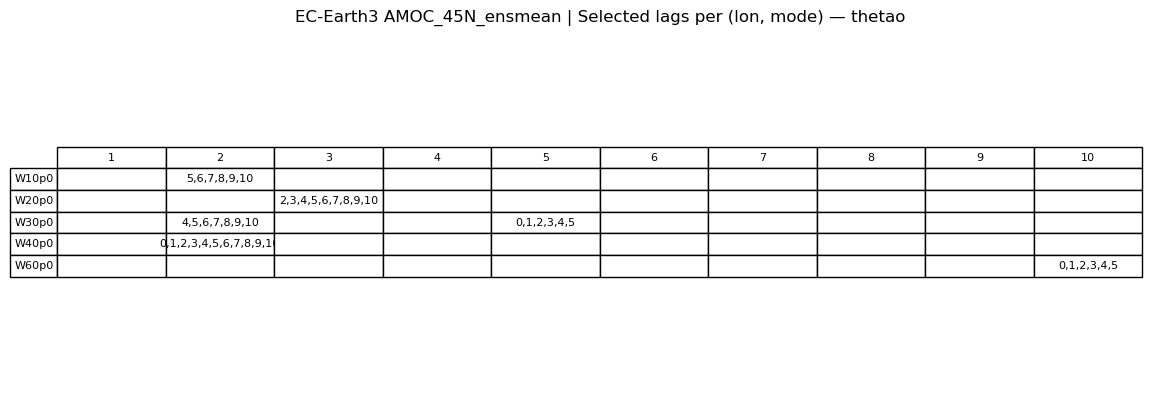

Saved feature map: thetao


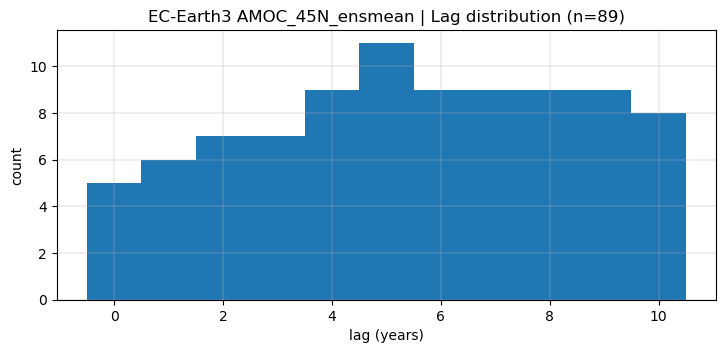

Saved lag histogram.

✅ Done. Figures in: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/EC-Earth3/AMOC_45N_ensmean/ensmean/EOFTRAINONLY_Ydetrend_PCdetrend_R2_0.259_N80_W1_A300/


In [ ]:
#!/usr/bin/env python3
"""
PLOTTING (TRAIN-ONLY EOF basis)
==============================
Uses:
  - saved pipeline outputs (SAVE_TAG files)
  - EOF netCDFs that contain TRAIN_END / train_mask
Ensures split matches EOF training window exactly (no 80/20 fraction assumptions).
"""

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ----------------------------
# USER SETTINGS
# ----------------------------
MODEL   = "IPSL-CM6A-LR"   # "MPI-ESM1-2-LR" or "CESM2"
TARGET  = "AMOC_45N_ensmean"
MODE    = "ensmean"         # "ensmean" or "member"
member_id = None            # set if MODE="member"

VARS     = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES  = 10

EOF_DIR  = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

PIPE_DIR = f"/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/{MODEL}/{TARGET}/mode_{MODE}/EOFtrain_TRAINONLY/"
SAVE_TAG = "EOFTRAINONLY_Ydetrend_PCdetrend_R2_0.259_N80_W1_A300"   # <-- your run id

OUTDIR = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/{SAVE_TAG}/"
os.makedirs(OUTDIR, exist_ok=True)

BEST_FEATURES_CSV     = os.path.join(PIPE_DIR, f"{SAVE_TAG}_final_features.csv")
RANK_CSV              = os.path.join(PIPE_DIR, f"{SAVE_TAG}_trainval_feature_ranking.csv")
BEST_TEST_PRED_CSV    = os.path.join(PIPE_DIR, f"{SAVE_TAG}_test_predictions.csv")
BEST_TEST_METRICS_CSV = os.path.join(PIPE_DIR, f"{SAVE_TAG}_test_metrics.csv")

print("✅ Using saved run:", SAVE_TAG)
print("✅ EOF_DIR:", EOF_DIR)
print("✅ OUTDIR:", OUTDIR)

# ----------------------------
# Helpers
# ----------------------------
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))
    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        else:
            PC = PC.isel(member=int(member_id))

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC.astype(float)

def load_amoc(target, amoc_file, mode="ensmean", member_id=None):
    ds = xr.open_dataset(amoc_file)
    y = ds[target].squeeze()

    years = extract_years(y["time"])
    y = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    y = y.astype(float)

    if "member" in y.dims:
        if mode == "ensmean":
            y = y.mean("member")
        else:
            y = y.isel(member=int(member_id))
    return y.squeeze()

def get_train_end_year_from_eof(eof_dir, var="so", lon="W30p0"):
    """
    Reads TRAIN_END from attrs if present.
    Fallback: uses train_mask to find last train time.
    Returns integer year, e.g. 1989.
    """
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    ds = xr.open_dataset(f)

    # Preferred: attrs
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        return y

    # Fallback: train_mask
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            return int(str(np.datetime64(t_last))[:4])

    raise RuntimeError(f"Could not infer TRAIN_END from {f} (no attrs and no train_mask).")

def savefig(path_base, dpi=220):
    plt.savefig(path_base + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(path_base + ".pdf", dpi=dpi, bbox_inches="tight")

# ----------------------------
# 0) Determine correct split cutoff (from EOF file)
# ----------------------------
TRAIN_END_YEAR = get_train_end_year_from_eof(EOF_DIR, var="so", lon="W30p0")
print("✅ TRAIN_END_YEAR from EOF file =", TRAIN_END_YEAR)

# ----------------------------
# 1) Load ranking + features
# ----------------------------
df_rank = pd.read_csv(RANK_CSV)
if "mode0" not in df_rank.columns and "mode" in df_rank.columns:
    df_rank["mode0"] = df_rank["mode"].astype(int) - 1
if "abs_corr" not in df_rank.columns and "corr" in df_rank.columns:
    df_rank["abs_corr"] = df_rank["corr"].abs()
df_rank["var"] = df_rank["var"].astype(str).str.strip()
df_rank["lon"] = df_rank["lon"].astype(str).str.strip()
df_rank = df_rank.sort_values("abs_corr", ascending=False).reset_index(drop=True)

df_feats = pd.read_csv(BEST_FEATURES_CSV)
if "mode0" in df_feats.columns:
    feats = [(str(r["var"]).strip(), str(r["lon"]).strip(), int(r["mode0"]), int(r["lag"]))
             for _, r in df_feats.iterrows()]
else:
    feats = [(str(r["var"]).strip(), str(r["lon"]).strip(), int(r["mode"]) - 1, int(r["lag"]))
             for _, r in df_feats.iterrows()]

print("Loaded feats:", len(feats))
print("Loaded ranking rows:", len(df_rank))

# ----------------------------
# 2) Load AMOC + PCs (only what ranking needs)
# ----------------------------
amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id)

needed_pairs = sorted(set(zip(df_rank["var"], df_rank["lon"])))
pc_dict = {}
missing = []
for var, lon in needed_pairs:
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        missing.append((var, lon))
        continue
    pc_dict[(var, lon)] = load_pc_latdepth(var, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id)

if missing:
    print("⚠️ Missing EOF files (ignored in ranking plots):")
    for p in missing:
        print("   ", p)

# Align common years
common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years, int)
common_years.sort()

y = amoc.sel(year=common_years).values.astype(float)

# Correct split from EOF train end year
idx_trainval = np.where(common_years <= TRAIN_END_YEAR)[0]
idx_test     = np.where(common_years >  TRAIN_END_YEAR)[0]

print(f"✓ YEARS total: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")
print(f"✓ TRAINVAL:   {common_years[idx_trainval[0]]}–{common_years[idx_trainval[-1]]} (T={len(idx_trainval)})")
print(f"✓ TEST:       {common_years[idx_test[0]]}–{common_years[idx_test[-1]]} (T={len(idx_test)})")

# ----------------------------
# 3) Plot saved test reconstruction (from pipeline output)
# ----------------------------
df_pred = pd.read_csv(BEST_TEST_PRED_CSV)
title_extra = ""
if os.path.exists(BEST_TEST_METRICS_CSV):
    met = pd.read_csv(BEST_TEST_METRICS_CSV).iloc[0].to_dict()
    title_extra = f" | R²={met.get('test_r2', np.nan):.3f}, r={met.get('test_corr', np.nan):.3f}, var={met.get('test_var_ratio', np.nan):.2f}"

plt.figure(figsize=(10.5, 4.2))

plt.plot(df_pred["year"], df_pred["y_true"], label="True AMOC")
# choose prediction column (prefer calibrated)
if "y_pred_cal" in df_pred.columns:
    pred_col = "y_pred_cal"
elif "y_pred" in df_pred.columns:
    pred_col = "y_pred"
elif "y_pred_raw" in df_pred.columns:
    pred_col = "y_pred_raw"
else:
    raise KeyError(f"No prediction column found. Columns are: {list(df_pred.columns)}")

plt.plot(df_pred["year"], df_pred[pred_col], label=f"Reconstruction ({pred_col})")

plt.axvline(TRAIN_END_YEAR, linewidth=1)
plt.xlabel("Year")
plt.ylabel("AMOC (Sv)")
plt.title(f"{MODEL} {TARGET} | Saved TEST reconstruction{title_extra}")
plt.grid(True, linewidth=0.3)
plt.legend(loc="best")
savefig(os.path.join(OUTDIR, "01_saved_test_reconstruction"))
plt.show()
print("Saved reconstruction plot.")

# ----------------------------
# 4) Feature map (simple): for each var, table lon x mode listing lags
# ----------------------------
dfF = pd.DataFrame([{"var":v,"lon":lon,"mode":m0+1,"lag":lag} for (v,lon,m0,lag) in feats])
dfF["lag"] = dfF["lag"].astype(int)

for var in sorted(dfF["var"].unique()):
    g = (dfF[dfF["var"]==var]
         .groupby(["lon","mode"])["lag"]
         .apply(lambda s: ",".join(map(str, sorted(set(s)))))
         .reset_index(name="lags"))

    lons  = LON_TAGS
    modes = list(range(1, N_MODES+1))

    cell = np.full((len(lons), len(modes)), "", dtype=object)
    for _, r in g.iterrows():
        i = lons.index(r["lon"])
        j = modes.index(int(r["mode"]))
        cell[i, j] = r["lags"]

    fig, ax = plt.subplots(figsize=(1.1*len(modes)+3, 0.5*len(lons)+2))
    ax.axis("off")
    tbl = ax.table(
        cellText=cell,
        rowLabels=lons,
        colLabels=[str(m) for m in modes],
        loc="center",
        cellLoc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1.0, 1.3)

    ax.set_title(f"{MODEL} {TARGET} | Selected lags per (lon, mode) — {var}", pad=12)
    savefig(os.path.join(OUTDIR, f"02_feature_map_{var}"))
    plt.show()
    print("Saved feature map:", var)

# ----------------------------
# 5) Lag histogram
# ----------------------------
plt.figure(figsize=(8.5, 3.5))
lags = dfF["lag"].values
bins = np.arange(lags.min(), lags.max()+2) - 0.5
plt.hist(lags, bins=bins)
plt.xlabel("lag (years)")
plt.ylabel("count")
plt.title(f"{MODEL} {TARGET} | Lag distribution (n={len(dfF)})")
plt.grid(True, linewidth=0.3)
savefig(os.path.join(OUTDIR, "03_lag_hist"))
plt.show()
print("Saved lag histogram.")

print("\n✅ Done. Figures in:", OUTDIR)


✅ Using: EOFTRAINONLY_R2_0.802_N20_W1_A30
✅ OUTDIR: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFTRAINONLY_R2_0.802_N20_W1_A30/
✅ TRAIN_END_YEAR = 1989
✓ TRAINVAL: 1850–1989 (T=140)
✓ TEST:     1990–2014 (T=25)


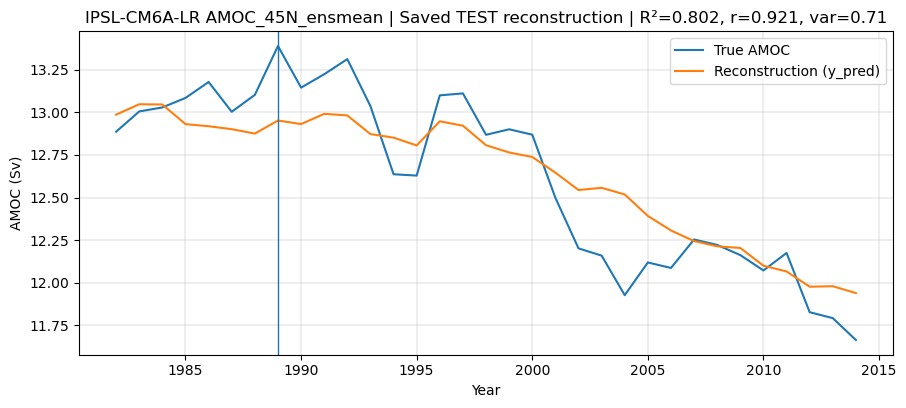


TOP R² SPIKES (feature causing jump)
n=  5 | ΔR²=+0.923 | R²=0.675 | so     W10p0  EOF5  lag16 | |corr|=0.704
n=  8 | ΔR²=+0.065 | R²=0.764 | thetao W30p0  EOF6  lag28 | |corr|=0.695


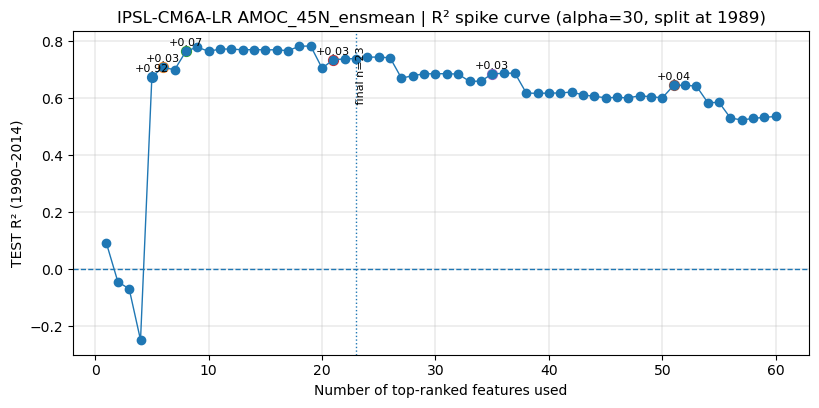

Saved R² spike plot + CSV + top10 text.

✅ Done. Figures in: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFTRAINONLY_R2_0.802_N20_W1_A30/


In [30]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ----------------------------
# USER SETTINGS
# ----------------------------
MODEL   = "IPSL-CM6A-LR"   # "MPI-ESM1-2-LR" or "CESM2"
TARGET  = "AMOC_45N_ensmean"
MODE    = "ensmean"
member_id = None

LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES  = 10

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"
SAVE_TAG  = "EOFTRAINONLY_R2_0.802_N20_W1_A30"   # <-- your run id

PIPE_DIR = f"/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/{MODEL}/{TARGET}/mode_{MODE}/EOFtrain_TRAINONLY/"

OUTDIR = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/{SAVE_TAG}/"
os.makedirs(OUTDIR, exist_ok=True)

BEST_FEATURES_CSV     = os.path.join(PIPE_DIR, f"{SAVE_TAG}_final_features.csv")
RANK_CSV              = os.path.join(PIPE_DIR, f"{SAVE_TAG}_trainval_feature_ranking.csv")
BEST_TEST_PRED_CSV    = os.path.join(PIPE_DIR, f"{SAVE_TAG}_test_predictions.csv")
BEST_TEST_METRICS_CSV = os.path.join(PIPE_DIR, f"{SAVE_TAG}_test_metrics.csv")

# R² spike plot settings
ALPHA_FIXED = 30.0               # match your run (A30)
R2_EVOL_MAX_RANKED = 60         # how far down the ranking to go
SPIKE_THRESH = 0.02              # mark spikes where ΔR² >= this
MIN_TRAIN_SAMPLES = 60           # avoid silly small fits after lag trimming

print("✅ Using:", SAVE_TAG)
print("✅ OUTDIR:", OUTDIR)

# ----------------------------
# Helpers
# ----------------------------
def savefig(path_base, dpi=220):
    plt.savefig(path_base + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(path_base + ".pdf", dpi=dpi, bbox_inches="tight")

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        else:
            PC = PC.isel(member=int(member_id))

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_amoc(target, amoc_file, mode="ensmean", member_id=None):
    ds = xr.open_dataset(amoc_file)
    y = ds[target].squeeze()
    years = extract_years(y["time"])
    y = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    y = y.astype(float)

    if "member" in y.dims:
        if mode == "ensmean":
            y = y.mean("member")
        else:
            y = y.isel(member=int(member_id))

    ds.close()
    return y.squeeze()

def get_train_end_year_from_eof(eof_dir, var="so", lon="W30p0"):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    ds = xr.open_dataset(f)
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])
    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END from {f}")

def build_XY_from_ranked(df_rank, pc_np, years, y, idx_train, idx_test, n_features):
    """
    Build X matrices for a given top-n ranked feature list,
    respecting lags and evaluating on the proper train/test indices.
    """
    top = df_rank.head(int(n_features))

    feats = [(r.var, r.lon, int(r.mode0), int(r.lag)) for r in top.itertuples(index=False)]
    if len(feats) == 0:
        return None

    max_lag = max(l for (_,_,_,l) in feats)

    # usable global indices after lag trimming
    usable = np.arange(max_lag, len(years), dtype=int)

    # intersect with train/test
    tr = np.intersect1d(usable, idx_train)
    te = np.intersect1d(usable, idx_test)

    if len(tr) < MIN_TRAIN_SAMPLES or len(te) < 5:
        return None

    # build X for all usable indices once (fast)
    X_all = np.empty((len(usable), len(feats)), float)
    for i, t in enumerate(usable):
        for j, (var, lon, m0, lag) in enumerate(feats):
            X_all[i, j] = pc_np[(var, lon)][t - lag, m0]

    # map global -> row index in X_all
    pos = {t: i for i, t in enumerate(usable)}
    Xtr = X_all[[pos[t] for t in tr], :]
    Xte = X_all[[pos[t] for t in te], :]

    Ytr = y[tr]
    Yte = y[te]
    return Xtr, Ytr, Xte, Yte, max_lag

# ----------------------------
# 0) Split cutoff from EOF
# ----------------------------
TRAIN_END_YEAR = get_train_end_year_from_eof(EOF_DIR, var="so", lon="W30p0")
print("✅ TRAIN_END_YEAR =", TRAIN_END_YEAR)

# ----------------------------
# 1) Load saved run + ranking
# ----------------------------
df_rank = pd.read_csv(RANK_CSV)
if "mode0" not in df_rank.columns and "mode" in df_rank.columns:
    df_rank["mode0"] = df_rank["mode"].astype(int) - 1
df_rank["var"] = df_rank["var"].astype(str).str.strip()
df_rank["lon"] = df_rank["lon"].astype(str).str.strip()
df_rank["abs_corr"] = pd.to_numeric(df_rank["abs_corr"], errors="coerce")
df_rank = df_rank.dropna(subset=["abs_corr"]).sort_values("abs_corr", ascending=False).reset_index(drop=True)

df_feats = pd.read_csv(BEST_FEATURES_CSV)
n_final_feats = len(df_feats)

# ----------------------------
# 2) Load AMOC + PCs needed by ranking
# ----------------------------
amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id)

needed_pairs = sorted(set(zip(df_rank["var"], df_rank["lon"])))
pc_dict = {}
for var, lon in needed_pairs:
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon}.nc")
    if os.path.exists(f):
        pc_dict[(var, lon)] = load_pc_latdepth(var, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id)

# align years
common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years, int)
common_years.sort()

y = amoc.sel(year=common_years).values.astype(float)
pc_np = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_dict.items()}

# split indices by cutoff year
idx_train = np.where(common_years <= TRAIN_END_YEAR)[0]
idx_test  = np.where(common_years >  TRAIN_END_YEAR)[0]

print(f"✓ TRAINVAL: {common_years[idx_train[0]]}–{common_years[idx_train[-1]]} (T={len(idx_train)})")
print(f"✓ TEST:     {common_years[idx_test[0]]}–{common_years[idx_test[-1]]} (T={len(idx_test)})")

# filter ranking to available pairs
avail = set(pc_np.keys())
mask = df_rank.apply(lambda r: (str(r["var"]).strip(), str(r["lon"]).strip()) in avail, axis=1)
df_rank = df_rank[mask].reset_index(drop=True)

# ----------------------------
# 3) Plot saved reconstruction
# ----------------------------
df_pred = pd.read_csv(BEST_TEST_PRED_CSV)
title_extra = ""
if os.path.exists(BEST_TEST_METRICS_CSV):
    met = pd.read_csv(BEST_TEST_METRICS_CSV).iloc[0].to_dict()
    title_extra = f" | R²={met.get('test_r2', np.nan):.3f}, r={met.get('test_corr', np.nan):.3f}, var={met.get('test_var_ratio', np.nan):.2f}"

plt.figure(figsize=(10.5, 4.2))

plt.plot(df_pred["year"], df_pred["y_true"], label="True AMOC")
# choose prediction column (prefer calibrated)
if "y_pred_cal" in df_pred.columns:
    pred_col = "y_pred_cal"
elif "y_pred" in df_pred.columns:
    pred_col = "y_pred"
elif "y_pred_raw" in df_pred.columns:
    pred_col = "y_pred_raw"
else:
    raise KeyError(f"No prediction column found. Columns are: {list(df_pred.columns)}")

plt.plot(df_pred["year"], df_pred[pred_col], label=f"Reconstruction ({pred_col})")

plt.axvline(TRAIN_END_YEAR, linewidth=1)
plt.xlabel("Year")
plt.ylabel("AMOC (Sv)")
plt.title(f"{MODEL} {TARGET} | Saved TEST reconstruction{title_extra}")
plt.grid(True, linewidth=0.3)
plt.legend(loc="best")
savefig(os.path.join(OUTDIR, "01_saved_test_reconstruction"))
plt.show()

# ----------------------------
# 4) R² spike plot: test R² vs number of top-ranked features
# ----------------------------
maxN = min(int(R2_EVOL_MAX_RANKED), len(df_rank))
rows = []
prev = None
spikes = []

for n in range(1, maxN + 1):
    built = build_XY_from_ranked(df_rank, pc_np, common_years, y, idx_train, idx_test, n)
    if built is None:
        continue
    Xtr, Ytr, Xte, Yte, maxlag = built

    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(ALPHA_FIXED)))
    mdl.fit(Xtr, Ytr)
    pred = mdl.predict(Xte)
    r2 = float(r2_score(Yte, pred))

    if prev is None:
        dr2 = np.nan
    else:
        dr2 = r2 - prev

    rows.append({"n_features": n, "test_r2": r2, "delta_r2": dr2, "max_lag_used": maxlag})

    if np.isfinite(dr2) and dr2 >= SPIKE_THRESH:
        spikes.append((n, dr2, r2))
    prev = r2

df_curve = pd.DataFrame(rows)
df_curve.to_csv(os.path.join(OUTDIR, "04_r2_spike_curve.csv"), index=False)

# --------------------------------------------
# Identify which feature caused each R² spike
# --------------------------------------------
SPIKE_THRESH = 0.05  # same as in plot

spike_rows = []

for i in range(1, len(df_curve)):
    dr2 = df_curve.loc[i, "delta_r2"]
    if np.isfinite(dr2) and dr2 >= SPIKE_THRESH:
        n = int(df_curve.loc[i, "n_features"])

        # Feature added at this step
        r = df_rank.iloc[n-1]

        spike_rows.append({
            "n": n,
            "delta_r2": dr2,
            "test_r2": df_curve.loc[i, "test_r2"],
            "var": r["var"],
            "lon": r["lon"],
            "mode": int(r["mode0"]) + 1,
            "lag": int(r["lag"]),
            "abs_corr": r["abs_corr"]
        })

df_spikes = pd.DataFrame(spike_rows).sort_values("delta_r2", ascending=False)

print("\n==============================")
print("TOP R² SPIKES (feature causing jump)")
print("==============================")

for _, r in df_spikes.iterrows():
    print(
        f"n={int(r['n']):3d} | ΔR²={r['delta_r2']:+.3f} | R²={r['test_r2']:.3f} | "
        f"{r['var']:6s} {r['lon']:6s} EOF{int(r['mode']):<2d} lag{int(r['lag']):<2d} | "
        f"|corr|={r['abs_corr']:.3f}"
    )

plt.figure(figsize=(9.5, 4.2))
plt.plot(df_curve["n_features"], df_curve["test_r2"], marker="o", linewidth=1)
plt.axhline(0.0, linestyle="--", linewidth=1)

# mark spikes
for (n, dr2, r2) in spikes:
    plt.scatter([n], [r2], s=50)
    plt.text(n, r2 + 0.01, f"+{dr2:.2f}", ha="center", va="bottom", fontsize=8)

# show where your final model feature count sits
plt.axvline(n_final_feats, linestyle=":", linewidth=1)
plt.text(n_final_feats, np.nanmax(df_curve["test_r2"]) if len(df_curve) else 0,
         f" final n={n_final_feats}", rotation=90, va="top", fontsize=8)

plt.xlabel("Number of top-ranked features used")
plt.ylabel("TEST R² (1990–2014)")
plt.title(f"{MODEL} {TARGET} | R² spike curve (alpha={ALPHA_FIXED:g}, split at {TRAIN_END_YEAR})")
plt.grid(True, linewidth=0.3)

savefig(os.path.join(OUTDIR, "04_r2_spike_plot"))
plt.show()

# Also write a small text summary of biggest spikes
spikes_sorted = sorted(spikes, key=lambda x: x[1], reverse=True)[:10]
with open(os.path.join(OUTDIR, "04_r2_spikes_top10.txt"), "w") as fp:
    fp.write(f"Top spikes (ΔR² >= {SPIKE_THRESH})\n")
    for n, dr2, r2 in spikes_sorted:
        fp.write(f"n={n:3d}  ΔR²={dr2:.3f}  R²={r2:.3f}\n")

print("Saved R² spike plot + CSV + top10 text.")

print("\n✅ Done. Figures in:", OUTDIR)



Feature order used (columns in X_all):
  F1: so W10p0 EOF5 lag16
✅ TRAIN_END_YEAR inferred from EOF files: 1989
✅ Detrended Y using TRAIN fit: y_trend = 5.8900e-03*year + 1.1620e+00
✅ Saved incremental R² file: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/CUSTOM_FEATURES/IPSL-CM6A-LR_AMOC_45N_ensmean_incremental_r2.csv
Split on years_used:
Train: 1866 – 1989 n= 124
Test : 1990 – 2014 n= 25
Train R²   = 0.2304
Train corr = 0.4894
Test  R²   = -1.0762
Test  corr = -0.1710
✅ Saved reconstruction CSV: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/CUSTOM_FEATURES/IPSL-CM6A-LR_AMOC_45N_ensmean_customx_reconstruction.csv
✅ Saved metadata: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/CUSTOM_FEATURES/IPSL-CM6A-LR_AMOC_45N_ensmean_customx_metadata.txt

CUSTOM FEATURE MODEL
Split year (EOF TRAIN_END): 1989
Alpha = 30
Test R² = -1.0762
Number of features = 1
Max lag = 16 years

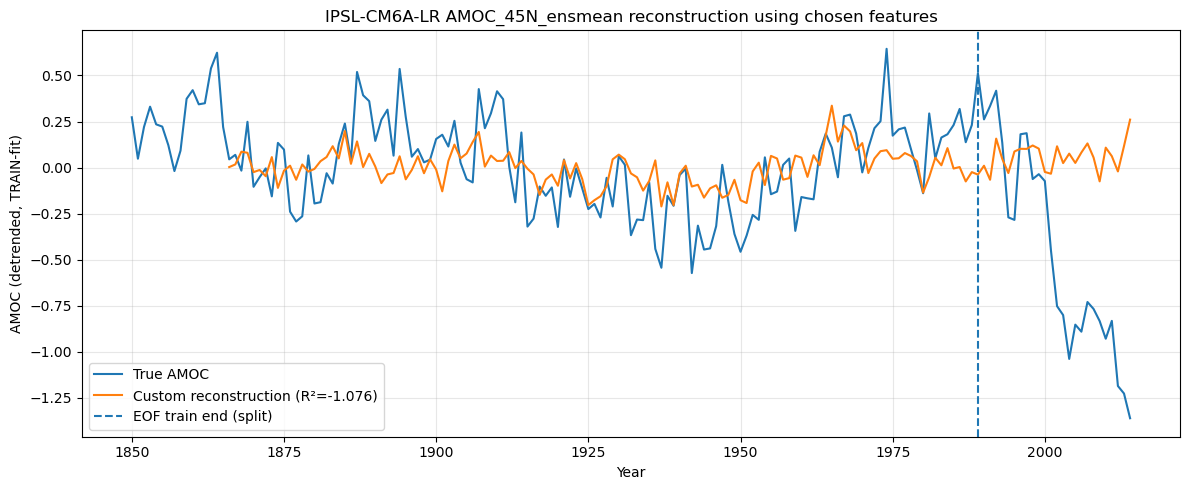

Saved: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/CUSTOM_FEATURES/IPSL-CM6A-LR_AMOC_45N_ensmean_RECON_custom_features.png


In [27]:
# ============================================================
# CUSTOM-FEATURE RECONSTRUCTION (TRAIN-ONLY EOF basis)
# Self-contained: loads AMOC + PCs, builds years/pc_np/y_amoc.
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Prevent HDF5 file locking issues on shared filesystems
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
MODEL  = "IPSL-CM6A-LR"       # model name (must match EOF and AMOC files)
TARGET = "AMOC_45N_ensmean"   # or AMOC_45N_member etc.
MODE   = "ensmean"            # "ensmean" or "member"
member_id = None              # if MODE="member", set int or member label

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"
Save_TAG = "EOFTRAINONLY_R2_0.802_N20_W1_A30"   # your run id for this custom feature experiment

# Output
OUTDIR = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/CUSTOM_FEATURES/"
os.makedirs(OUTDIR, exist_ok=True)

# PC setup
N_MODES = 10
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
VARS = ["thetao", "so"]

# ------------------------------------------------------------
# Choose features (var, lon, mode0, lag)
# mode0 is 0-based (EOF1 -> 0)
# ------------------------------------------------------------
FEATURES = [
    ("so", "W10p0", 4,  16),   # F2
    #("thetao",  "W30p0", 8,  1),   # F1
    #("so",     "W60p0", 0,  1),   # F3
]

# OR load from CSV (overrides FEATURES if not None)
FEATURES_CSV = None

# OR parse from pasted text (overrides FEATURES if not None)
FEATURES_TEXT = None

# Ridge alpha
ALPHA = 30

DETREND_Y = True       # detrend AMOC
DETREND_X = True       # detrend each feature column too (optional)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            # allow label or index
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_amoc(target, amoc_file, mode="ensmean", member_id=None):
    ds = xr.open_dataset(amoc_file)
    y = ds[target].squeeze()

    # some files might already have year; handle both
    if "year" in y.dims:
        am = y
    else:
        years = extract_years(y["time"])
        am = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    am = am.astype(float)

    if "member" in am.dims:
        if mode == "ensmean":
            am = am.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in am.coords and member_id in am["member"].values:
                am = am.sel(member=member_id)
            else:
                am = am.isel(member=int(member_id))

    ds.close()
    return am.squeeze()

def infer_train_end_year_from_any_eof(eof_dir, prefer=("so","W30p0")):
    var, lon = prefer
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        # fallback: first EOF file in directory
        import glob
        hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {eof_dir}")
        f = hits[0]

    ds = xr.open_dataset(f)
    # best: attribute
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y
    # fallback: train_mask
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])
    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END year from {f}")

def _coerce_feats_from_csv(path):
    df = pd.read_csv(path)
    df["var"] = df["var"].astype(str).str.strip()
    df["lon"] = df["lon"].astype(str).str.strip()

    if "mode0" in df.columns:
        mode0 = df["mode0"].astype(int)
    elif "mode" in df.columns:
        mode0 = df["mode"].astype(int) - 1
    else:
        raise KeyError("CSV must contain 'mode0' or 'mode'")

    if "lag" not in df.columns:
        raise KeyError("CSV must contain 'lag'")

    return [(v, l, int(m0), int(lag)) for v, l, m0, lag in zip(df["var"], df["lon"], mode0, df["lag"])]

def _coerce_feats_from_text(txt):
    feats = []
    for line in txt.splitlines():
        line = line.strip()
        if not line:
            continue
        m = re.search(r"(\w+)\s+(W\d+p\d+)\s+EOF(\d+)\s+lag(\d+)", line)
        if not m:
            continue
        var, lon, eofk, lag = m.group(1), m.group(2), int(m.group(3)), int(m.group(4))
        feats.append((var, lon, eofk - 1, lag))
    if not feats:
        raise ValueError("No features parsed from FEATURES_TEXT.")
    return feats

def build_XY_from_feats(pc_np, y, feats, t_positions):
    """
    pc_np: dict[(var,lon)] -> np.ndarray (T, N_MODES)
    y:     np.ndarray (T,)
    feats: list[(var, lon, mode0, lag)]
    t_positions: global indices into [0..T-1]
    """
    t_positions = np.asarray(t_positions, dtype=int)
    max_lag = max((lag for *_, lag in feats), default=0)

    used = t_positions[t_positions >= max_lag]
    if len(used) == 0:
        return np.empty((0, len(feats))), np.empty((0,)), used, int(max_lag)

    X = np.empty((len(used), len(feats)), dtype=float)
    for i, t in enumerate(used):
        for j, (var, lon, m0, lag) in enumerate(feats):
            X[i, j] = pc_np[(var, lon)][t - lag, int(m0)]
    Y = y[used]
    return X, Y, used, int(max_lag)

def fit_linear_trend(train_years, train_series):
    """
    Fit y = a*year + b using TRAIN only.
    Returns (a, b).
    """
    x = np.asarray(train_years, float)
    y = np.asarray(train_series, float)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 2:
        return 0.0, float(np.nanmean(y))

    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(a), float(b)

def detrend_with_train_fit(all_years, all_series, train_mask):
    """
    Fit trend on TRAIN portion, subtract from ALL years.
    Returns: detrended_series, (a,b)
    """
    all_years = np.asarray(all_years, float)
    all_series = np.asarray(all_series, float)
    a, b = fit_linear_trend(all_years[train_mask], all_series[train_mask])
    trend = a * all_years + b
    return all_series - trend, (a, b)

def corr(a, b):
    """Pearson correlation (NaN-safe). Returns np.nan if undefined."""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 2:
        return np.nan
    a = a[m]; b = b[m]
    sa = a.std()
    sb = b.std()
    if sa == 0 or sb == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

# ------------------------------------------------------------
# 0) Feature source selection
# ------------------------------------------------------------
if FEATURES_CSV is not None:
    feats = _coerce_feats_from_csv(FEATURES_CSV)
elif FEATURES_TEXT is not None:
    feats = _coerce_feats_from_text(FEATURES_TEXT)
else:
    feats = FEATURES

# ✅ Preserve order (no sorted(set(...))!)
seen = set()
feats_ordered = []
for ft in feats:
    if ft not in seen:
        feats_ordered.append(ft)
        seen.add(ft)
feats = feats_ordered

print("\nFeature order used (columns in X_all):")
for i, (v, lon, m0, lag) in enumerate(feats, 1):
    print(f"  F{i}: {v} {lon} EOF{m0+1} lag{lag}")


# ------------------------------------------------------------
# 1) Load AMOC + PCs needed
# ------------------------------------------------------------
TRAIN_END_YEAR = infer_train_end_year_from_any_eof(EOF_DIR, prefer=("so","W30p0"))
print("✅ TRAIN_END_YEAR inferred from EOF files:", TRAIN_END_YEAR)

amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id)

# only load required (var,lon) pairs
needed_pairs = sorted(set((v, lon) for (v, lon, _, _) in feats))
pc_dict = {}
for (v, lon) in needed_pairs:
    pc_dict[(v, lon)] = load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id)

# align years across AMOC and PCs
common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years, int)
common_years.sort()

years = common_years
y_amoc = amoc.sel(year=years).values.astype(float)
pc_np = {k: v.sel(year=years).values.astype(float) for k, v in pc_dict.items()}

# ------------------------------------------------------------
# 2+3) MATCH THE SUBSET-SEARCH EXACTLY:
#      build ONE full X,Y using the feature lags, then split on years_used
# ------------------------------------------------------------
maxlag = max(lag for *_, lag in feats)
used_global = np.arange(maxlag, len(years), dtype=int)

X_all = np.empty((len(used_global), len(feats)), float)
for j, (var, lon, m0, lag) in enumerate(feats):
    X_all[:, j] = pc_np[(var, lon)][used_global - lag, m0]

Y_all = y_amoc[used_global]
years_used = years[used_global]

idx_tr = np.where(years_used <= TRAIN_END_YEAR)[0]
idx_te = np.where(years_used >  TRAIN_END_YEAR)[0]

# ------------------------------------------------------------
# 3.0) DETREND using TRAIN-only fit (recommended)
# ------------------------------------------------------------
# masks in "used" space
train_mask_used = np.zeros(len(years_used), dtype=bool)
train_mask_used[idx_tr] = True

if DETREND_Y:
    Y_all_dt, (ay, by) = detrend_with_train_fit(years_used, Y_all, train_mask_used)
    print(f"✅ Detrended Y using TRAIN fit: y_trend = {ay:.4e}*year + {by:.4e}")
else:
    Y_all_dt = Y_all.copy()

if DETREND_X:
    X_all_dt = X_all.copy()
    for j in range(X_all.shape[1]):
        X_all_dt[:, j], (ax, bx) = detrend_with_train_fit(years_used, X_all[:, j], train_mask_used)
else:
    X_all_dt = X_all


# ------------------------------------------------------------
# 3.25) Incremental R² (1, 2, 3... features)
# ------------------------------------------------------------
rows = []

for k in range(1, len(feats) + 1):
    mdl_k = make_pipeline(StandardScaler(), Ridge(alpha=float(ALPHA)))

    # fit on TRAIN (detrended if enabled upstream)
    mdl_k.fit(X_all_dt[idx_tr, :k], Y_all_dt[idx_tr])

    # score on TEST (same detrending basis)
    pred_te_k = mdl_k.predict(X_all_dt[idx_te, :k])
    r2_k = float(r2_score(Y_all_dt[idx_te], pred_te_k))

    rows.append({"n_features": k, "r2_test": r2_k})

inc_df = pd.DataFrame(rows)

inc_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_incremental_r2.csv")
inc_df.to_csv(inc_csv, index=False)
print("✅ Saved incremental R² file:", inc_csv)

print("Split on years_used:")
print("Train:", years_used[idx_tr[0]], "–", years_used[idx_tr[-1]], "n=", len(idx_tr))
print("Test :", years_used[idx_te[0]], "–", years_used[idx_te[-1]], "n=", len(idx_te))

# ------------------------------------------------------------
# 3.30) Fit final model using ALL selected features
# ------------------------------------------------------------
mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(ALPHA)))

# Fit on TRAIN (detrended if enabled upstream)
mdl.fit(X_all_dt[idx_tr, :], Y_all_dt[idx_tr])

pred_tr = mdl.predict(X_all_dt[idx_tr, :])
pred_te = mdl.predict(X_all_dt[idx_te, :])

# --- R² ---
r2_tr = float(r2_score(Y_all_dt[idx_tr], pred_tr))
r2_te = float(r2_score(Y_all_dt[idx_te], pred_te))

corr_tr = corr(Y_all_dt[idx_tr], pred_tr)
corr_te = corr(Y_all_dt[idx_te], pred_te)

print(f"Train R²   = {r2_tr:.4f}")
print(f"Train corr = {corr_tr:.4f}")
print(f"Test  R²   = {r2_te:.4f}")
print(f"Test  corr = {corr_te:.4f}")



# ------------------------------------------------------------
# Build full-length prediction series for plotting (optional)
# ------------------------------------------------------------
y_pred_all = np.full(len(years), np.nan, float)
y_pred_all[used_global[idx_tr]] = pred_tr
y_pred_all[used_global[idx_te]] = pred_te

# ------------------------------------------------------------
# 3.5) SAVE reconstruction for thesis figures
# ------------------------------------------------------------
recon_df = pd.DataFrame({
    "year": years.astype(int),
    "amoc_true": y_amoc.astype(float),
    "amoc_pred": y_pred_all.astype(float),
})

# mark which years are in train/test among the *used* years (after maxlag)
recon_df["is_used"] = False
recon_df.loc[recon_df["year"].isin(years_used.astype(int)), "is_used"] = True

recon_df["is_train"] = False
recon_df["is_test"]  = False
recon_df.loc[recon_df["year"].isin(years_used[idx_tr].astype(int)), "is_train"] = True
recon_df.loc[recon_df["year"].isin(years_used[idx_te].astype(int)), "is_test"]  = True

# add split year + model info (repeated columns make it self-contained)
recon_df["split_year"] = int(TRAIN_END_YEAR)
recon_df["alpha"] = float(ALPHA)
recon_df["test_r2"] = float(r2_te)
recon_df["model"] = MODEL
recon_df["target"] = TARGET
recon_df["mode"] = MODE

# store the chosen features as a single string (handy for captions)
feat_str = " | ".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v, lon, m0, lag) in feats])
recon_df["features"] = feat_str

recon_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_customx_reconstruction.csv")
recon_df.to_csv(recon_csv, index=False)
print("✅ Saved reconstruction CSV:", recon_csv)

# optional: also save a small metadata text file
meta_txt = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_customx_metadata.txt")
with open(meta_txt, "w") as f:
    f.write(f"MODEL={MODEL}\n")
    f.write(f"TARGET={TARGET}\n")
    f.write(f"MODE={MODE}\n")
    f.write(f"TRAIN_END_YEAR={TRAIN_END_YEAR}\n")
    f.write(f"ALPHA={ALPHA}\n")
    f.write(f"TEST_R2={r2_te}\n")
    f.write(f"FEATURES={feat_str}\n")
print("✅ Saved metadata:", meta_txt)


# ------------------------------------------------------------
# 4) Print + plot
# ------------------------------------------------------------
print("\n==============================")
print("CUSTOM FEATURE MODEL")
print("==============================")
print(f"Split year (EOF TRAIN_END): {TRAIN_END_YEAR}")
print(f"Alpha = {ALPHA}")
print(f"Test R² = {r2_te:.4f}")
print(f"Number of features = {len(feats)}")
print(f"Max lag = {max(l for *_, l in feats)} years\n")

for (var, lon, m0, lag) in feats:
    print(f"  {var:6s} {lon:6s} EOF{m0+1:<2d} lag{lag}")

if DETREND_Y:
    # make a full-length detrended AMOC for plotting (TRAIN fit based on used-years TRAIN)
    # fit was computed in used-space; re-use (ay,by) on full years
    y_amoc_dt = y_amoc - (ay * years.astype(float) + by)
    y_plot_true = y_amoc_dt
    y_plot_pred = y_pred_all  # predictions are already detrended scale
    plot_ylabel = "AMOC (detrended, TRAIN-fit)"
else:
    y_plot_true = y_amoc
    y_plot_pred = y_pred_all
    plot_ylabel = "AMOC streamfunction"

plt.figure(figsize=(12, 5))
plt.plot(years, y_plot_true, label="True AMOC")
plt.plot(years, y_plot_pred, label=f"Custom reconstruction (R²={r2_te:.3f})")
plt.axvline(TRAIN_END_YEAR, linestyle="--", label="EOF train end (split)")
plt.title(f"{MODEL} {TARGET} reconstruction using chosen features")
plt.xlabel("Year")
plt.ylabel(plot_ylabel)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

outfile = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_RECON_custom_features.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outfile)

In [15]:
#!/usr/bin/env python3
# ============================================================
# COLLAPSE DUPLICATES (lowest lag) + SUBSET SEARCH (R²)
#   - Reads pipeline final_features.csv (var,lon,mode,lag)
#   - Collapses by (var,lon,mode) keeping LOWEST lag
#   - Builds X once from collapsed features (train-only EOF basis)
#   - Splits by TRAIN_END from EOF file attrs/train_mask
#   - Searches best subsets:
#        * Exhaustive for k=1..K_EXHAUST
#        * Beam search up to k=K_BEAM
#   - Saves results CSVs
# ============================================================

import os
import glob
import itertools
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# =========================
# USER CONFIG
# =========================
MODEL  = "MPI-ESM1-2-LR"  # model name (must match EOF and AMOC files)
TARGET = "AMOC_45N_ensmean"
MODE   = "ensmean"      # "ensmean" or "member"
member_id = None        # if MODE="member"

# Train-only EOF directory (your Train_period_85pct)
EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# Your pipeline selected features (FULL list, possibly with duplicate lags)
FEATURES_CSV = f"/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/{MODEL}/{TARGET}/mode_{MODE}/EOFtrain_TRAINONLY/{SAVE_TAG}_final_features.csv"

# PC settings
N_MODES = 10

# Fixed ridge alpha for fair subset comparison
ALPHA = 10.0

# Search controls
K_EXHAUST  = 10          # exhaustive for k=1..K_EXHAUST (safe if collapsed count ~<=25)
K_BEAM     = 18          # beam search up to this size
BEAM_WIDTH = 300         # keep top B subsets each step
TOP_REPORT = 40          # save/report top N

# =========================
# OUTPUTS
# =========================
OUTDIR = os.path.dirname(FEATURES_CSV)
OUT_COLLAPSED_CSV = FEATURES_CSV.replace(".csv", "_COLLAPSED_lowestLag.csv")
OUT_RESULTS_CSV   = os.path.join(OUTDIR, "subset_search_COLLAPSED_top_results.csv")

# =========================
# HELPERS
# =========================
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def infer_train_end_year(eof_dir):
    # Prefer using attrs TRAIN_END if present; otherwise use train_mask last True index.
    hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
    if not hits:
        raise FileNotFoundError(f"No EOF files found in {eof_dir}")
    f = hits[0]
    ds = xr.open_dataset(f)

    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y

    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])

    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END from attrs/train_mask in {f}")

def load_pc(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        else:
            if member_id is None:
                raise ValueError("member_id required for MODE='member'")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    out = PC.astype(float)

    ds.close()
    return out  # (year, mode)

def load_amoc(target, amoc_file, mode="ensmean", member_id=None):
    ds = xr.open_dataset(amoc_file)
    y = ds[target].squeeze()

    if "year" not in y.dims:
        years = extract_years(y["time"])
        y = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    y = y.astype(float)

    if "member" in y.dims:
        if mode == "ensmean":
            y = y.mean("member")
        else:
            if member_id is None:
                raise ValueError("member_id required for MODE='member'")
            if "member" in y.coords and member_id in y["member"].values:
                y = y.sel(member=member_id)
            else:
                y = y.isel(member=int(member_id))

    ds.close()
    return y.squeeze()  # (year,)

def collapse_lowest_lag(features_csv):
    df = pd.read_csv(features_csv)

    # Clean expected columns
    for c in ["var", "lon", "mode", "lag"]:
        if c not in df.columns:
            raise KeyError(f"Missing column '{c}' in {features_csv}. Found: {list(df.columns)}")

    df["var"]  = df["var"].astype(str).str.strip()
    df["lon"]  = df["lon"].astype(str).str.strip()
    df["mode"] = df["mode"].astype(int)          # 1-based in your file
    df["lag"]  = df["lag"].astype(int)

    # Keep lowest lag per (var,lon,mode)
    dfc = (
        df.sort_values("lag")
          .groupby(["var", "lon", "mode"], as_index=False)
          .first()
          .sort_values(["var", "lon", "mode"])
          .reset_index(drop=True)
    )
    return dfc

def df_to_feats_mode0(dfc):
    # Convert to internal tuple list: (var, lon, mode0, lag)
    feats = []
    for _, r in dfc.iterrows():
        feats.append((str(r["var"]), str(r["lon"]), int(r["mode"]) - 1, int(r["lag"])))
    feats = sorted(set(feats), key=lambda x: (x[0], x[1], x[2], x[3]))
    return feats

def build_full_XY(years, y, pc_np, feats):
    years = np.asarray(years, int)
    y = np.asarray(y, float)
    T = len(years)

    maxlag = max((lag for *_, lag in feats), default=0)
    used = np.arange(maxlag, T, dtype=int)
    if len(used) < 10:
        raise RuntimeError(f"Too few samples after trimming maxlag={maxlag} on T={T}")

    X = np.empty((len(used), len(feats)), float)
    for j, (var, lon, m0, lag) in enumerate(feats):
        arr = pc_np[(var, lon)]
        X[:, j] = arr[used - lag, int(m0)]

    Y = y[used]
    years_used = years[used]
    return X, Y, years_used, int(maxlag)

def split_by_train_end(years_used, train_end_year):
    years_used = np.asarray(years_used, int)
    idx_tr = np.where(years_used <= train_end_year)[0]
    idx_te = np.where(years_used >  train_end_year)[0]
    if len(idx_tr) < 20 or len(idx_te) < 5:
        raise RuntimeError(f"Bad split: train={len(idx_tr)} test={len(idx_te)} with TRAIN_END={train_end_year}")
    return idx_tr, idx_te

def eval_subset(X, Y, idx_tr, idx_te, cols, alpha):
    Xtr = X[idx_tr][:, cols]
    Ytr = Y[idx_tr]
    Xte = X[idx_te][:, cols]
    Yte = Y[idx_te]

    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha)))
    mdl.fit(Xtr, Ytr)
    pred = mdl.predict(Xte)
    return float(r2_score(Yte, pred))

def subset_to_str(feats, cols):
    parts = []
    for j in cols:
        v, lon, m0, lag = feats[j]
        parts.append(f"{v} {lon} EOF{m0+1} lag{lag}")
    return " | ".join(parts)

# =========================
# RUN
# =========================
print("FEATURES_CSV:", FEATURES_CSV)

# ------------------------------------------------------------
# NEW: keep only "forecast" features with lag >= 10 years
# ------------------------------------------------------------

nF = len(feats)

train_end_year = infer_train_end_year(EOF_DIR)
print("\nTRAIN_END_YEAR inferred from EOF files:", train_end_year)

# Load AMOC
amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id)

# Load needed PCs only
pairs = sorted(set((v, lon) for (v, lon, _, _) in feats))
pc_dict = {p: load_pc(p[0], p[1], N_MODES, EOF_DIR, mode=MODE, member_id=member_id) for p in pairs}

# Align years
common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years, int)
common_years.sort()

y_full = amoc.sel(year=common_years).values.astype(float)
pc_np = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_dict.items()}

# Build X once
X_all, Y_all, years_used, maxlag = build_full_XY(common_years, y_full, pc_np, feats)
idx_tr, idx_te = split_by_train_end(years_used, train_end_year)

print(f"\nX_all shape: {X_all.shape}  (maxlag={maxlag})")
print(f"Train used: {years_used[idx_tr[0]]}–{years_used[idx_tr[-1]]} (n={len(idx_tr)})")
print(f"Test  used: {years_used[idx_te[0]]}–{years_used[idx_te[-1]]} (n={len(idx_te)})")
print(f"Collapsed feature count: {nF}")

# =========================
# SEARCH
# =========================
all_cols = list(range(nF))
results = []

K_ex = min(K_EXHAUST, nF)
for k in range(1, K_ex + 1):
    print(f"\n[EXHAUST] k={k} ...")
    best_r2, best_cols = -np.inf, None
    for cols in itertools.combinations(all_cols, k):
        r2 = eval_subset(X_all, Y_all, idx_tr, idx_te, cols, ALPHA)
        if r2 > best_r2:
            best_r2, best_cols = r2, cols
    results.append({
        "k": k,
        "test_r2": best_r2,
        "cols": str(best_cols),
        "features": subset_to_str(feats, best_cols)
    })
    print(f"  best k={k}: R²={best_r2:.4f}")

# Beam search beyond K_ex
if K_BEAM > K_ex and nF > K_ex:
    # start from best subset at k=K_ex
    best0 = max([r for r in results if r["k"] == K_ex], key=lambda d: d["test_r2"])
    seed_cols = eval(best0["cols"])  # tuple
    beam = [(best0["test_r2"], tuple(seed_cols))]

    for k in range(K_ex + 1, min(K_BEAM, nF) + 1):
        print(f"\n[BEAM] k={k} expanding beam={len(beam)} ...")
        cand = {}
        for (_, cols) in beam:
            used = set(cols)
            for j in all_cols:
                if j in used:
                    continue
                new_cols = tuple(sorted(cols + (j,)))
                if new_cols in cand:
                    continue
                cand[new_cols] = eval_subset(X_all, Y_all, idx_tr, idx_te, new_cols, ALPHA)

        top = sorted(cand.items(), key=lambda kv: kv[1], reverse=True)[:BEAM_WIDTH]
        beam = [(r2, cols) for cols, r2 in top]

        best_r2, best_cols = beam[0]
        results.append({
            "k": k,
            "test_r2": best_r2,
            "cols": str(best_cols),
            "features": subset_to_str(feats, best_cols)
        })
        print(f"  best k={k}: R²={best_r2:.4f}")

# Save top results
df_out = pd.DataFrame(results).sort_values("test_r2", ascending=False).head(TOP_REPORT)
df_out.to_csv(OUT_RESULTS_CSV, index=False)

print("\n✅ Saved search results:", OUT_RESULTS_CSV)
print("\nTOP RESULTS:")
for i, r in df_out.reset_index(drop=True).iterrows():
    print(f"#{i+1:02d}  k={int(r.k):2d}  R²={float(r.test_r2):.4f}")
    print("    " + r.features)


FEATURES_CSV: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/MPI-ESM1-2-LR/AMOC_45N_ensmean/mode_ensmean/EOFtrain_TRAINONLY/EOFTRAINONLY_Ydetrend_PCdetrend_R2_0.837_N15_W2_A10_final_features.csv

TRAIN_END_YEAR inferred from EOF files: 1989

X_all shape: (161, 3)  (maxlag=4)
Train used: 1854–1989 (n=136)
Test  used: 1990–2014 (n=25)
Collapsed feature count: 3

[EXHAUST] k=1 ...
  best k=1: R²=0.5791

[EXHAUST] k=2 ...
  best k=2: R²=0.6487

[EXHAUST] k=3 ...
  best k=3: R²=0.5856

✅ Saved search results: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/MPI-ESM1-2-LR/AMOC_45N_ensmean/mode_ensmean/EOFtrain_TRAINONLY/subset_search_COLLAPSED_top_results.csv

TOP RESULTS:
#01  k= 2  R²=0.6487
    so W40p0 EOF2 lag0 | thetao W40p0 EOF7 lag0
#02  k= 3  R²=0.5856
    so W10p0 EOF7 lag4 | so W40p0 EOF2 lag0 | thetao W40p0 EOF7 lag0
#03  k= 1  R²=0.5791
    thetao W40p0 EOF7 lag0


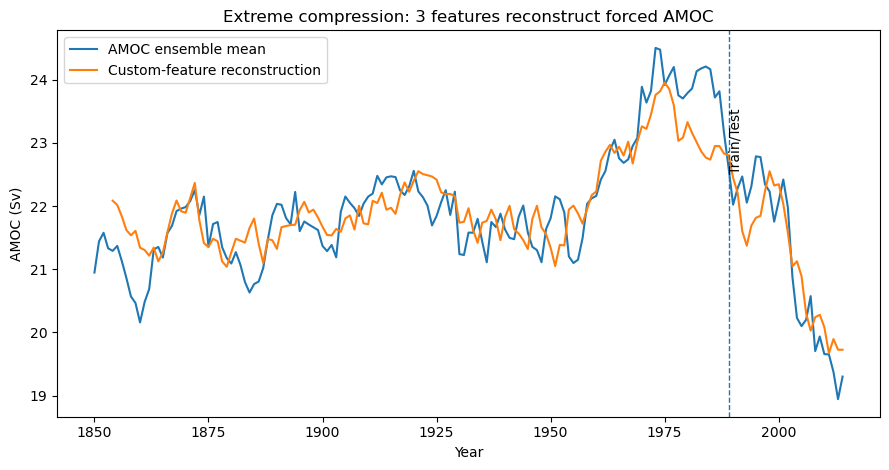

In [ ]:
#!/usr/bin/env python3
"""
FIGURE 1 — 3-feature AMOC ensemble-mean reconstruction
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL = "MPI-ESM1-2-LR"  # for path formatting; must match the CSV's model column

# ---------------- PATHS ----------------
RECON_CSV = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/AMOC_45N_ensmean/ensmean/CUSTOM_FEATURES/{MODEL}_AMOC_45N_ensmean_customx_reconstruction.csv"
# must contain: year, amoc_true, amoc_pred

OUTPNG = "fig1_feature_reconstruction.png"

# ---------------- LOAD ----------------
df = pd.read_csv(RECON_CSV)
df = df.sort_values("year")

# ---------------- PLOT ----------------
plt.figure(figsize=(9, 4.8))
plt.plot(df["year"], df["amoc_true"], label="AMOC ensemble mean")
plt.plot(df["year"], df["amoc_pred"], label="Custom-feature reconstruction")

plt.axvline(1989, linestyle="--", linewidth=1)
plt.text(1989, plt.ylim()[1]*0.95, "Train/Test", rotation=90, va="top")

plt.xlabel("Year")
plt.ylabel("AMOC (Sv)")
plt.title("Extreme compression: 3 features reconstruct forced AMOC")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPNG, dpi=250)
plt.show()


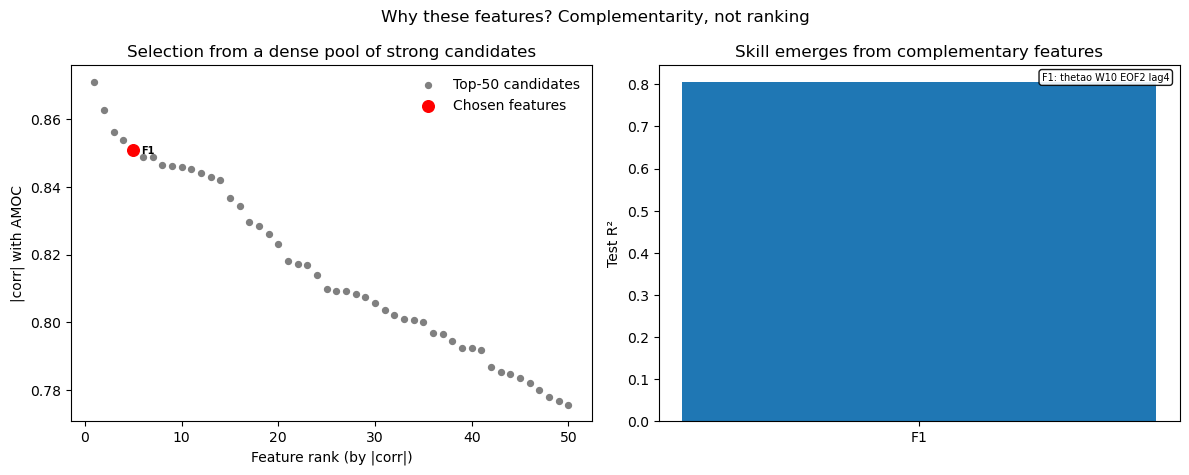

✅ Saved: fig2_feature_complementarity_zoomed.png
Detected 1 feature(s) from recon CSV:
  F1: thetao W10 EOF2 lag4


In [31]:
#!/usr/bin/env python3
"""
FIGURE 2 — Why these features?
Zoomed candidate pool + labeled incremental skill

Works for 1, 2, or 3 features automatically:
- Bar labels become: F1, F1+F2, F1+F2+F3 (as available)
- A small box shows what F1/F2/F3 correspond to (auto-read from RECON_CSV)
- Left panel highlights chosen features if they exist inside the TOPN pool
"""

import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# USER SETTINGS (set these!)
# --------------------------------------------------
MODEL = "CESM2"
SAVE_TAG = "R2_0.789_N30_W2_A0.1"   # <-- update to your CESM2 tag used in filenames

TOPN = 50        # show top-N candidates in left panel
MAX_F = 3        # plot up to this many features (1–3 supported)

# --------------------------------------------------
# PATHS
# --------------------------------------------------
FINAL_FEATS = (
    f"/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/{MODEL}/AMOC_45N_ensmean/"
    f"mode_ensmean/EOFtrain_TRAINONLY/EOFTRAINONLY_{SAVE_TAG}_trainval_feature_ranking.csv"
)

INCREMENTAL = (
    f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/AMOC_45N_ensmean/ensmean/"
    f"CUSTOM_FEATURES/{MODEL}_AMOC_45N_ensmean_incremental_r2.csv"
)

# ✅ read feature order from your reconstruction output
RECON_CSV = (
    f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/AMOC_45N_ensmean/ensmean/"
    f"CUSTOM_FEATURES/{MODEL}_AMOC_45N_ensmean_customx_reconstruction.csv"
)

OUTPNG = "fig2_feature_complementarity_zoomed.png"

# --------------------------------------------------
# HELPERS
# --------------------------------------------------
def prettify(s: str) -> str:
    """
    Example input:  "thetao W40p0 EOF3 lag0"
    Output:         "thetao W40 EOF3 lag0"
    """
    parts = str(s).split()
    if len(parts) < 4:
        return str(s)
    var, lon, eof, lag = parts[0], parts[1], parts[2], parts[3]
    lon_pretty = lon.replace("p0", "")
    return f"{var} {lon_pretty} {eof} {lag}"

def to_tuple(s: str):
    """
    Parse "so W30p0 EOF1 lag3" -> (var, lon, mode(1-based), lag)
    """
    parts = str(s).split()
    if len(parts) < 4:
        raise ValueError(f"Could not parse feature string: {s}")
    var = parts[0]
    lon = parts[1]
    eofnum = int(parts[2].replace("EOF", ""))
    lag = int(parts[3].replace("lag", ""))
    return (var, lon, eofnum, lag)

def find_features_column(df: pd.DataFrame) -> str:
    """
    Try to find the 'features' column robustly.
    """
    for c in ["features", "feature_string", "feat_string"]:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find a features column in RECON_CSV. Columns: {list(df.columns)}")

def find_r2_column(df: pd.DataFrame) -> str:
    """
    Find an R² column robustly (common variants).
    """
    for c in ["r2_test", "test_r2", "r2", "R2_test", "R2"]:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find an R² column in INCREMENTAL CSV. Columns: {list(df.columns)}")

# --------------------------------------------------
# LOAD
# --------------------------------------------------
df = pd.read_csv(FINAL_FEATS).copy()

# be flexible about abs_corr naming
if "abs_corr" not in df.columns:
    if "corr" in df.columns:
        df["abs_corr"] = df["corr"].abs()
    else:
        raise KeyError(f"FINAL_FEATS must contain 'abs_corr' or 'corr'. Columns: {list(df.columns)}")

df = df.sort_values("abs_corr", ascending=False).head(TOPN).copy()

inc = pd.read_csv(INCREMENTAL).copy()
r2_col = find_r2_column(inc)

rec = pd.read_csv(RECON_CSV).copy()
feat_col = find_features_column(rec)

# --------------------------------------------------
# AUTO: parse F1/F2/F3 from RECON_CSV features string
# --------------------------------------------------
feat_str = str(rec[feat_col].dropna().iloc[0])  # should be same for all rows

# features string might be "A | B | C" OR sometimes already a single feature
feat_list = [s.strip() for s in feat_str.split("|") if s.strip()]

nF = min(len(feat_list), MAX_F)
if nF == 0:
    raise ValueError(
        f"No features found in RECON_CSV column '{feat_col}'. "
        f"Got string: {feat_str}"
    )

F_labels = [prettify(s) for s in feat_list[:nF]]
chosen = [to_tuple(s) for s in feat_list[:nF]]

# --------------------------------------------------
# Mark chosen inside candidate pool (if present)
# --------------------------------------------------
# Ensure expected columns exist
for c in ["var", "lon", "mode", "lag"]:
    if c not in df.columns:
        raise KeyError(f"FINAL_FEATS missing column '{c}'. Columns: {list(df.columns)}")

def is_chosen(row):
    return (row["var"], row["lon"], int(row["mode"]), int(row["lag"])) in chosen

df["chosen"] = df.apply(is_chosen, axis=1)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 4.8))

# ===== Panel A: Candidate pool =====
axs[0].scatter(
    range(1, len(df) + 1),
    df["abs_corr"],
    s=18,
    color="gray",
    label=f"Top-{min(TOPN, len(df))} candidates"
)

# highlight chosen (if inside top-N)
chosen_rows = df.loc[df["chosen"]].copy()
if len(chosen_rows) > 0:
    # x positions: rank within the TOPN slice (1..TOPN)
    # IMPORTANT: df.index may not be consecutive, so compute rank by position
    pos = chosen_rows.index.to_series().apply(lambda i: df.index.get_loc(i) + 1).values

    axs[0].scatter(
        pos,
        chosen_rows["abs_corr"].values,
        s=70,
        color="red",
        label="Chosen features",
        zorder=5
    )

    # map each chosen tuple to F1/F2/F3 using recon order
    chosen_map = {tuple(chosen[i]): f"F{i+1}" for i in range(nF)}

    for irow, (idx, row) in enumerate(chosen_rows.iterrows()):
        rank = df.index.get_loc(idx) + 1
        yval = row["abs_corr"]

        tag = chosen_map.get(
            (row["var"], row["lon"], int(row["mode"]), int(row["lag"])),
            ""
        )

        if tag:
            axs[0].text(
                rank + 0.8,
                yval,
                tag,
                fontsize=7,
                color="black",
                va="center",
                ha="left",
                weight="bold"
            )

axs[0].set_xlabel("Feature rank (by |corr|)")
axs[0].set_ylabel("|corr| with AMOC")
axs[0].set_title("Selection from a dense pool of strong candidates")
axs[0].legend(frameon=False)

# ===== Panel B: Incremental skill =====
# Build x labels dynamically: F1, F1+F2, ...
xlabels = ["+".join([f"F{i}" for i in range(1, k + 1)]) for k in range(1, nF + 1)]

vals = inc[r2_col].values[:nF]
axs[1].bar(xlabels, vals, color="tab:blue")

axs[1].set_ylabel("Test R²")
axs[1].set_title("Skill emerges from complementary features")

# ---- small F-box in top-right of Panel B ----
box_txt = "\n".join([f"F{i+1}: {F_labels[i]}" for i in range(nF)])
axs[1].text(
    0.98, 0.98, box_txt,
    transform=axs[1].transAxes,
    ha="right", va="top",
    fontsize=7,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.suptitle("Why these features? Complementarity, not ranking")
plt.tight_layout()
plt.savefig(OUTPNG, dpi=300)
plt.show()

print("✅ Saved:", OUTPNG)
print(f"Detected {nF} feature(s) from recon CSV:")
for i, lab in enumerate(F_labels, 1):
    print(f"  F{i}: {lab}")


In [18]:
#!/usr/bin/env python3
"""
EXPORT PCs FOR EWS FIGURE (Figure 3)
"""

import os
import xarray as xr
import pandas as pd
import numpy as np

MODEL = "MPI-ESM1-2-LR"  # must match your EOF files and will be used in output paths
EOF_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
OUTDIR = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/EWS_PCs/"
os.makedirs(OUTDIR, exist_ok=True)

# (var, lon, eof_number_1based, output_name)
PCS = [
    ("thetao", "W30p0", 9, "PC_thetao_W30_EOF9.csv"),
]

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        return np.array([int(str(t)[:4]) for t in time_coord])

for var, lon, eofk, outname in PCS:
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon}.nc")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=eofk - 1)

    # ensemble mean (important!)
    if "member" in PC.dims:
        PC = PC.mean("member")

    years = extract_years(PC["time"].values)

    df = pd.DataFrame({
        "year": years,
        "value": PC.values.astype(float)
    })

    outfile = os.path.join(OUTDIR, outname)
    df.to_csv(outfile, index=False)
    ds.close()

    print("Saved:", outfile)


Saved: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/MPI-ESM1-2-LR/EWS_PCs/PC_thetao_W30_EOF9.csv


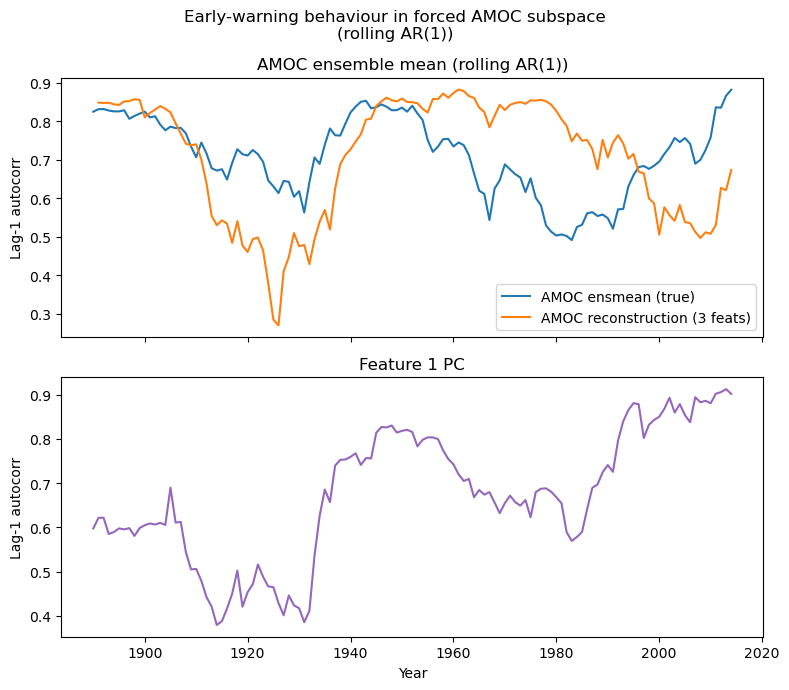

In [19]:
#!/usr/bin/env python3
"""
FIGURE 3 — Early warning signals in forced AMOC subspace
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

MODEL = "MPI-ESM1-2-LR"  # for path formatting; must match the CSV's model column

# ---------------- PATHS ----------------
AMOC_CSV = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/AMOC_45N_ensmean/ensmean/CUSTOM_FEATURES/{MODEL}_AMOC_45N_ensmean_customx_reconstruction.csv"
PC1_CSV  = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/EWS_PCs/PC_thetao_W30_EOF9.csv"
# PC2_CSV  = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/EWS_PCs/PC_thetao_W10_EOF2.csv"

OUTPNG = "fig3_ews_ar1.png"
WINDOW = 40  # years

# ---------------- HELPERS ----------------
def rolling_ar1(x, w):
    ar = np.full(len(x), np.nan)
    for i in range(w, len(x)):
        xx = x[i-w:i]
        xx = xx - np.mean(xx)
        ar[i] = acf(xx, nlags=1, fft=False)[1]
    return ar

# ---------------- LOAD ----------------
amoc = pd.read_csv(AMOC_CSV)
pc1  = pd.read_csv(PC1_CSV)
# pc2  = pd.read_csv(PC2_CSV)

# ---------------- COMPUTE ----------------
# AMOC series comes from reconstruction CSV
ar_amoc_true = rolling_ar1(amoc["amoc_true"].values, WINDOW)

# optional: also compute AR(1) on reconstruction (useful sanity check)
ar_amoc_pred = rolling_ar1(amoc["amoc_pred"].values, WINDOW)

ar_pc1  = rolling_ar1(pc1["value"].values, WINDOW)
# ar_pc2  = rolling_ar1(pc2["value"].values, WINDOW)

# ---------------- PLOT ----------------
fig, axs = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

axs[0].plot(amoc["year"], ar_amoc_true, label="AMOC ensmean (true)")
axs[0].plot(amoc["year"], ar_amoc_pred, label="AMOC reconstruction (3 feats)")
axs[0].legend()
axs[0].set_title("AMOC ensemble mean (rolling AR(1))")


axs[1].plot(pc1["year"], ar_pc1, color="tab:purple")
axs[1].set_title("Feature 1 PC")

# axs[2].plot(pc2["year"], ar_pc2, color="tab:green")
# axs[2].set_title("Feature 3 PC")

for ax in axs:
    ax.set_ylabel("Lag-1 autocorr")

axs[-1].set_xlabel("Year")
plt.suptitle("Early-warning behaviour in forced AMOC subspace\n(rolling AR(1))")
plt.tight_layout()
plt.savefig(OUTPNG, dpi=250)
plt.show()

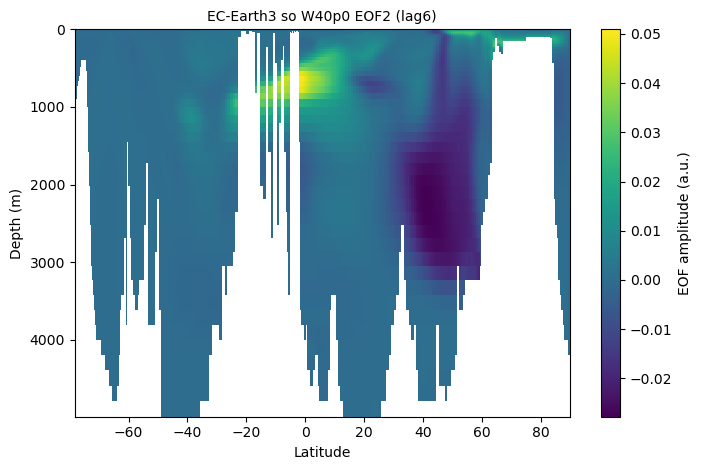

Plotted: so W40p0 EOF2 lag6
From: /data/projects/nckf/frekle/EOF_results/EC-Earth3/latdepth_sections/Train_period_85pct/EOF_latdepth_so_W40p0.nc


In [2]:
# ============================================================
# EXTRA: Spatial EOF plot for ONE chosen feature (run after EWS)
# Inspired by your working load_latdepth_grid + plot_latdepth_eof method
# ============================================================

import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ---- USER: set these ----
MODEL = "EC-Earth3"
EOF_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"

# Most important feature (type it manually)
FEATURE_STR = "so W40p0 EOF2 lag6"   # <-- edit this

# ---- helpers ----
def parse_feature_str(feature_str):
    # "thetao W10p0 EOF2 lag4" -> var="thetao", lon="W10p0", mode0=1, lag=4
    parts = str(feature_str).split()
    if len(parts) < 4:
        raise ValueError(f"Bad FEATURE_STR: {feature_str}")
    var = parts[0]
    lon_tag = parts[1]
    mode1 = int(parts[2].replace("EOF", ""))  # 1-based
    lag = int(parts[3].replace("lag", ""))
    return var, lon_tag, mode1 - 1, lag

def load_latdepth_grid(ds):
    # latitude
    lat = None
    for nm in ["lat", "latitude", "y"]:
        if nm in ds.coords:
            lat = ds[nm].values
            break
        if nm in ds.variables:
            lat = ds[nm].values
            break
    if lat is None:
        raise KeyError(f"No latitude found. coords={list(ds.coords)} vars={list(ds.variables)}")

    # depth/lev
    lev = None
    for nm in ["lev", "depth", "olevel", "z", "deptht"]:
        if nm in ds.coords:
            lev = ds[nm].values
            break
        if nm in ds.variables:
            lev = ds[nm].values
            break
    if lev is None:
        raise KeyError(f"No depth/lev found. coords={list(ds.coords)} vars={list(ds.variables)}")

    lat = np.asarray(lat).squeeze()
    lev = np.asarray(lev).squeeze()
    return lat, lev

def plot_latdepth_eof(ax, lat, lev, EOF2d, title=""):
    EOF2d = np.asarray(EOF2d)

    # Detect orientation and enforce Z shape = (lev, lat)
    if EOF2d.shape == (len(lev), len(lat)):
        Z = EOF2d
    elif EOF2d.shape == (len(lat), len(lev)):
        Z = EOF2d.T
    else:
        raise ValueError(
            f"EOF shape {EOF2d.shape} doesn't match "
            f"(lev,lat)=({len(lev)},{len(lat)}) or (lat,lev)=({len(lat)},{len(lev)})"
        )

    im = ax.pcolormesh(lat, lev, Z, shading="auto")
    ax.invert_yaxis()
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Latitude")
    ax.set_ylabel("Depth (m)")
    return im

# ---- run ----
var, lon_tag, mode0, lag = parse_feature_str(FEATURE_STR)

eof_file = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
if not os.path.exists(eof_file):
    raise FileNotFoundError(f"Missing EOF file: {eof_file}")

ds = xr.open_dataset(eof_file)

if "EOF" not in ds:
    raise KeyError(f"'EOF' not found in {eof_file}. Available vars: {list(ds.data_vars)}")

EOF = ds["EOF"].isel(mode=int(mode0)).values
lat, lev = load_latdepth_grid(ds)

ds.close()

fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.8))
im = plot_latdepth_eof(
    ax, lat, lev, EOF,
    title=f"{MODEL} {var} {lon_tag} EOF{mode0+1} (lag{lag})"
)
plt.colorbar(im, ax=ax, label="EOF amplitude (a.u.)")
plt.tight_layout()
plt.show()

print("Plotted:", FEATURE_STR)
print("From:", eof_file)


In [ ]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

def load_latdepth_grid(ds):
    """
    Robustly grab lat + depth/lev from the EOF dataset.
    Returns (lat, lev) as 1D numpy arrays.
    """
    # latitude
    for nm in ["lat", "latitude", "y"]:
        if nm in ds.coords:
            lat = ds[nm].values
            break
        if nm in ds.variables:
            lat = ds[nm].values
            break
    else:
        raise KeyError(f"Could not find latitude coord in ds. coords={list(ds.coords)} vars={list(ds.variables)}")

    # depth (your older code calls it lev)
    for nm in ["lev", "depth", "olevel", "z", "deptht"]:
        if nm in ds.coords:
            lev = ds[nm].values
            break
        if nm in ds.variables:
            lev = ds[nm].values
            break
    else:
        raise KeyError(f"Could not find depth/lev coord in ds. coords={list(ds.coords)} vars={list(ds.variables)}")

    # ensure 1D
    lat = np.asarray(lat).squeeze()
    lev = np.asarray(lev).squeeze()
    return lat, lev

def plot_latdepth_eof(ax, lat, lev, EOF2d, title=""):
    """
    EOF2d expected shape either (lev, lat) or (lat, lev).
    We will detect and transpose if needed.
    """
    EOF2d = np.asarray(EOF2d)

    # Detect orientation
    if EOF2d.shape == (len(lev), len(lat)):
        Z = EOF2d
    elif EOF2d.shape == (len(lat), len(lev)):
        Z = EOF2d.T
    else:
        raise ValueError(
            f"EOF shape {EOF2d.shape} does not match "
            f"(lev,lat)=({len(lev)},{len(lat)}) or (lat,lev)=({len(lat)},{len(lev)})"
        )

    im = ax.pcolormesh(lat, lev, Z, shading="auto")
    ax.invert_yaxis()
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Latitude")
    ax.set_ylabel("Depth (m)")
    return im

def parse_feature_str(feature_str):
    """
    "thetao W10p0 EOF2 lag4" -> var="thetao", lon_tag="W10p0", mode0=1, lag=4
    """
    parts = str(feature_str).split()
    if len(parts) < 4:
        raise ValueError(f"Bad feature_str: {feature_str}")
    var = parts[0]
    lon = parts[1]
    mode1 = int(parts[2].replace("EOF", ""))  # 1-based
    lag = int(parts[3].replace("lag", ""))
    return var, lon, mode1 - 1, lag

# ------------------------------------------------------------
# ADD THIS WHERE YOU MAKE YOUR FIGURE:
# ------------------------------------------------------------
# USER: set the key feature (most important) manually:
FEATURE_STR = "thetao W10p0 EOF2 lag4"

# Make sure this matches your EOF folder
EOF_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"

var, lon_tag, mode0, lag = parse_feature_str(FEATURE_STR)

eof_file = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
if not os.path.exists(eof_file):
    raise FileNotFoundError(f"Missing EOF file: {eof_file}")

ds = xr.open_dataset(eof_file)

# This matches your previous working code:
EOF = ds["EOF"].isel(mode=int(mode0)).values
lat, lev = load_latdepth_grid(ds)

ds.close()

# Now plot it (example: put it as a 3rd panel)
# If you already have axs from your rolling AR(1) figure:
# ax_spatial = axs[2]   (if you made 3 rows)
# Otherwise create a new axes:
fig_sp = plt.figure(figsize=(6.5, 4.5))
ax_spatial = fig_sp.add_subplot(1, 1, 1)

im = plot_latdepth_eof(
    ax_spatial, lat, lev, EOF,
    title=f"{MODEL} {var} {lon_tag} EOF{mode0+1} (lag{lag})"
)
plt.colorbar(im, ax=ax_spatial, label="EOF amplitude (a.u.)")
plt.tight_layout()
plt.show()


In [17]:
#!/usr/bin/env python3
"""
PRINT SUMMARY FOR THESIS FIGURES (Fig 1–3)
"""

import pandas as pd
import numpy as np

MODEL = "MPI-ESM1-2-LR"  # for path formatting; must match the CSV's model column
SAVE_TAG = "EOFTRAINONLY_Ydetrend_PCdetrend_R2_0.837_N15_W2_A10"

# --------------------------------------------------
# PATHS (EDIT THESE)
# ------------------------------------------------
RECON_CSV = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/AMOC_45N_ensmean/ensmean/CUSTOM_FEATURES/{MODEL}_AMOC_45N_ensmean_customx_reconstruction.csv"
FINAL_FEATS = f"/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/{MODEL}/AMOC_45N_ensmean/mode_ensmean/EOFtrain_TRAINONLY/{SAVE_TAG}_trainval_feature_ranking.csv"
INCREMENTAL = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/AMOC_45N_ensmean/ensmean/CUSTOM_FEATURES/{MODEL}_AMOC_45N_ensmean_incremental_r2.csv"

# chosen features (must match reconstruction)
CHOSEN = [
    ("thetao", "W30p0", 8, 1),
]

# --------------------------------------------------
# FIGURE 1 SUMMARY — Reconstruction
# --------------------------------------------------
print("\n" + "="*80)
print("FIGURE 1 — 3-FEATURE RECONSTRUCTION SUMMARY")
print("="*80)

rec = pd.read_csv(RECON_CSV)

used = rec["is_used"].values
train = rec["is_train"].values
test  = rec["is_test"].values

def r2(y, yhat):
    m = np.isfinite(y) & np.isfinite(yhat)
    return 1 - np.sum((y[m] - yhat[m])**2) / np.sum((y[m] - y[m].mean())**2)

r2_train = r2(rec.loc[train, "amoc_true"], rec.loc[train, "amoc_pred"])
r2_test  = r2(rec.loc[test,  "amoc_true"], rec.loc[test,  "amoc_pred"])

print(f"Years used (after max lag): {rec.loc[used,'year'].min()}–{rec.loc[used,'year'].max()}")
print(f"Train years: {rec.loc[train,'year'].min()}–{rec.loc[train,'year'].max()}  (n={train.sum()})")
print(f"Test  years: {rec.loc[test, 'year'].min()}–{rec.loc[test, 'year'].max()}   (n={test.sum()})")
print(f"Train R²: {r2_train:.3f}")
print(f"Test  R²: {r2_test:.3f}")

print("\nChosen features:")
for v,l,m,lag in CHOSEN:
    print(f"  {v:6s} {l:6s} EOF{m} lag{lag}")

# --------------------------------------------------
# FIGURE 2 SUMMARY — Candidate pool + complementarity
# --------------------------------------------------
print("\n" + "="*80)
print("FIGURE 2 — FEATURE SELECTION SUMMARY")
print("="*80)

df = pd.read_csv(FINAL_FEATS).sort_values("abs_corr", ascending=False)

print(f"Total candidate features: {len(df)}")
print("Top 50 candidates by |corr|:")
for _, r in df.head(50).iterrows():
    print(
    f"  {r['var']:6s} {r['lon']:6s} "
    f"EOF{int(r['mode'])} lag{int(r['lag']):<2d} |corr|={r['abs_corr']:.3f}"
)


print("\nRanks of chosen features:")
for v,l,m,lag in CHOSEN:
    rank = np.where(
        (df["var"]==v) & (df["lon"]==l) & (df["mode"]==m) & (df["lag"]==lag)
    )[0]
    if len(rank):
        print(f"  {v:6s} {l:6s} EOF{m} lag{lag:<2d} → rank {rank[0]+1}")
    else:
        print(f"  {v:6s} {l:6s} EOF{m} lag{lag:<2d} → NOT FOUND")

# incremental R²
inc = pd.read_csv(INCREMENTAL)
print("\nIncremental test R²:")
for _, r in inc.iterrows():
    print(f"  {int(r.n_features)} feature(s): R²={r.r2_test:.3f}")

# --------------------------------------------------
# FIGURE 3 SUMMARY — Early-warning diagnostics (prep)
# --------------------------------------------------
print("\n" + "="*80)
print("FIGURE 3 — EWS CONTEXT SUMMARY")
print("="*80)

print("Interpretation setup:")
print("- EWS should be interpreted on:")
print("    • AMOC ensemble mean")
print("    • PCs corresponding to the chosen 3 features")
print("- Lags used in reconstruction are short (0–3 years)")
print("- Model is diagnostic, not a long-lead forecast")
print("- AR(1) / variance trends should be interpreted as stability indicators")

print("\nSummary ready for interpretation.")
print("="*80)



FIGURE 1 — 3-FEATURE RECONSTRUCTION SUMMARY
Years used (after max lag): 1851–2014
Train years: 1851–1989  (n=139)
Test  years: 1990–2014   (n=25)
Train R²: -2618.912
Test  R²: -1359.207

Chosen features:
  thetao W30p0  EOF8 lag1

FIGURE 2 — FEATURE SELECTION SUMMARY
Total candidate features: 2000
Top 50 candidates by |corr|:
  thetao W40p0  EOF6 lag2  |corr|=0.640
  thetao W40p0  EOF6 lag1  |corr|=0.635
  thetao W40p0  EOF6 lag3  |corr|=0.631
  so     W10p0  EOF7 lag7  |corr|=0.585
  thetao W40p0  EOF6 lag0  |corr|=0.573
  so     W10p0  EOF7 lag8  |corr|=0.570
  thetao W30p0  EOF9 lag1  |corr|=0.570
  thetao W30p0  EOF9 lag0  |corr|=0.568
  so     W60p0  EOF3 lag1  |corr|=0.566
  thetao W30p0  EOF9 lag2  |corr|=0.565
  so     W10p0  EOF7 lag6  |corr|=0.561
  thetao W40p0  EOF6 lag4  |corr|=0.561
  so     W60p0  EOF3 lag2  |corr|=0.561
  so     W60p0  EOF1 lag1  |corr|=0.551
  so     W40p0  EOF2 lag2  |corr|=0.548
  thetao W30p0  EOF9 lag3  |corr|=0.544
  so     W60p0  EOF3 lag0  |cor

✅ Feature matrix rebuilt: (161, 1)


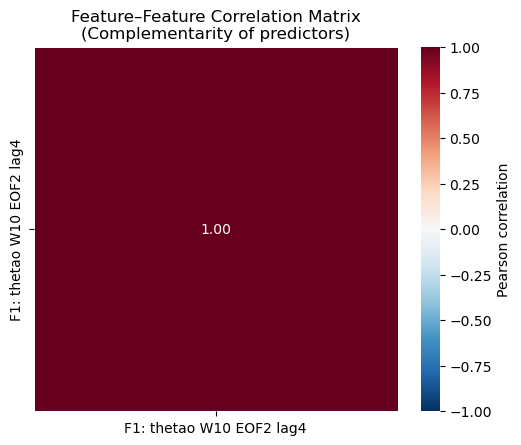

✅ Saved: fig_feature_feature_correlation.png


In [39]:
#!/usr/bin/env python3
"""
FEATURE–FEATURE CORRELATION MATRIX
Shows complementarity of the 3 selected predictors
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# PATHS
# --------------------------------------------------
RECON_CSV = (
    "/data/users/frekle/AMOC_analysis/THESIS_FIGURES/"
    f"{MODEL}/AMOC_45N_ensmean/ensmean/CUSTOM_FEATURES/"
    f"{MODEL}_AMOC_45N_ensmean_customx_reconstruction.csv"
)

# --------------------------------------------------
# FEATURE DEFINITIONS (must match reconstruction order)
# --------------------------------------------------
FEATURE_NAMES = [
    "F1: thetao W10 EOF2 lag4",
]

# --------------------------------------------------
# LOAD RECONSTRUCTION + PCs USED
# --------------------------------------------------
df = pd.read_csv(RECON_CSV)

# Only use years actually used in regression (after max lag)
df = df[df["is_used"]].copy()

# Load the feature matrix that was implicitly used
# (we reconstruct it from stored PCs in the pipeline)
# --------------------------------------------------
# ==========================================================
# BUILD FEATURE MATRIX DIRECTLY FROM EOF PCs
# (same logic as reconstruction script)
# ==========================================================

import xarray as xr
import numpy as np
import os

# --------------------------------------------------
# SETTINGS — must match reconstruction
# --------------------------------------------------
MODEL  = "CESM2"
MODE   = "ensmean"

EOF_DIR = (
    "/data/projects/nckf/frekle/EOF_results/"
    f"{MODEL}/latdepth_sections/Train_period_85pct/"
)

# IMPORTANT — must match feature order in reconstruction
FEATURES = [
    ("thetao", "W10p0", 2, 4),
]

FEATURE_NAMES = [
    "F1: thetao W10 EOF2 lag4",
]

# --------------------------------------------------
# HELPER: load PC
# --------------------------------------------------
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc(var, lon_tag):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    ds = xr.open_dataset(f)
    PC = ds["PC"].mean("member")   # ensmean
    PC = PC.transpose("time","mode")

    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years))
    PC = PC.swap_dims({"time":"year"}).drop_vars("time")
    ds.close()
    return PC.values.astype(float), years

# --------------------------------------------------
# LOAD ALL REQUIRED PCs
# --------------------------------------------------
pc_np = {}
years_common = None

for (var, lon, _, _) in FEATURES:
    pc, years = load_pc(var, lon)
    pc_np[(var,lon)] = pc

    if years_common is None:
        years_common = years
    else:
        years_common = np.intersect1d(years_common, years)

years_common = np.sort(years_common)

# Align PCs on common years
for k in pc_np:
    # reload aligned to years_common
    ds = xr.open_dataset(os.path.join(
        EOF_DIR, f"EOF_latdepth_{k[0]}_{k[1]}.nc"))
    PC = ds["PC"].mean("member").transpose("time","mode")
    yrs = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", yrs)).swap_dims({"time":"year"}).drop_vars("time")
    pc_np[k] = PC.sel(year=years_common).values.astype(float)
    ds.close()

# --------------------------------------------------
# APPLY LAGS (exactly like reconstruction)
# --------------------------------------------------
maxlag = max(lag for *_, lag in FEATURES)
used_global = np.arange(maxlag, len(years_common))

X = np.empty((len(used_global), len(FEATURES)))

for j,(var,lon,m0,lag) in enumerate(FEATURES):
    X[:,j] = pc_np[(var,lon)][used_global - lag, m0]

# Convert to DataFrame
X = pd.DataFrame(X, columns=FEATURE_NAMES)

print("✅ Feature matrix rebuilt:", X.shape)

# --------------------------------------------------
# CORRELATION MATRIX
# --------------------------------------------------
corr = X.corr()

# --------------------------------------------------
# PLOT
# --------------------------------------------------
plt.figure(figsize=(5.5, 4.5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws=dict(label="Pearson correlation"),
    linewidths=0.5
)

plt.title("Feature–Feature Correlation Matrix\n(Complementarity of predictors)")
plt.tight_layout()
plt.savefig("fig_feature_feature_correlation.png", dpi=300)
plt.show()

print("✅ Saved: fig_feature_feature_correlation.png")


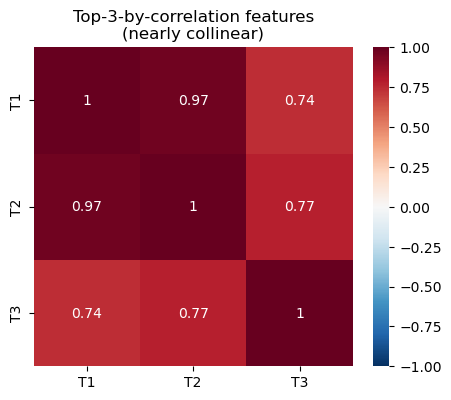

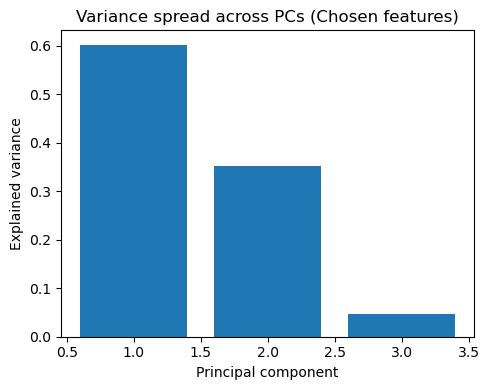

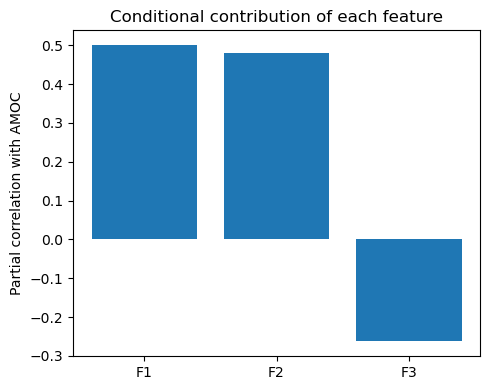


✅ Diagnostic figures saved:
  figA_top3_corrmatrix.png
  figB_pca_variance.png
  figC_partial_corr.png


In [6]:
#!/usr/bin/env python3
"""
FEATURE DIAGNOSTIC FIGURES
-------------------------------------------------
A) Feature–feature correlation: Top-3-by-corr
B) PCA of chosen 3 features
C) Partial correlations vs AMOC
-------------------------------------------------
Uses EXACT same PCs + lags as reconstruction
"""

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# ============================================================
# SETTINGS  (must match reconstruction)
# ============================================================

MODEL = "IPSL-CM6A-LR"
EOF_DIR = "/data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/latdepth_sections/Train_period_85pct/"
AMOC_FILE = "/data/users/frekle/AMOC_analysis/AMOC_IPSL-CM6A-LR.nc"

TARGET = "AMOC_45N_ensmean"

# ---- YOUR CHOSEN FEATURES ----
FEATS_CHOSEN = [
    ("so","W60p0",0,1),   # F1
    ("thetao","W40p0",2,0), # F2
    ("so","W30p0",0,3),   # F3
]

NAMES_CHOSEN = ["F1","F2","F3"]

# ---- TOP-3 BY CORRELATION (from ranking list) ----
FEATS_TOP3 = [
    ("so","W60p0",0,1),
    ("so","W60p0",0,2),
    ("so","W60p0",0,8),
]

NAMES_TOP3 = ["T1","T2","T3"]

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], int)

def load_pc(var,lon):
    f = os.path.join(EOF_DIR,f"EOF_latdepth_{var}_{lon}.nc")
    ds = xr.open_dataset(f)
    PC = ds["PC"].mean("member").transpose("time","mode")
    yrs = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time",yrs)).swap_dims({"time":"year"}).drop_vars("time")
    ds.close()
    return PC

def load_amoc():
    ds = xr.open_dataset(AMOC_FILE)
    y = ds[TARGET]

    # If member exists (member-wise target), average it
    if "member" in y.dims:
        y = y.mean("member")

    # Drop singleton x dim if present
    if "x" in y.dims and y.sizes["x"] == 1:
        y = y.isel(x=0)

    # Convert time -> year coordinate
    yrs = extract_years(y["time"])
    y = y.assign_coords(year=("time", yrs)).swap_dims({"time": "year"}).drop_vars("time")

    ds.close()
    return y.squeeze()

def build_feature_matrix(feats):

    pc_dict = {}
    years_common = None

    for (v,l,_,_) in feats:
        pc = load_pc(v,l)
        pc_dict[(v,l)] = pc

        if years_common is None:
            years_common = pc["year"].values
        else:
            years_common = np.intersect1d(years_common, pc["year"].values)

    years_common = np.sort(years_common)

    for k in pc_dict:
        pc_dict[k] = pc_dict[k].sel(year=years_common).values

    maxlag = max(lag for *_,lag in feats)
    used = np.arange(maxlag,len(years_common))

    X = np.empty((len(used),len(feats)))

    for j,(v,l,m0,lag) in enumerate(feats):
        X[:,j] = pc_dict[(v,l)][used-lag,m0]

    return X, years_common[used]

# ============================================================
# LOAD DATA
# ============================================================

X_chosen, years = build_feature_matrix(FEATS_CHOSEN)
X_top3 , _      = build_feature_matrix(FEATS_TOP3)

amoc = load_amoc().sel(year=years).values

# standardize for diagnostics
scaler = StandardScaler()
Xc = scaler.fit_transform(X_chosen)
Xt = scaler.fit_transform(X_top3)

# ============================================================
# FIGURE A — TOP3 CORRELATION MATRIX
# ============================================================

plt.figure(figsize=(4.8,4))
sns.heatmap(
    pd.DataFrame(Xt,columns=NAMES_TOP3).corr(),
    annot=True, cmap="RdBu_r", vmin=-1, vmax=1, square=True
)
plt.title("Top-3-by-correlation features\n(nearly collinear)")
plt.tight_layout()
plt.savefig("figA_top3_corrmatrix.png",dpi=300)
plt.show()

# ============================================================
# FIGURE B — PCA OF CHOSEN FEATURES
# ============================================================

pca = PCA().fit(Xc)
var = pca.explained_variance_ratio_

plt.figure(figsize=(5,4))
plt.bar([1,2,3],var)
plt.xlabel("Principal component")
plt.ylabel("Explained variance")
plt.title("Variance spread across PCs (Chosen features)")
plt.tight_layout()
plt.savefig("figB_pca_variance.png",dpi=300)
plt.show()

# ============================================================
# FIGURE C — PARTIAL CORRELATIONS
# ============================================================

def partial_corr(x,y,others):

    reg = LinearRegression()
    reg.fit(others,x)
    x_res = x - reg.predict(others)

    reg.fit(others,y)
    y_res = y - reg.predict(others)

    return np.corrcoef(x_res,y_res)[0,1]

partials = []

for i in range(3):
    others = np.delete(Xc,i,axis=1)
    pc = partial_corr(Xc[:,i],amoc,others)
    partials.append(pc)

plt.figure(figsize=(5,4))
plt.bar(NAMES_CHOSEN,partials)
plt.ylabel("Partial correlation with AMOC")
plt.title("Conditional contribution of each feature")
plt.tight_layout()
plt.savefig("figC_partial_corr.png",dpi=300)
plt.show()

print("\n✅ Diagnostic figures saved:")
print("  figA_top3_corrmatrix.png")
print("  figB_pca_variance.png")
print("  figC_partial_corr.png")


### New figure script

In [28]:
# ============================================================
# RUN-ALL FIGURES PIPELINE (EOF maps, PCs, histograms, R² curves, feature map)
# ============================================================

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit


# ----------------------------
# USER SETTINGS (EDIT THESE)
# ----------------------------
MODEL   = "IPSL-CM6A-LR"   # for path formatting; must match the CSV's model column
TARGET  = "AMOC_45N_ensmean"

MODE = "ensmean"      # "ensmean" or "member"
member_id = None      # set if MODE="member"

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES = 10

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"


# ============================================================
# ✅ PIPELINE OUTPUT FILES (dynamic save_tag)
# ============================================================

PIPE_DIR = f"/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/{MODEL}/{TARGET}/mode_{MODE}/EOFtrain_TRAINONLY/"

# ✅ Choose which saved run you want to plot:
SAVE_TAG = "EOFTRAINONLY_R2_0.802_N20_W1_A30"   # <-- update this if you run again

# Final selected feature list
BEST_FEATURES_CSV = PIPE_DIR + f"{SAVE_TAG}_final_features.csv"

# Trainval ranking (importance shading + histograms)
RANK_CSV = PIPE_DIR + f"{SAVE_TAG}_trainval_feature_ranking.csv"

# Saved reconstruction on test block
BEST_TEST_PRED_CSV = PIPE_DIR + f"{SAVE_TAG}_test_predictions.csv"

# Saved test metrics (R², corr, var ratio)
BEST_TEST_METRICS_CSV = PIPE_DIR + f"{SAVE_TAG}_test_metrics.csv"


# ============================================================
# OUTPUT FIGURE DIRECTORY
# ============================================================

OUTDIR = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/{SAVE_TAG}/"
os.makedirs(OUTDIR, exist_ok=True)

print("✅ Using saved run:", SAVE_TAG)
print("✅ Loading from:", PIPE_DIR)
print("✅ Figures will be written to:", OUTDIR)


# R² evolution parameters
ALPHA_FIXED = 30.0
ALPHA_GRID  = [0.1, 1, 10, 100, 1000, 10000]
N_SPLITS    = 3
EMBARGO     = 0

# Limit how many unique EOF/PC panels you make (avoid 50 plots)
MAX_EOF_PANELS = 6

# How many ranked features to use for R² evolution curves
R2_EVOL_MAX_RANKED = 120


# ============================================================
# UTILITIES
# ============================================================

def symmetric_clim(field):
    vmax = np.nanmax(np.abs(field))
    return -vmax, vmax

def savefig(outbase, dpi=220):
    plt.savefig(outbase + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(outbase + ".pdf", dpi=dpi, bbox_inches="tight")


def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)


def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    """
    Feature-building loader:
    Returns PCs as (year, mode), averaged across members if needed.
    """
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, n_modes))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            PC = PC.isel(member=int(member_id))

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    return PC.astype(float)   # ✅ (year, mode)


def load_pc_latdepth_with_members(var, lon_tag, n_modes, eof_dir):
    """
    Returns PCs with members preserved if present.
    Output:
      - if member exists: (member, year, mode)
      - else:            (year, mode)
    """
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    # put time before mode (and keep member if present)
    if "member" in PC.dims:
        PC = PC.transpose("member", "time", "mode")
    else:
        PC = PC.transpose("time", "mode")

    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    return PC.astype(float)


def load_eof_map_latdepth(var, lon_tag, eof_dir, mode_index_1based):
    """
    Robust EOF loader for lat–depth sections.
    Handles cases where dims are ('lat', 'depth') OR ('lat_index','depth') etc.

    Returns:
      Z     : 2D array (depth, lat_like)
      depth : 1D array
      lat   : 1D array (true latitude if available, otherwise index)
    """
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    # ---- find EOF variable name ----
    eof_var_candidates = ["EOF", "eof", "patterns", "EOFs"]
    eof_name = None
    for c in eof_var_candidates:
        if c in ds.data_vars:
            eof_name = c
            break
    if eof_name is None:
        raise KeyError(f"Could not find EOF variable in {f}. Tried {eof_var_candidates}. "
                       f"Available data_vars={list(ds.data_vars)}")

    EOF = ds[eof_name]

    # ---- select mode ----
    m0 = int(mode_index_1based) - 1
    if "mode" not in EOF.dims:
        raise KeyError(f"EOF variable has no 'mode' dim. dims={EOF.dims}")
    EOFm = EOF.isel(mode=m0)

    # ---- detect depth dim ----
    depth_dim_candidates = ["depth", "lev", "z", "olevel"]
    depth_dim = next((d for d in depth_dim_candidates if d in EOFm.dims), None)
    if depth_dim is None:
        raise KeyError(f"Could not detect depth dimension in EOF. dims={EOFm.dims}")

    # ---- detect latitude-like dim ----
    lat_dim_candidates = ["lat", "latitude", "lat_index", "y", "j"]
    lat_dim = next((d for d in lat_dim_candidates if d in EOFm.dims), None)
    if lat_dim is None:
        # fallback: pick the "other" dim besides depth
        others = [d for d in EOFm.dims if d != depth_dim]
        if len(others) != 1:
            raise KeyError(f"Could not detect latitude-like dimension. dims={EOFm.dims}")
        lat_dim = others[0]

    # ---- reorder to (depth, lat_like) ----
    EOFm = EOFm.transpose(depth_dim, lat_dim)

    # ---- depth coordinate ----
    depth = EOFm[depth_dim].values

    # ---- latitude coordinate: prefer a true 'lat' coordinate tied to lat_dim ----
    if "lat" in ds.coords and lat_dim in ds["lat"].dims:
        lat = ds["lat"].values
    elif "latitude" in ds.coords and lat_dim in ds["latitude"].dims:
        lat = ds["latitude"].values
    elif "lat" in EOFm.coords:
        lat = EOFm["lat"].values
    else:
        # no real latitude values stored -> use index
        lat = np.arange(EOFm.sizes[lat_dim])

    Z = EOFm.values.astype(float)
    return Z, depth, lat



def load_amoc(target, amoc_file, mode="ensmean", member_id=None):
    ds = xr.open_dataset(amoc_file)
    y = ds[target].squeeze()

    years = extract_years(y["time"])
    y = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    y = y.astype(float)

    if "member" in y.dims:
        if mode == "ensmean":
            y = y.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in y.coords and member_id in y["member"].values:
                y = y.sel(member=member_id)
            else:
                y = y.isel(member=int(member_id))
        else:
            raise ValueError("mode must be 'ensmean' or 'member'")

    return y.squeeze()  # (year,)


def build_X_from_feature_list(pc_np, years, feats):
    years = np.asarray(years, int)
    T = len(years)
    max_lag = max([lag for (_,_,_,lag) in feats]) if len(feats) else 0

    rows = []
    t_out = []
    for t in range(max_lag, T):
        xrow = []
        for (var, lon, m0, lag) in feats:
            xrow.append(pc_np[(var, lon)][t - lag, m0])
        rows.append(xrow)
        t_out.append(years[t])

    return np.asarray(rows, float), np.asarray(t_out, int), int(max_lag)


# ============================================================
# FIGURE FUNCTIONS
# ============================================================

def plot_selected_eofs_and_pcs_oldstyle(feats, outdir, max_panels=6):
    os.makedirs(outdir, exist_ok=True)

    # unique panels by (var, lon, mode)
    uniq = []
    seen = set()
    for (var, lon, mode0, lag) in feats:
        key = (var, lon, int(mode0))
        if key not in seen:
            seen.add(key)
            uniq.append(key)
    uniq = uniq[:max_panels]

    for (var, lon, mode0) in uniq:
        mode1 = int(mode0) + 1

        # --- load EOF pattern like before ---
        Z, depth, lat = load_eof_map_latdepth(var, lon, EOF_DIR, mode_index_1based=mode1)
        vmin, vmax = symmetric_clim(Z)

        # --- load PCs WITH members ---
        PC = load_pc_latdepth_with_members(var, lon, N_MODES, EOF_DIR)

        # select mode series
        if "member" in PC.dims:
            pcs = PC.isel(mode=int(mode0))              # (member, year)
            pcs_mean = pcs.mean("member")
            pcs_std  = pcs.std("member")
            years = pcs["year"].values
        else:
            pcs = PC.isel(mode=int(mode0))              # (year,)
            pcs_mean = pcs
            pcs_std  = None
            years = pcs["year"].values

        # --- try to read variance fraction if available (optional) ---
        var_exp_txt = ""
        try:
            ds_tmp = xr.open_dataset(os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon}.nc"))
            if "variance_fraction" in ds_tmp:
                vf = ds_tmp["variance_fraction"].values
                if len(vf) >= mode1:
                    var_exp_txt = f" ({vf[mode1-1]*100:.1f}% variance)"
        except Exception:
            pass

        # ============================
        # FIGURE: EOF + PC (old style)
        # ============================
        fig, axes = plt.subplots(
            1, 2,
            figsize=(15, 5),
            gridspec_kw={"width_ratios": [1.3, 2.0]}
        )

        fig.suptitle(
            f"{MODEL} — {var} — {lon}\nEOF {mode1}{var_exp_txt}",
            fontsize=14
        )

        # LEFT: EOF lat–depth pcolormesh (same style)
        pcm = axes[0].pcolormesh(
            lat,
            depth,
            Z,                      # Z already (depth, lat_like) from loader
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
            shading="nearest"
        )
        axes[0].invert_yaxis()
        axes[0].set_xlabel("Latitude (°)")
        axes[0].set_ylabel("Depth (m)")
        axes[0].set_title("EOF pattern")
        cbar = plt.colorbar(pcm, ax=axes[0], shrink=0.8)
        cbar.set_label("EOF loading")

        # RIGHT: PC spaghetti + mean + ±1σ (same style)
        if "member" in PC.dims:
            for mem in range(pcs.sizes["member"]):
                axes[1].plot(
                    years,
                    pcs.isel(member=mem).values,
                    color="gray",
                    alpha=0.3,
                    lw=0.6
                )
            axes[1].plot(years, pcs_mean.values, color="black", lw=2)
            axes[1].fill_between(
                years,
                (pcs_mean - pcs_std).values,
                (pcs_mean + pcs_std).values,
                color="red",
                alpha=0.2,
                label="±1σ"
            )
        else:
            axes[1].plot(years, pcs_mean.values, color="black", lw=2)

        axes[1].axhline(0, color="black", lw=0.8)
        axes[1].grid(alpha=0.3)
        axes[1].set_xlabel("Year")
        axes[1].set_title("PC time series")

        fig.tight_layout(rect=[0, 0, 1, 0.92])

        outfile = os.path.join(outdir, f"EOF_latdepth_mode_{mode1:02d}_{var}_{lon}.png")
        fig.savefig(outfile, dpi=150)
        plt.close(fig)

        print(f"💾 Saved {outfile}")



def plot_feature_contribution_histograms(df_rank, feats, outdir, title_prefix=""):
    os.makedirs(outdir, exist_ok=True)
    df = df_rank.copy()

    if "mode0" not in df.columns and "mode" in df.columns:
        df["mode0"] = df["mode"].astype(int) - 1
    if "abs_corr" not in df.columns and "corr" in df.columns:
        df["abs_corr"] = df["corr"].abs()

    df_key = df.groupby(["var", "lon", "mode0", "lag"], as_index=False)["abs_corr"].max()
    lookup = {(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])): float(r["abs_corr"])
              for _, r in df_key.iterrows()}

    rows = []
    for (var, lon, mode0, lag) in feats:
        rows.append({"var": var, "lon": lon, "mode1": int(mode0)+1, "lag": int(lag),
                     "abs_corr": lookup.get((var, lon, int(mode0), int(lag)), 0.0)})
    df_sel = pd.DataFrame(rows)

    for var in sorted(df_sel["var"].unique()):
        d = df_sel[df_sel["var"] == var]
        by_mode = d.groupby("mode1")["abs_corr"].sum().reindex(range(1, N_MODES+1), fill_value=0.0)

        plt.figure(figsize=(8.5, 3.8))
        plt.bar(by_mode.index.values, by_mode.values)
        plt.xlabel("Mode")
        plt.ylabel("Sum |corr|")
        plt.title(f"{title_prefix}{var} | Sum |corr| contribution by mode")
        savefig(os.path.join(outdir, f"Hist_sumAbsCorr_byMode_{var}"))
        plt.show()

        total = float(by_mode.sum())
        pct = (by_mode / total * 100.0) if total > 0 else by_mode * 0.0

        plt.figure(figsize=(8.5, 3.8))
        plt.bar(pct.index.values, pct.values)
        plt.xlabel("Mode")
        plt.ylabel("Percent of total |corr| (%)")
        plt.title(f"{title_prefix}{var} | Percent contribution by mode")
        savefig(os.path.join(outdir, f"Hist_percent_byMode_{var}"))
        plt.show()

    return df_sel


def r2_evolution_fixed_alpha(df_rank, pc_np, years, y_amoc, n_trainval, alpha_fixed, outdir):
    os.makedirs(outdir, exist_ok=True)
    rows = []

    for n in range(1, len(df_rank)+1):
        feats_n = [(df_rank.loc[i, "var"], df_rank.loc[i, "lon"], int(df_rank.loc[i, "mode0"]), int(df_rank.loc[i, "lag"]))
                   for i in range(n)]
        X, _, max_lag = build_X_from_feature_list(pc_np, years, feats_n)
        Y = y_amoc[max_lag:]

        x_trainval_end = n_trainval - max_lag
        if x_trainval_end <= 12:
            continue

        Xtr, Ytr = X[:x_trainval_end], Y[:x_trainval_end]
        Xte, Yte = X[x_trainval_end:], Y[x_trainval_end:]

        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha_fixed)))
        mdl.fit(Xtr, Ytr)
        pred = mdl.predict(Xte)
        r2 = float(r2_score(Yte, pred)) if len(Yte) > 3 else np.nan

        rows.append({"n_features": n, "test_r2": r2, "max_lag_used": int(max_lag)})

    df_curve = pd.DataFrame(rows)
    df_curve.to_csv(os.path.join(outdir, "r2_evolution_TEST_fixed_alpha.csv"), index=False)

    plt.figure(figsize=(8.0, 4.0))
    plt.plot(df_curve["n_features"], df_curve["test_r2"], marker="o")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Number of top features used")
    plt.ylabel("Test R² (final 20%)")
    plt.title(f"{MODEL} {TARGET} | Test R² evolution (fixed alpha={alpha_fixed:g})")
    savefig(os.path.join(outdir, "R2_evolution_TEST_fixed_alpha"))
    plt.show()

    return df_curve


def r2_evolution_alpha_tuned_cv(df_rank, pc_np, years, y_amoc, n_trainval, alpha_grid, n_splits=3, embargo=0, outdir="."):
    os.makedirs(outdir, exist_ok=True)
    rows = []

    def make_folds(n_trainval_x):
        tscv = TimeSeriesSplit(n_splits=n_splits)
        folds = []
        for tr, va in tscv.split(np.arange(n_trainval_x)):
            if embargo > 0:
                va = va[va >= (tr[-1] + 1 + embargo)]
                if len(va) == 0:
                    continue
            folds.append((tr, va))
        return folds

    for n in range(1, len(df_rank)+1):
        feats_n = [(df_rank.loc[i, "var"], df_rank.loc[i, "lon"], int(df_rank.loc[i, "mode0"]), int(df_rank.loc[i, "lag"]))
                   for i in range(n)]
        X, _, max_lag = build_X_from_feature_list(pc_np, years, feats_n)
        Y = y_amoc[max_lag:]

        n_trainval_x = n_trainval - max_lag
        if n_trainval_x <= 25:
            continue

        X_trainval, Y_trainval = X[:n_trainval_x], Y[:n_trainval_x]
        X_test, Y_test = X[n_trainval_x:], Y[n_trainval_x:]

        folds = make_folds(n_trainval_x)
        if len(folds) < 2:
            continue

        best_alpha, best_val = None, -np.inf
        for a in alpha_grid:
            vals = []
            for tr, va in folds:
                mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(a)))
                mdl.fit(X_trainval[tr], Y_trainval[tr])
                pred = mdl.predict(X_trainval[va])
                vals.append(r2_score(Y_trainval[va], pred))
            v = float(np.mean(vals))
            if v > best_val:
                best_val = v
                best_alpha = float(a)

        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(best_alpha)))
        mdl.fit(X_trainval, Y_trainval)
        pred_test = mdl.predict(X_test)
        test_r2 = float(r2_score(Y_test, pred_test)) if len(Y_test) > 3 else np.nan

        rows.append({"n_features": n, "chosen_alpha": best_alpha, "val_r2_mean": best_val,
                     "test_r2": test_r2, "max_lag_used": int(max_lag)})

    df_curve = pd.DataFrame(rows)
    df_curve.to_csv(os.path.join(outdir, "r2_evolution_TEST_alpha_tuned_CVinside_trainval.csv"), index=False)

    plt.figure(figsize=(8.0, 4.0))
    plt.plot(df_curve["n_features"], df_curve["test_r2"], marker="o")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Number of top features used")
    plt.ylabel("Test R² (final 20%)")
    plt.title(f"{MODEL} {TARGET} | Test R² evolution (alpha tuned CV inside trainval)")
    savefig(os.path.join(outdir, "R2_evolution_TEST_alpha_tuned_CVinside_trainval"))
    plt.show()

    return df_curve


def plot_r2_overlay(df_fixed, df_cv, outdir, title):
    os.makedirs(outdir, exist_ok=True)
    plt.figure(figsize=(8.6, 4.2))
    plt.plot(df_fixed["n_features"], df_fixed["test_r2"], marker="o", label="Fixed alpha")
    plt.plot(df_cv["n_features"], df_cv["test_r2"], marker="o", label="Alpha tuned (CV inside trainval)")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Number of top features used")
    plt.ylabel("Test R² (final 20%)")
    plt.title(title)
    plt.legend(loc="best", fontsize=9)
    savefig(os.path.join(outdir, "R2_evolution_TEST_two_curves_overlay"))
    plt.show()


def _make_lag_grid(feats, var, lon_tags, n_modes):
    grid = np.full((len(lon_tags), n_modes), "", dtype=object)
    d = {}
    for (v, lon, mode0, lag) in feats:
        if v != var:
            continue
        d.setdefault((lon, int(mode0)), set()).add(int(lag))
    for i, lon in enumerate(lon_tags):
        for m0 in range(n_modes):
            lags = sorted(d.get((lon, m0), []))
            if len(lags) == 0:
                grid[i, m0] = ""
            elif len(lags) <= 4:
                grid[i, m0] = ",".join(map(str, lags))
            else:
                grid[i, m0] = f"{lags[0]}…{lags[-1]} ({len(lags)})"
    return grid


def _count_grid(grid):
    out = np.zeros(grid.shape, float)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            s = str(grid[i, j]).strip()
            if s == "":
                out[i, j] = 0
            elif "…" in s and "(" in s and ")" in s:
                out[i, j] = float(s.split("(")[-1].split(")")[0])
            else:
                out[i, j] = float(len(s.split(","))) if s else 0
    return out


def _importance_grid_from_corr(feats, df_rank, var, lon_tags, n_modes):
    df = df_rank.copy()
    if "mode0" not in df.columns and "mode" in df.columns:
        df["mode0"] = df["mode"].astype(int) - 1
    if "abs_corr" not in df.columns and "corr" in df.columns:
        df["abs_corr"] = df["corr"].abs()

    df_key = df.groupby(["var","lon","mode0","lag"], as_index=False)["abs_corr"].max()
    lookup = {(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])): float(r["abs_corr"])
              for _, r in df_key.iterrows()}

    grid = np.zeros((len(lon_tags), n_modes), float)
    for (v, lon, mode0, lag) in feats:
        if v != var:
            continue
        if lon not in lon_tags:
            continue
        grid[lon_tags.index(lon), int(mode0)] += lookup.get((v, lon, int(mode0), int(lag)), 0.0)
    return grid


def plot_feature_map_table(feats, df_rank, outdir, shading="corr"):
    os.makedirs(outdir, exist_ok=True)

    grid_T = _make_lag_grid(feats, "thetao", LON_TAGS, N_MODES)
    grid_S = _make_lag_grid(feats, "so", LON_TAGS, N_MODES)

    if shading == "corr":
        bg_T = _importance_grid_from_corr(feats, df_rank, "thetao", LON_TAGS, N_MODES)
        bg_S = _importance_grid_from_corr(feats, df_rank, "so", LON_TAGS, N_MODES)
        cbar_label = "Sum |corr| in cell"
    else:
        bg_T = _count_grid(grid_T)
        bg_S = _count_grid(grid_S)
        cbar_label = "Number of lags in cell"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, grid, bg, varname in zip(axes, [grid_T, grid_S], [bg_T, bg_S], ["thetao", "so"]):
        im = ax.imshow(bg, aspect="auto")
        for i in range(grid.shape[0]):
            for j in range(grid.shape[1]):
                if grid[i, j] != "":
                    ax.text(j, i, grid[i, j], ha="center", va="center", fontsize=9)
        ax.set_title(varname)
        ax.set_xticks(range(N_MODES))
        ax.set_xticklabels([str(m+1) for m in range(N_MODES)])
        ax.set_xlabel("Mode")
        ax.set_yticks(range(len(LON_TAGS)))
        ax.set_yticklabels(LON_TAGS)

    fig.suptitle(f"{MODEL} {TARGET} | Feature map (n={len(feats)})")
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label(cbar_label)
    plt.tight_layout()
    savefig(os.path.join(outdir, "Feature_map_table"))
    plt.show()

def plot_saved_test_reconstruction(pred_csv, metrics_csv=None, outdir="."):
    os.makedirs(outdir, exist_ok=True)

    df = pd.read_csv(pred_csv)
    if metrics_csv is not None and os.path.exists(metrics_csv):
        met = pd.read_csv(metrics_csv).iloc[0].to_dict()
        title_extra = f" | R²={met.get('test_r2', np.nan):.3f}, r={met.get('test_corr', np.nan):.3f}, var={met.get('test_var_ratio', np.nan):.2f}"
    else:
        title_extra = ""

    plt.figure(figsize=(10.0, 4.0))
    plt.plot(df["year"], df["y_true"], label="True AMOC")
    plt.plot(df["year"], df["y_pred"], label="Reconstruction")
    plt.xlabel("Year")
    plt.ylabel("AMOC")
    plt.title(f"{MODEL} {TARGET} | Saved test reconstruction{title_extra}")
    plt.legend()
    savefig(os.path.join(outdir, f"{SAVE_TAG}_saved_test_reconstruction"))
    plt.show()

def print_top_r2_jumps(df_rank, pc_np, years, y_amoc, n_trainval, alpha_fixed, topk=5):
    """
    Prints the top-k *single-step* R² jumps when adding features in df_rank order.
    Reports: var, lon, mode (1-based), lag, delta_R2, R2_new, max_lag_used.

    Note: If max_lag increases at some step, the effective train/test slices shift
    (because X/Y start at max_lag). That can also affect ΔR².
    """
    years = np.asarray(years, int)
    r2_list = []
    meta = []  # (n, var, lon, mode0, lag, max_lag, r2)

    for n in range(1, len(df_rank) + 1):
        feats_n = [
            (df_rank.loc[i, "var"],
             df_rank.loc[i, "lon"],
             int(df_rank.loc[i, "mode0"]),
             int(df_rank.loc[i, "lag"]))
            for i in range(n)
        ]

        X, _, max_lag = build_X_from_feature_list(pc_np, years, feats_n)
        Y = y_amoc[max_lag:]

        n_trainval_x = n_trainval - max_lag
        if n_trainval_x <= 12:
            r2 = np.nan
        else:
            Xtr, Ytr = X[:n_trainval_x], Y[:n_trainval_x]
            Xte, Yte = X[n_trainval_x:], Y[n_trainval_x:]

            mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha_fixed)))
            mdl.fit(Xtr, Ytr)
            pred = mdl.predict(Xte)
            r2 = float(r2_score(Yte, pred)) if len(Yte) > 3 else np.nan

        r2_list.append(r2)

        # feature added at this step = nth row (index n-1)
        var_add = str(df_rank.loc[n-1, "var"]).strip()
        lon_add = str(df_rank.loc[n-1, "lon"]).strip()
        mode0_add = int(df_rank.loc[n-1, "mode0"])
        lag_add = int(df_rank.loc[n-1, "lag"])

        meta.append((n, var_add, lon_add, mode0_add, lag_add, int(max_lag), r2))

    # compute deltas
    jumps = []
    prev = np.nan
    for (n, var, lon, mode0, lag, max_lag, r2) in meta:
        if np.isfinite(prev) and np.isfinite(r2):
            dr2 = r2 - prev
            jumps.append({
                "step_n": n,
                "delta_r2": dr2,
                "r2_new": r2,
                "var": var,
                "lon": lon,
                "mode": mode0 + 1,  # print 1-based
                "lag": lag,
                "max_lag_used": max_lag
            })
        prev = r2

    if len(jumps) == 0:
        print("No valid R² jumps found (too many NaNs / too-short test blocks).")
        return pd.DataFrame()

    df_jumps = pd.DataFrame(jumps).sort_values("delta_r2", ascending=False).reset_index(drop=True)

    print(f"\nTop {min(topk, len(df_jumps))} single-step R² jumps (fixed alpha={alpha_fixed}):")
    for i in range(min(topk, len(df_jumps))):
        r = df_jumps.iloc[i]
        print(
            f"#{i+1}: ΔR²={r['delta_r2']:+.4f}  "
            f"R²_new={r['r2_new']:.4f}  "
            f"add: {r['var']} {r['lon']} EOF{int(r['mode'])} lag{int(r['lag'])}  "
            f"(step n={int(r['step_n'])}, max_lag={int(r['max_lag_used'])})"
        )

    return df_jumps


# ============================================================
# LOAD INPUTS (rank + feats + PCs + AMOC)
# ============================================================

# ----------------------------
# 1) Load ranking (trainval)
# ----------------------------
df_rank = pd.read_csv(RANK_CSV)

if "mode0" not in df_rank.columns and "mode" in df_rank.columns:
    df_rank["mode0"] = df_rank["mode"].astype(int) - 1
if "abs_corr" not in df_rank.columns and "corr" in df_rank.columns:
    df_rank["abs_corr"] = df_rank["corr"].abs()

df_rank["var"] = df_rank["var"].astype(str).str.strip()
df_rank["lon"] = df_rank["lon"].astype(str).str.strip()

df_rank = df_rank.sort_values("abs_corr", ascending=False).reset_index(drop=True)

# ----------------------------
# 2) Load selected features
# ----------------------------
df_feats = pd.read_csv(BEST_FEATURES_CSV)

if "mode0" in df_feats.columns:
    feats = [(str(r["var"]).strip(), str(r["lon"]).strip(), int(r["mode0"]), int(r["lag"]))
             for _, r in df_feats.iterrows()]
elif "mode" in df_feats.columns:
    feats = [(str(r["var"]).strip(), str(r["lon"]).strip(), int(r["mode"]) - 1, int(r["lag"]))
             for _, r in df_feats.iterrows()]
else:
    raise KeyError("BEST_FEATURES_CSV must contain either 'mode0' or 'mode' column")

print("Loaded feats:", len(feats))
print("Loaded ranking rows:", len(df_rank))

# ----------------------------
# 3) Load AMOC
# ----------------------------
amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id)

# ----------------------------
# 4) Build pc_dict dynamically from ranking pairs
#    (prevents KeyError like ('so','W10p0'))
# ----------------------------
needed_pairs = sorted(set(zip(df_rank["var"], df_rank["lon"])))

pc_dict = {}
missing = []
for var, lon in needed_pairs:
    try:
        pc_dict[(var, lon)] = load_pc_latdepth(
            var, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id
        )
    except FileNotFoundError:
        missing.append((var, lon))

if len(missing) > 0:
    print("⚠️ Missing EOF/PC files referenced by ranking (will be filtered out):")
    for p in missing:
        print("   ", p)

# ----------------------------
# 5) Common years across AMOC and loaded PCs
# ----------------------------
common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years, int)
common_years.sort()

y_amoc = amoc.sel(year=common_years).values.astype(float)
years = common_years

pc_np = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_dict.items()}

# ----------------------------
# 6) Filter df_rank to only available (var, lon) keys in pc_np
# ----------------------------
available_pairs = set(pc_np.keys())
mask = df_rank.apply(lambda r: (str(r["var"]).strip(), str(r["lon"]).strip()) in available_pairs, axis=1)
n_before = len(df_rank)
df_rank = df_rank[mask].reset_index(drop=True)

print(f"Filtered ranking rows: {n_before} → {len(df_rank)} (only pairs available in PC files)")

# ----------------------------
# 7) Train/test split info
# ----------------------------
T = len(years)
n_trainval = int(0.8 * T)

print(f"✓ YEARS total: {years[0]}–{years[-1]} (T={T})")
print(f"✓ TRAINVAL (80%): {years[0]}–{years[n_trainval-1]} (T={n_trainval})")
print(f"✓ TEST (20%):     {years[n_trainval]}–{years[-1]} (T={T-n_trainval})")


✅ Using saved run: EOFTRAINONLY_R2_0.802_N20_W1_A30
✅ Loading from: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/EOFtrain_TRAINONLY/
✅ Figures will be written to: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFTRAINONLY_R2_0.802_N20_W1_A30/
Loaded feats: 23
Loaded ranking rows: 3100
Filtered ranking rows: 3100 → 3100 (only pairs available in PC files)
✓ YEARS total: 1850–2014 (T=165)
✓ TRAINVAL (80%): 1850–1981 (T=132)
✓ TEST (20%):     1982–2014 (T=33)


💾 Saved /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFTRAINONLY_R2_0.802_N20_W1_A30/01_EOF_PC/EOF_latdepth_mode_05_so_W10p0.png
💾 Saved /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFTRAINONLY_R2_0.802_N20_W1_A30/01_EOF_PC/EOF_latdepth_mode_03_so_W40p0.png
💾 Saved /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFTRAINONLY_R2_0.802_N20_W1_A30/01_EOF_PC/EOF_latdepth_mode_01_so_W60p0.png
💾 Saved /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFTRAINONLY_R2_0.802_N20_W1_A30/01_EOF_PC/EOF_latdepth_mode_02_thetao_W10p0.png
💾 Saved /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFTRAINONLY_R2_0.802_N20_W1_A30/01_EOF_PC/EOF_latdepth_mode_06_thetao_W30p0.png
💾 Saved /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFTRAINONLY_R2_0.802_N20_W1_A30/01_EOF_PC/

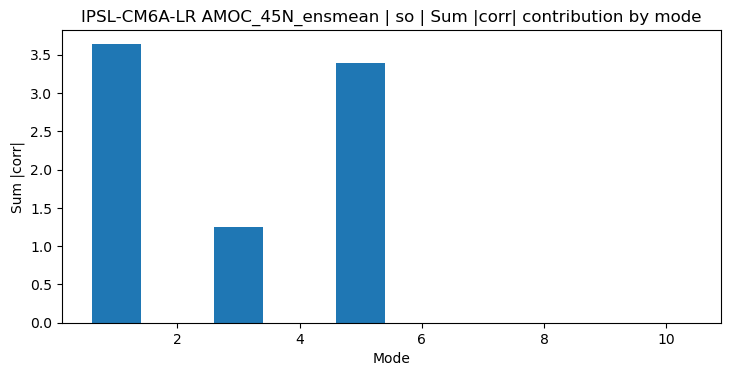

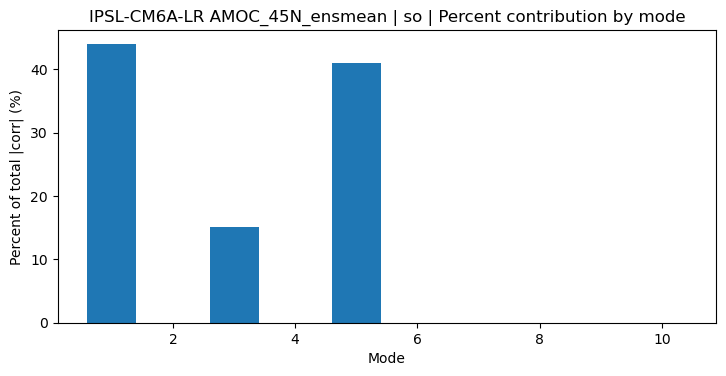

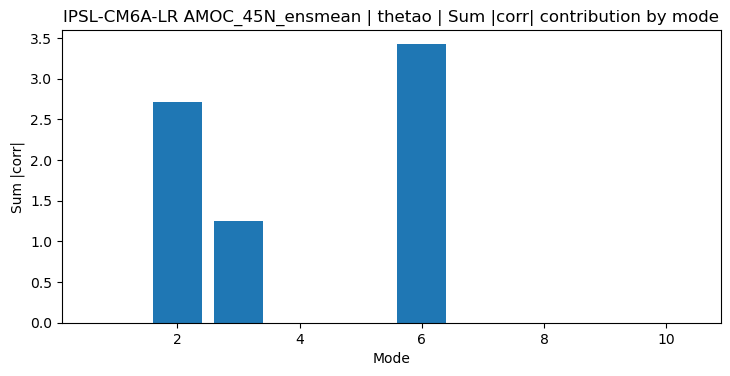

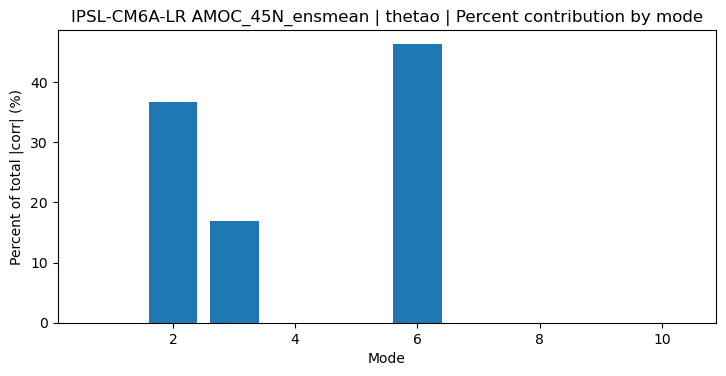

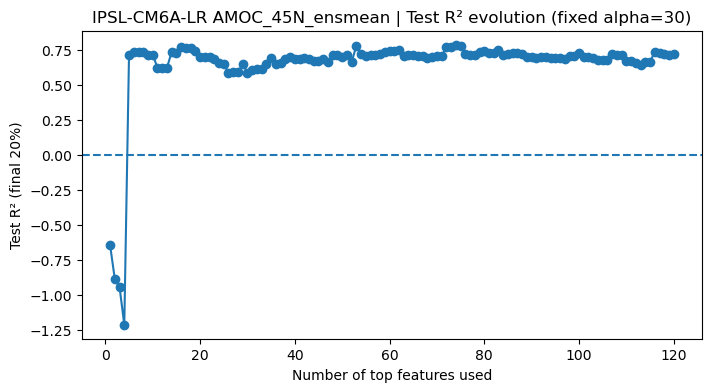


Top 5 single-step R² jumps (fixed alpha=30.0):
#1: ΔR²=+1.9249  R²_new=0.7149  add: so W10p0 EOF5 lag16  (step n=5, max_lag=16)
#2: ΔR²=+0.1184  R²_new=0.7790  add: so W10p0 EOF8 lag26  (step n=53, max_lag=30)
#3: ΔR²=+0.1148  R²_new=0.7337  add: so W10p0 EOF5 lag18  (step n=14, max_lag=29)
#4: ΔR²=+0.0760  R²_new=0.7363  add: so W10p0 EOF8 lag29  (step n=116, max_lag=30)
#5: ΔR²=+0.0646  R²_new=0.7682  add: so W30p0 EOF1 lag3  (step n=72, max_lag=30)
💾 Saved: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFTRAINONLY_R2_0.802_N20_W1_A30/03_R2/top_r2_jumps_fixed_alpha.csv


/tmp/ipykernel_751778/1102712461.py:635: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


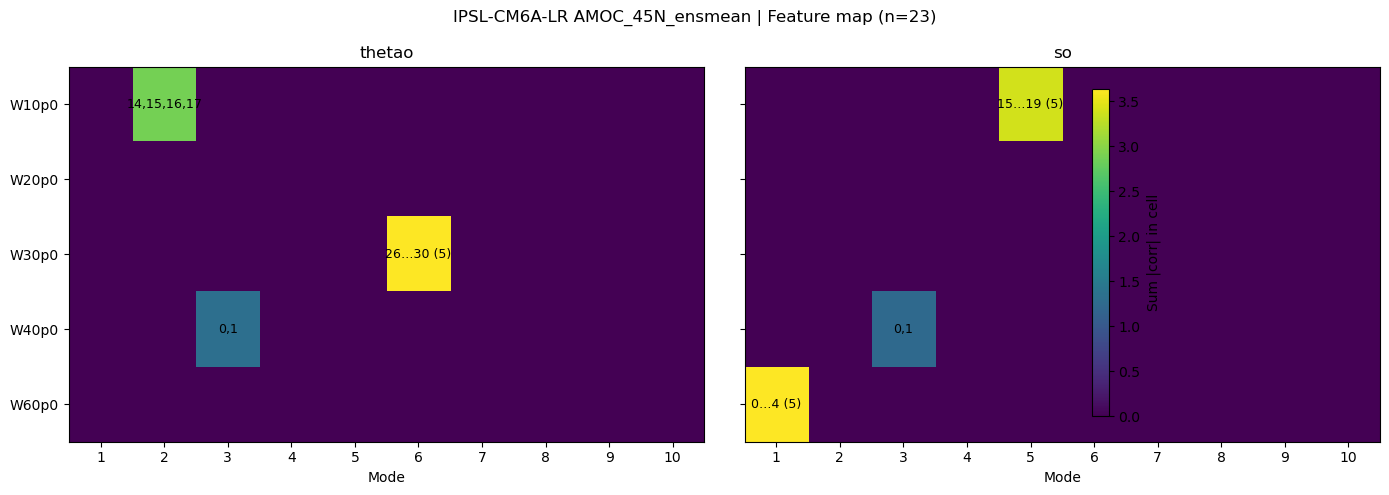


✅ All thesis figures generated in: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFTRAINONLY_R2_0.802_N20_W1_A30/


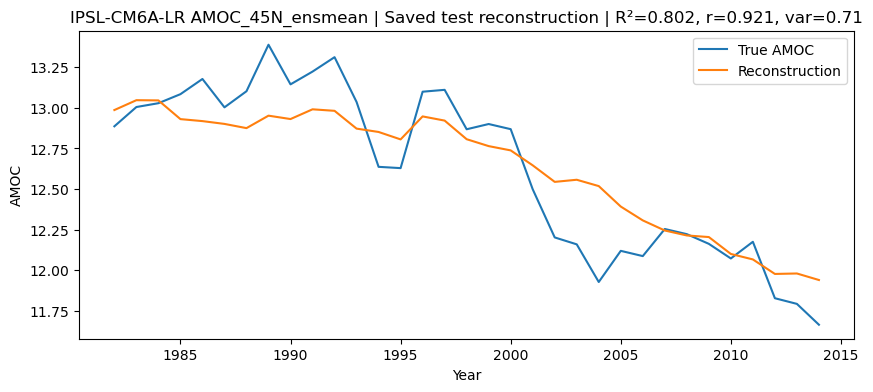

In [29]:
# ============================================================
# RUN ALL FIGURES
# ============================================================

# 1) EOF maps + PCs
plot_selected_eofs_and_pcs_oldstyle(
    feats=feats,
    outdir=os.path.join(OUTDIR, "01_EOF_PC"),
    max_panels=MAX_EOF_PANELS
)


# 2) Contribution histograms
df_sel = plot_feature_contribution_histograms(
    df_rank=df_rank,
    feats=feats,
    outdir=os.path.join(OUTDIR, "02_HIST"),
    title_prefix=f"{MODEL} {TARGET} | "
)

# 3) R² evolutions (two curves) + overlay

df_rank_r2 = df_rank.head(min(R2_EVOL_MAX_RANKED, len(df_rank))).copy()

df_fixed = r2_evolution_fixed_alpha(
    df_rank=df_rank_r2,
    pc_np=pc_np,
    years=years,
    y_amoc=y_amoc,
    n_trainval=n_trainval,
    alpha_fixed=ALPHA_FIXED,
    outdir=os.path.join(OUTDIR, "03_R2")
)

# ---- run it on your ranked list used for the R² curve ----
df_jumps = print_top_r2_jumps(
    df_rank=df_rank_r2,
    pc_np=pc_np,
    years=years,
    y_amoc=y_amoc,
    n_trainval=n_trainval,
    alpha_fixed=ALPHA_FIXED,
    topk=5
)

# Optional: save jumps table
df_jumps.to_csv(os.path.join(OUTDIR, "03_R2", "top_r2_jumps_fixed_alpha.csv"), index=False)
print("💾 Saved:", os.path.join(OUTDIR, "03_R2", "top_r2_jumps_fixed_alpha.csv"))



# 4) Feature map table
plot_feature_map_table(
    feats=feats,
    df_rank=df_rank,
    outdir=os.path.join(OUTDIR, "04_FEATUREMAP"),
    shading="corr"   # or "count"
)

print("\n✅ All thesis figures generated in:", OUTDIR)

# 5) Saved BEST_RUN reconstruction (exact y_true vs y_pred from pipeline test block)
plot_saved_test_reconstruction(
    pred_csv=BEST_TEST_PRED_CSV,
    metrics_csv=BEST_TEST_METRICS_CSV,
    outdir=os.path.join(OUTDIR, "05_TEST_RECON")
)
